In [1]:
import sys, os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ["PYTORCH_USE_CUDA_DSA"] = "1"
import numpy as np
import torch
import yaml
import pickle as pk
import numpy as np
import sys,os
import readgadget
import MAS_library as MASL
import pickle as pk
import readfof
import matplotlib
import readfof
import sys, os
import numpy as np
import pickle as pk 
# from nbodykit.lab import *
import h5py as h5
import numpy as np
import Pk_library as PKL
import MAS_library as MASL
import yaml
# from train_dtai_LRES_MDIFF import *
from model_enc_dec import *
from tqdm import tqdm
import gc
        
dev = torch.device("cuda")
# checkpoint = torch.load('/projects/bdne/spandey3/GOTHAM/model_checkpoints/camels_photo/model_encdec_ddp_PM_nvocab_64_nembed_64_nrandsubsel_32_iter_900.pt')
# checkpoint = torch.load('/projects/bdne/spandey3/GOTHAM/model_checkpoints/camels_photo/model_encdec_ddp_PM_nvocab_64_nembed_64_nrandsubsel_32.pt')

subsel_type = 'all'
# subsel_type = 'no_env'
# subsel_type = 'no_vel'
# subsel_type = 'no_highz_nsnap_3'
# Mstar_cut = 8.5
# Mstar_cut =12.7
Mstar_cut =13.3
add_space_token = False
# grid_sbox = 32
grid_sbox = 8
# add_space_token = True
# checkpoint = torch.load('/projects/bdne/spandey3/GOTHAM/model_checkpoints/camels_photo_velx/model_hres_encdec_ddp_PM_nvocab_64_nembed_128_nhead_8_nrandsubsel_64.pt')
# checkpoint = torch.load(f'/projects/bdne/spandey3/GOTHAM/model_checkpoints/camels_photo_velx/model_hres_encdec_ddp_grid_{grid_sbox}_nvocab_64_nembed_256_nhead_8_nrandsubsel_128_subselDMOfields_{subsel_type}_Mstarcut_{Mstar_cut}_spacetoken_{add_space_token}.pt')
# checkpoint = torch.load(f'/projects/bdne/spandey3/GOTHAM/model_checkpoints/camels_photo_velx/all_run2.pt')

# checkpoint = torch.load(f'/projects/bdne/spandey3/GOTHAM/model_checkpoints/camels_photo_velx/all_run2.pt')
# checkpoint = torch.load('/projects/bdne/spandey3/halo_gotham/GOTHAM/model_checkpoints/quijote_halos/FINAL5_afterfinetune_TEST_model_hres_encdec_ddp_grid_8_nvocab_64_nembed_256_nhead_8_nrandsubsel_2048_subselDMOfields_all_Mstarcut_12.7_spacetoken_False_maxiter_1500_lr_0.0005.pt')
# checkpoint = torch.load('/projects/bdne/spandey3/halo_gotham/GOTHAM/model_checkpoints/quijote_halos/FINAL5_afterfinetune_seq_TEST_model_hres_encdec_ddp_grid_8_nvocab_64_nembed_256_nhead_8_nrandsubsel_2048_subselDMOfields_all_Mstarcut_12.7_spacetoken_False_maxiter_1500_lr_0.0005.pt')
# checkpoint = torch.load('/projects/bdne/spandey3/halo_gotham/GOTHAM/model_checkpoints/quijote_halos/iter_save/LRES_MDIFF_cross_entropy_iter_72_seq_TEST_model_hres_encdec_ddp_grid_8_nvocab_64_nembed_192_nhead_8_nrandsubsel_64_subselDMOfields_all_Mstarcut_13.3_spacetoken_False_maxiter_250_lr_0.0005.pt')
# checkpoint = torch.load('/projects/bdne/spandey3/halo_gotham/GOTHAM/model_checkpoints/quijote_halos/iter_save/LRES_MDIFF_nrandsubsel_8192_cross_entropy_iter_56_seq_TEST_model_hres_encdec_ddp_grid_8_nvocab_64_nembed_192_nhead_8_nrandsubsel_8192_subselDMOfields_all_Mstarcut_13.3_spacetoken_False_maxiter_400_lr_0.005.pt')
# subsel_type = 'no_highz'
# checkpoint = torch.load('/projects/bdne/spandey3/halo_gotham/GOTHAM/model_checkpoints/quijote_halos/iter_save/LRES_MDIFF_cross_entropy_iter_248_seq_TEST_model_hres_encdec_ddp_grid_8_nvocab_64_nembed_192_nhead_8_nrandsubsel_128_subselDMOfields_all_Mstarcut_13.3_spacetoken_False_maxiter_250_lr_0.0001.pt')
# checkpoint = torch.load('/projects/bdne/spandey3/halo_gotham/GOTHAM/model_checkpoints/quijote_halos/iter_save/TEST2_LRES_MDIFF_cnn_vit_nrandsubsel_8192_cross_entropy_iter_196_seq_grid_8_nvocab_64_nembed_192_nhead_8_nrandsubsel_8192_subselDMOfields_all_Mstarcut_13.3_maxiter_400_lr_0.002.pt')
# checkpoint = torch.load('/projects/bdne/spandey3/halo_gotham/GOTHAM/model_checkpoints/quijote_halos/iter_save/TEST2_LRES_MDIFF_cnn_vit_nrandsubsel_8192_cross_entropy_iter_236_seq_grid_8_nvocab_64_nembed_128_nhead_8_nrandsubsel_8192_subselDMOfields_all_Mstarcut_13.3_maxiter_400_lr_0.002.pt')
checkpoint = torch.load('/projects/bdne/spandey3/halo_gotham/GOTHAM/model_checkpoints/quijote_halos/iter_save_wvitposembed/TEST3_LRES_MDIFF_cnn_vit_cbam_ps_1_nrandsubsel_8192_cross_entropy_iter_204_seq_grid_8_nvocab_64_nembed_192_nhead_8_nrandsubsel_8192_subselDMOfields_all_Mstarcut_13.3_maxiter_600_lr_0.0001.pt')

HaloConfig = checkpoint['config']
print(checkpoint['best_val_loss'])
learning_rate = 5e-4
model = HaloDecoderModel(HaloConfig).to(dev)
# if rank == 0: print(f"Init model and loaded to GPU", flush=True)            
# model.to(device).bfloat16()
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

# scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))

# checkpoint = torch.load('/mnt/home/spandey/ceph/CHARFORMER/model_checkpoints/model_encdec_ddp_PM_isim_012_nvocab_96_nembed_64_CORRMASK_NOFLASH_FINAL.pt')
# checkpoint = torch.load('/mnt/home/spandey/ceph/CHARFORMER/model_checkpoints/model_encdec_ddp_PM_isim_012_nvocab_64_nembed_64_Mmin_13p0.pt')
# checkpoint = torch.load('/mnt/home/spandey/ceph/CHARFORMER/model_checkpoints/model_encdec_ddp_PM_isim_012_nvocab_64_nembed_96_Mmin_13p0.pt')
# checkpoint = torch.load('/mnt/home/spandey/ceph/CHARFORMER/model_checkpoints/model_encdec_ddp_PM_isim_012_nvocab_64_nembed_64_Mmin_13p5.pt')
# checkpoint = torch.load('/mnt/home/spandey/ceph/GOTHAM/model_checkpoints/camels/model_encdec_ddp_PM_nvocab_64_nembed_64_nrandsubsel_8_iter_1000.pt')
model.load_state_dict(checkpoint['model'])
model.eval()
# print()
model = model.bfloat16()

params_all = np.loadtxt('/projects/bdne/spandey3/halo_gotham/GOTHAM/prep_data/latin_hypercube_params.txt')


# from tqdm import tqdm
TEMPERATURE = 1.0
nvocab = 64
grid = 32
DS_RES_POS_FAC = 4
# add_space_token = False
BoxSize = 1000.
xall = (np.linspace(0, BoxSize/grid, nvocab//DS_RES_POS_FAC + 1))
xarray = 0.5 * (xall[1:] + xall[:-1])
yarray = np.copy(xarray)
zarray = np.copy(xarray)

from tqdm import tqdm
saved_all = {}
# isim_fid_array = np.arange(936, 946)
# isim_fid_array = np.arange(975, 990)
# isim_fid_array = np.arange(990, 996)
isim_fid_array = np.arange(114, 119)
# isim_fid_array = np.arange(115, 116)
# isim_fid_array = np.arange(116, 117)
# isim_fid_array = np.arange(117, 118)
# isim_fid_array = np.arange(118, 119)
# isim_fid_array = np.arange(6, 7)
for isim_fid in (isim_fid_array):


    ldir = '/work/hdd/bdne/spandey3/quijote_data/halo_gotham_data/LH'
    savefname_dmo_fields = f'{ldir}/DMO_fields_ng32/DMO_fields_grid_{grid_sbox}_isim_{isim_fid}_nrandsubsel_32768_MAS_CIC_nsnaps_2.pkl'
    # df = pk.load(open(f'{sdir}/subhalo_density3Dgrid_32_isim_{isim_fid}_nrandsubsel_512_nvocab64_wSDSS_photometry_vel_hres.pkl','rb'))    
    # delta_box_all_squeezed_0 = df['delta_box_all_squeezed']
    df = pk.load(open(savefname_dmo_fields,'rb'))
    dmo_fields_all = torch.moveaxis(torch.tensor(df['dmo_fields_all']).to(torch.float16), -1, 1)

    # savefname_gals = f'{ldir}/gal_props/galaxy_props_snap_90_grid_{nvocab}_isim_{isim_fid}_nrandsubsel_512_nvocab{nvocab}_wSDSS_photometry_velx.pkl'
    # savefname_gals = f'{ldir}/halo_props_ng32/halo_props_snap_73_grid_{nvocab}_isim_{isim_fid}_nrandsubsel_32768_nvocab{nvocab}_spacetoken_{add_space_token}_xMvc_{Mstar_cut}.pkl'    
    savefname_gals = f'{ldir}/halo_props_ng32/halo_props_snap_73_grid_{nvocab//DS_RES_POS_FAC}_isim_{isim_fid}_nrandsubsel_32768_nvocab{nvocab}_spacetoken_{add_space_token}_xMv1Dc_{Mstar_cut}.pkl'    
    df = pk.load(open(savefname_gals,'rb'))
    dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_0 = df['story_full']

    param_0 = params_all[isim_fid][None, :]
    param_0 = np.repeat(param_0, len(dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_0), axis=0)

    # grid = 8
    # shift_x_all, shift_y_all, shift_z_all = np.zeros((grid, grid, grid)), np.zeros((grid, grid, grid)), np.zeros((grid, grid, grid))
    # for jx in range(grid):
    #     for jy in range(grid):
    #         for jz in range(grid):
    #             shift_x_all[jx, jy, jz] = jx
    #             shift_y_all[jx, jy, jz] = jy
    #             shift_z_all[jx, jy, jz] = jz

    # shift_x_all_squeezed, shift_y_all_squeezed, shift_z_all_squeezed = shift_x_all.flatten(), shift_y_all.flatten(), shift_z_all.flatten()
    # shift_all_squeezed = np.vstack([shift_x_all_squeezed, shift_y_all_squeezed, shift_z_all_squeezed]).T


    n1 = 32**3
    test_data_halos = dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_0[:n1]

    test_data_dm = dmo_fields_all[:n1]
    params_test = param_0[:n1]

    x = torch.tensor(test_data_halos[:, :-1])
    y = torch.tensor(test_data_halos[:, 1:])
    dm = torch.tensor(test_data_dm)
    mask_test_orig = x != 1
    mask_test = torch.logical_not(mask_test_orig)
    masked_logits = torch.zeros(mask_test.shape)
    mask_test_final = masked_logits.masked_fill(mask_test, float('-inf'))
    mask_test = mask_test_final[:,None,:]
    x, y = torch.tensor(x), torch.tensor(y)
    x_test = x.long()
    y_test = y.long()
    dm_test = dm.bfloat16()
    mask_test = torch.tensor(mask_test).bfloat16()
    params_test = torch.tensor(params_test).bfloat16()

    x_test_gpu = x_test.to(dev)
    y_test_gpu = y_test.to(dev)
    dm_test_gpu = dm_test.to(dev)
    mask_test_gpu = mask_test.to(dev)
    params_test_gpu = params_test.to(dev)

    # if subsel_type == 'no_highz':
    #     indices = torch.arange(6)
    # if subsel_type == 'no_highz_nsnap_2':
    #     indices = torch.arange(12)        
    # if subsel_type == 'no_highz_nsnap_3':
    #     indices = torch.arange(18)                
    # elif subsel_type == 'no_highz_no_vel':
    #     indices = torch.arange(3)
    # elif subsel_type == 'no_highz_no_env':
    #     indices = torch.from_numpy(np.array([0,3,4,5]))
    # elif subsel_type == 'no_vel':
    #     indices = torch.cat([torch.arange(i, i + 3) for i in range(0, 30, 6)])
    # elif subsel_type == 'no_env':        
    #     indices1 = torch.cat([torch.arange(i+3, i + 6) for i in range(0, 30, 6)])
    #     indices2 = torch.cat([torch.arange(i, i + 1) for i in range(0, 30, 6)])
    #     indices, _ = torch.sort(torch.cat([indices1, indices2]))
    # else:
    indices = torch.arange(dm_test_gpu.shape[1])


    dm_test_gpu = dm_test_gpu[:,indices,...]
    

    def get_batch(split, ji=0, batch_size=None):
        if split == 'test':
            x = x_test_gpu
            y = y_test_gpu
            mask = mask_test_gpu
            dm = dm_test_gpu       
            params = params_test_gpu 

        if batch_size is not None:
            x = x[batch_size*(ji):batch_size*(ji+1)].to(dev, non_blocking=True)
            y = y[batch_size*(ji):batch_size*(ji+1)].to(dev, non_blocking=True)
            mask = mask[batch_size*(ji):batch_size*(ji+1)].to(dev, non_blocking=True)
            dm = dm[batch_size*(ji):batch_size*(ji+1)].to(dev, non_blocking=True)
            params = params[batch_size*(ji):batch_size*(ji+1)].to(dev, non_blocking=True)

        return x, y, mask, dm, params

    # batch_size = 8**3
    batch_size = 32**3    
    X_val, Y_val, MASK_val, DM_val, PARAMS = get_batch('test', 0, batch_size)
    # DM_val = torch.moveaxis(DM_val, -1, 1)

    max_new_tokens = df['max_sentence_length']
    nvocab_tot = df['end_token'] + 1

    bins_digitize = np.linspace(-1e-3, 1, nvocab)
    # bins_digitize.insert(0, -1)
    # bins_digitize = np.insert(bins_digitize, 0, -1)


    start_token = df['start_token']
    pad_token = df['pad_token']
    end_token =  df['end_token']
    space_token = df['space_token']


    from tqdm import tqdm

    # fac = 1
    nvox_samp = batch_size
    nbatches = 1
    jb = 0
    nvox_per_batch = nvox_samp // nbatches

    # idx_all = []
    # idx_all = torch.ones((nvox_samp, max_new_tokens), dtype=torch.long, device=dev)
    idx_all = np.ones((nvox_samp, max_new_tokens))
    
    # for jb in (range(nbatches)):

    idx_inp = torch.zeros((nvox_per_batch, 1), dtype=torch.long, device=dev)

    DM_val_jb = DM_val[jb*nvox_per_batch:(jb+1)*nvox_per_batch,...]

    param_jb = PARAMS[jb*nvox_per_batch:(jb+1)*nvox_per_batch,...]

    new_samples_jb = np.ones((nvox_per_batch, max_new_tokens)) * pad_token

    ind_jb = np.arange(nvox_per_batch)

    new_samples_jb[:, 0] = idx_inp[:,0].cpu().detach().numpy() + start_token
    # idx = idx_inp
    prob_to_plot = []
    for jt in tqdm(range(1, max_new_tokens)):
        if len(ind_jb) > 0:
            # crop idx to the last block_size tokens
            idx_cond = torch.tensor(new_samples_jb[ind_jb, :jt], dtype=torch.long, device=dev)
            # get the predictions
            with torch.no_grad():
                logits, loss = model(idx_cond, DM_val_jb[ind_jb,...], params=param_jb[ind_jb,...])
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits/TEMPERATURE, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1).cpu().detach().numpy() # (B, 1)
            new_samples_jb[ind_jb, jt] = idx_next[:,0]
            ind_to_del = np.where((idx_next[:,0] == end_token) | (idx_next[:,0] == pad_token))[0]

            if len(ind_to_del) > 0:
                ind_jb = np.delete(ind_jb, ind_to_del)



            torch.cuda.empty_cache()
            gc.collect()


            # print(new_samples_jb[0,:])
            # idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        # print(new_samples_jb)
        idx_all[jb*nvox_per_batch:(jb+1)*nvox_per_batch, :] = new_samples_jb
        # idx_all.append(idx)
    # print(idx_all)
    dm_mean_allvox = np.mean(np.array(DM_val[:,1,...].to(torch.float16).detach().cpu()), axis=(1,2,3))

    prop_min = df['prop_min']
    prop_max = df['prop_max']
    
    dim_pos = 3
    dim_prop = len(prop_min)   
    dim_tot = dim_pos + dim_prop
    

    # BoxSize = 1000.
    # grid = 8
    xmin = BoxSize/grid/2

    MAS     = 'NGP'  #mass-assigment scheme
    # grid_Pk = 16
    # threads = 10
    
    def get_prop_pos(X_val):
        pos_infer_all = []
        prop_infer_all = []
        
        for jx in range(grid):
            for jy in range(grid):
                for jz in range(grid):
                    sentence_here = X_val[jx, jy, jz]
                    if add_space_token:
                        ntokens_per_halo = dim_tot + 1
                    else:
                        ntokens_per_halo = dim_tot
                    ind_start_token = np.where(sentence_here == start_token)[0][0]
                    if end_token in sentence_here:
                        ind_end_token = np.where(sentence_here == end_token)[0]
                        try:
                            Nhalos_here = ((ind_end_token - ind_start_token - 1) / ntokens_per_halo)[0]
                        except:
                            print(ind_end_token, ind_start_token, ntokens_per_halo)
                        if (int(Nhalos_here) - Nhalos_here) != 0:
                            Nhalos_here = ((ind_end_token - ind_start_token ) / ntokens_per_halo)[0]
                            # print(Nhalos_here, Nhalos_here2, 'Nhalos_here is not an integer')
                            # pass
                        if (int(Nhalos_here) - Nhalos_here) != 0:
                            print(Nhalos_here, 'Nhalos_here is not an integer')
                        else:
                            if Nhalos_here > 0:
                                for jh in range(int(Nhalos_here)):
                                    try:
                                        prop_all = np.zeros(dim_prop)        
                                        for jp in range(dim_prop):
                                            # noise_val = np.random.uniform(-delta_bin/2, delta_bin/2)
                                            noise_val = 0.0
                                            bin_val_jp = sentence_here[ind_start_token + jh*ntokens_per_halo + 1 + jp]
                                            try:
                                                prop_all[jp] = prop_min[jp] + (prop_max[jp] - prop_min[jp]) * (bins_digitize[bin_val_jp] + noise_val)
                                            except:
                                                pass

                                        coord_x = (xarray[sentence_here[ind_start_token + jh*ntokens_per_halo + dim_prop + 1]] + (BoxSize/grid)*jx) % BoxSize
                                        coord_y = (yarray[sentence_here[ind_start_token + jh*ntokens_per_halo + dim_prop + 2]] + (BoxSize/grid)*jy) % BoxSize
                                        coord_z = (zarray[sentence_here[ind_start_token + jh*ntokens_per_halo + dim_prop + 3]] + (BoxSize/grid)*jz) % BoxSize
                                        pos_infer_all.append([coord_x, coord_y, coord_z])
                                                # print(sentence_here)
                                        prop_infer_all.append(prop_all)
     
                                    except Exception as e:
                                        print(e)
                                        pass
                                        # print(sentence_here[ind_start_token], ntokens_per_halo)
                    else:           
                        print('End token not found')
                        pass
        
        pos_infer_all = np.array(pos_infer_all)
        prop_infer_all = np.array(prop_infer_all)
        return pos_infer_all, prop_infer_all

    # print(idx_all, X_val)
    idx_all_rs = np.reshape(np.array(idx_all), (grid, grid, grid, idx_all.shape[-1])).astype(int)
    # X_val_rs = np.reshape(X_val.cpu().numpy(), (grid, grid, grid, X_val.shape[-1])).astype(int)
    X_val_rs = np.reshape(dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_0, (grid, grid, grid, dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_0.shape[-1])).astype(int)
    print('getting inferred positions and properties')
    pos_infer_all, prop_infer_all = get_prop_pos(idx_all_rs)

    print('getting truth positions and properties')
    pos_truth_all, prop_truth_all = get_prop_pos(X_val_rs)

    # snapnum = 90
    # ldir = '/work/hdd/bdne/spandey3/camels_tng/hydro'
    # group_catalog = f'{ldir}/LH/LH_{isim_fid}/groups_0{snapnum}.hdf5'
    # photo_catalog = f'{ldir}/Photometry/IllustrisTNG/L25n256/LH/IllustrisTNG_LH_{isim_fid}_photometry.hdf5'
    # # open the catalogue
    # with h5.File(photo_catalog, "r") as hf:
    #     subhalo_index = np.array(hf[f"snap_0{snapnum}/SubhaloIndex"][:], dtype=int)
    #     g_band = np.log10(hf[f"snap_0{snapnum}/BC03/photometry/luminosity/attenuated/SLOAN/SDSS.g"][:])
    #     r_band = np.log10(hf[f"snap_0{snapnum}/BC03/photometry/luminosity/attenuated/SLOAN/SDSS.r"][:])
    #     i_band = np.log10(hf[f"snap_0{snapnum}/BC03/photometry/luminosity/attenuated/SLOAN/SDSS.i"][:])
    
    # # Read the stellar masses of the subhalos/galaxies
    # with h5.File(group_catalog, "r") as hf:
    #     M_star = np.log10(hf['Subhalo/SubhaloMassType'][:,4]*1e10 + 0.01) # Stellar masses in Msun/h
    #     pos = hf['Subhalo/SubhaloPos'][:]/1000.
    #     vel = hf['Subhalo/SubhaloVel'][:]
    
    # M_star = M_star[subhalo_index]
    # pos_truth_orig = pos[subhalo_index]
    # vel_truth_orig = vel[subhalo_index][:,0]
    # indsel = np.where(M_star > Mstar_cut)[0]
    # print(pos_truth_orig[indsel,:].shape, pos_truth_all.shape, pos_infer_all.shape)
    
    saved_all[isim_fid] = {'pos_truth':pos_truth_all, 'prop_truth':prop_truth_all, 'pos_infer':pos_infer_all, 'prop_infer':prop_infer_all}

    # import pickle as pk
    # with open(f'/projects/bdne/spandey3/halo_gotham/GOTHAM/infer_data/FINAL5_TEST_infer_halos_ng32_grid_{grid_sbox}_isim_fid_{isim_fid_array[0]}_{isim_fid_array[-1]}_nrandsubsel_32768_Mstarcut_{Mstar_cut}_spacetoken_{add_space_token}.pkl', 'wb') as f:
    #     pk.dump(saved_all, f)




/tmp/ipykernel_1560154/1425608237.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('/projects/bdne/spandey3/halo_gotham/GOTHAM/model_checkpoints/

tensor(2.6024)
Using flash:  True
Using flash:  True
Using flash:  True
Using flash:  True
number of parameters: 3.60M


/tmp/ipykernel_1560154/1425608237.py:147: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dm = torch.tensor(test_data_dm)
/tmp/ipykernel_1560154/1425608237.py:153: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x, y = torch.tensor(x), torch.tensor(y)
/tmp/ipykernel_1560154/1425608237.py:157: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask_test = torch.tensor(mask_test).bfloat16()
  0%|          | 0/181 [00:00<?, ?it/s]/u/spandey3/gotham/lib/python3.10/contextlib.py:103: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In t

getting inferred positions and properties
index 43 is out of bounds for axis 0 with size 16
index 17 is out of bounds for axis 0 with size 16
index 29 is out of bounds for axis 0 with size 16
index 26 is out of bounds for axis 0 with size 16
index 17 is out of bounds for axis 0 with size 16
index 68 is out of bounds for axis 0 with size 16
index 16 is out of bounds for axis 0 with size 16
index 56 is out of bounds for axis 0 with size 16
index 68 is out of bounds for axis 0 with size 16
index 40 is out of bounds for axis 0 with size 16
0.3333333333333333 Nhalos_here is not an integer
index 65 is out of bounds for axis 0 with size 16
index 22 is out of bounds for axis 0 with size 16
index 17 is out of bounds for axis 0 with size 16
index 19 is out of bounds for axis 0 with size 16
index 21 is out of bounds for axis 0 with size 16
index 16 is out of bounds for axis 0 with size 16
End token not found
index 47 is out of bounds for axis 0 with size 16
3.3333333333333335 Nhalos_here is not a

100%|██████████| 181/181 [01:25<00:00,  2.11it/s]


...

getting inferred positions and properties
index 20 is out of bounds for axis 0 with size 16
index 18 is out of bounds for axis 0 with size 16
index 24 is out of bounds for axis 0 with size 16
index 25 is out of bounds for axis 0 with size 16
index 29 is out of bounds for axis 0 with size 16
index 65 is out of bounds for axis 0 with size 16
index 20 is out of bounds for axis 0 with size 16
index 21 is out of bounds for axis 0 with size 16
index 40 is out of bounds for axis 0 with size 16
index 28 is out of bounds for axis 0 with size 16
index 18 is out of bounds for axis 0 with size 16
index 55 is out of bounds for axis 0 with size 16
index 28 is out of bounds for axis 0 with size 16
index 21 is out of bounds for axis 0 with size 16
index 34 is out of bounds for axis 0 with size 16
index 38 is out of bounds for axis 0 with size 16
index 22 is out of bounds for axis 0 with size 16
index 43 is out of bounds for axis 0 with size 16
index 52 is out of bounds for axis 0 with size 16
4.833333

100%|██████████| 181/181 [01:25<00:00,  2.11it/s]


getting inferred positions and properties
index 68 is out of bounds for axis 0 with size 16
index 63 is out of bounds for axis 0 with size 16
index 22 is out of bounds for axis 0 with size 16
index 27 is out of bounds for axis 0 with size 16
index 16 is out of bounds for axis 0 with size 16
index 23 is out of bounds for axis 0 with size 16
index 51 is out of bounds for axis 0 with size 16
index 47 is out of bounds for axis 0 with size 16
index 30 is out of bounds for axis 0 with size 16
4.333333333333333 Nhalos_here is not an integer
index 55 is out of bounds for axis 0 with size 16
index 55 is out of bounds for axis 0 with size 16
index 21 is out of bounds for axis 0 with size 16
index 22 is out of bounds for axis 0 with size 16
index 16 is out of bounds for axis 0 with size 16
index 41 is out of bounds for axis 0 with size 16
index 18 is out of bounds for axis 0 with size 16
index 17 is out of bounds for axis 0 with size 16
index 18 is out of bounds for axis 0 with size 16
index 65 i

100%|██████████| 181/181 [00:20<00:00,  8.86it/s] 


getting inferred positions and properties
index 36 is out of bounds for axis 0 with size 16
0.5 Nhalos_here is not an integer
index 19 is out of bounds for axis 0 with size 16
0.3333333333333333 Nhalos_here is not an integer
index 16 is out of bounds for axis 0 with size 16
index 17 is out of bounds for axis 0 with size 16
index 68 is out of bounds for axis 0 with size 16
index 20 is out of bounds for axis 0 with size 16
index 42 is out of bounds for axis 0 with size 16
index 54 is out of bounds for axis 0 with size 16
0.3333333333333333 Nhalos_here is not an integer
index 16 is out of bounds for axis 0 with size 16
index 65 is out of bounds for axis 0 with size 16
index 68 is out of bounds for axis 0 with size 16
index 22 is out of bounds for axis 0 with size 16
index 35 is out of bounds for axis 0 with size 16
0.3333333333333333 Nhalos_here is not an integer
index 30 is out of bounds for axis 0 with size 16
index 66 is out of bounds for axis 0 with size 16
index 68 is out of bounds f

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline




/tmp/ipykernel_1560154/3617105758.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Make room for the colorbar


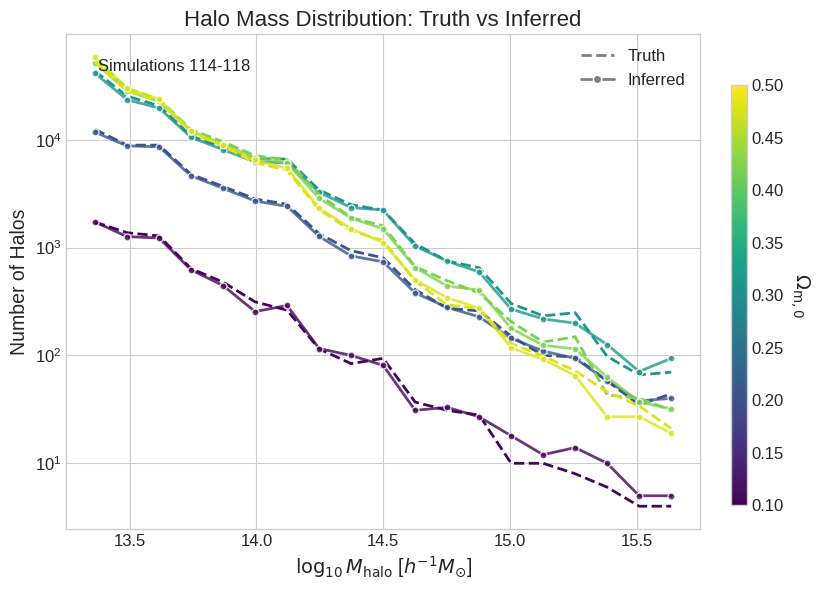

In [3]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colorbar import ColorbarBase

# Set the style
plt.style.use('seaborn-v0_8-whitegrid')

# Create figure and axes with better size and resolution
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

# Load data
params_all = np.loadtxt('/projects/bdne/spandey3/halo_gotham/GOTHAM/prep_data/latin_hypercube_params.txt')
isim_fid_array = np.arange(114, 119)

# Create a colormap for Om0 values
cmap = plt.cm.viridis
norm = mcolors.Normalize(vmin=0.1, vmax=0.5)  # Range of Om0 from 0.1 to 0.5

# Set up the plot
ax.set_xlabel(r'$\log_{10} M_{\mathrm{halo}}$ [$h^{-1} M_{\odot}$]', fontsize=14)
ax.set_ylabel('Number of Halos', fontsize=14)
ax.set_title('Halo Mass Distribution: Truth vs Inferred', fontsize=16)
ax.set_yscale('log')
ax.tick_params(axis='both', which='major', labelsize=12)

# Create plot lines with beautiful colors
for ji, isim in enumerate(isim_fid_array):
    Om0 = params_all[isim][0]
    sig8 = params_all[isim][-1]
    
    # Get color from Om0 value
    color = cmap(norm(Om0))
    
    # Process data
    prop_truth_all = saved_all[isim]['prop_truth']
    prop_infer_all = saved_all[isim]['prop_infer']
    
    Mhalo_truth = prop_truth_all[:,0]
    Mhalo_infer = prop_infer_all[:,0]
    
    Mhalo_bins_edges = np.linspace(13.3, 15.7, 20)
    Mhalo_bins = 0.5 * (Mhalo_bins_edges[1:] + Mhalo_bins_edges[:-1])
    
    hist_Mhalo_truth = np.histogram(Mhalo_truth, bins=Mhalo_bins_edges)[0]
    hist_Mhalo_infer = np.histogram(Mhalo_infer, bins=Mhalo_bins_edges)[0]
    
    # Plot with better styling
    ax.plot(Mhalo_bins, hist_Mhalo_truth, ls='--', marker='', color=color, 
            linewidth=2, label=f'Truth (Om0={Om0:.2f})')
    ax.plot(Mhalo_bins, hist_Mhalo_infer, ls='-', marker='o', color=color, 
            markersize=5, alpha=0.8, linewidth=2, markeredgecolor='white',
            label=f'Inferred (Om0={Om0:.2f})')

# Add a colorbar
cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cb = ColorbarBase(cax, cmap=cmap, norm=norm)
cb.set_label(r'$\Omega_{\mathrm{m,0}}$', fontsize=14, rotation=270, labelpad=20)
cb.ax.tick_params(labelsize=12)

# Create a custom legend that doesn't repeat for each simulation
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='gray', linestyle='--', lw=2, label='Truth'),
    Line2D([0], [0], color='gray', linestyle='-', marker='o', markeredgecolor='white', lw=2, label='Inferred')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=12)

# Add text about the simulation range
ax.text(0.05, 0.95, f'Simulations {isim_fid_array[0]}-{isim_fid_array[-1]}', 
        transform=ax.transAxes, fontsize=12, va='top')

# Adjust layout
plt.tight_layout(rect=[0, 0, 0.9, 1])  # Make room for the colorbar

# Save figure with high quality
# plt.savefig('halo_mass_distribution.png', dpi=300, bbox_inches='tight')

plt.show()



/tmp/ipykernel_1560154/804073515.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Make room for the colorbar


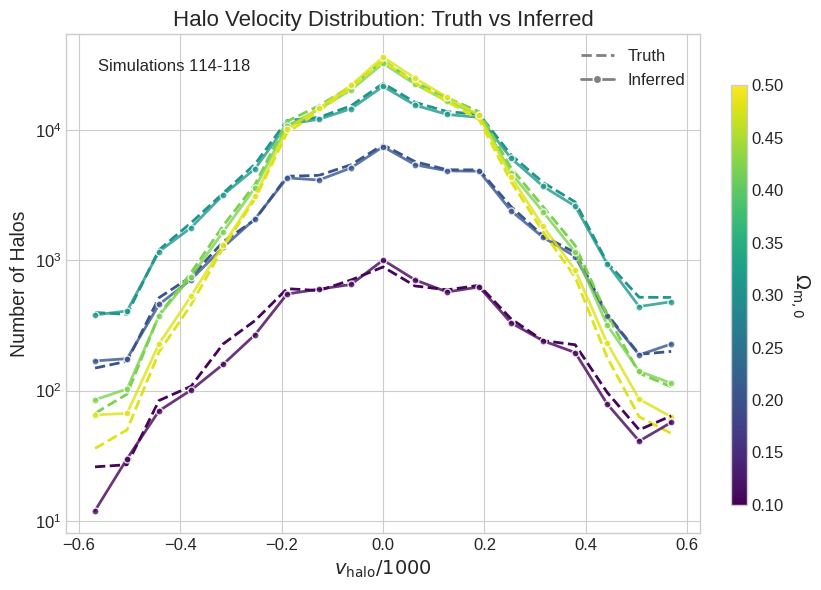

In [4]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colorbar import ColorbarBase

# Set the style
plt.style.use('seaborn-v0_8-whitegrid')

# Create figure and axes with better size and resolution
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

# Load data
params_all = np.loadtxt('/projects/bdne/spandey3/halo_gotham/GOTHAM/prep_data/latin_hypercube_params.txt')
isim_fid_array = np.arange(114, 119)

# Create a colormap for Om0 values
cmap = plt.cm.viridis
norm = mcolors.Normalize(vmin=0.1, vmax=0.5)  # Range of Om0 from 0.1 to 0.5

# Set up the plot
ax.set_xlabel(r'$v_{\rm halo}/1000$', fontsize=14)
ax.set_ylabel('Number of Halos', fontsize=14)
ax.set_title('Halo Velocity Distribution: Truth vs Inferred', fontsize=16)
ax.set_yscale('log')
ax.tick_params(axis='both', which='major', labelsize=12)

# Create plot lines with beautiful colors
for ji, isim in enumerate(isim_fid_array):
    Om0 = params_all[isim][0]
    sig8 = params_all[isim][-1]
    
    # Get color from Om0 value
    color = cmap(norm(Om0))
    
    # Process data
    prop_truth_all = saved_all[isim]['prop_truth']
    prop_infer_all = saved_all[isim]['prop_infer']
    
    Mhalo_truth = prop_truth_all[:,1]
    Mhalo_infer = prop_infer_all[:,1]
    
    Mhalo_bins_edges = np.linspace(-0.6, 0.6, 20)
    Mhalo_bins = 0.5 * (Mhalo_bins_edges[1:] + Mhalo_bins_edges[:-1])
    
    hist_Mhalo_truth = np.histogram(Mhalo_truth, bins=Mhalo_bins_edges)[0]
    hist_Mhalo_infer = np.histogram(Mhalo_infer, bins=Mhalo_bins_edges)[0]
    
    # Plot with better styling
    ax.plot(Mhalo_bins, hist_Mhalo_truth, ls='--', marker='', color=color, 
            linewidth=2, label=f'Truth (Om0={Om0:.2f})')
    ax.plot(Mhalo_bins, hist_Mhalo_infer, ls='-', marker='o', color=color, 
            markersize=5, alpha=0.8, linewidth=2, markeredgecolor='white',
            label=f'Inferred (Om0={Om0:.2f})')

# Add a colorbar
cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cb = ColorbarBase(cax, cmap=cmap, norm=norm)
cb.set_label(r'$\Omega_{\mathrm{m,0}}$', fontsize=14, rotation=270, labelpad=20)
cb.ax.tick_params(labelsize=12)

# Create a custom legend that doesn't repeat for each simulation
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='gray', linestyle='--', lw=2, label='Truth'),
    Line2D([0], [0], color='gray', linestyle='-', marker='o', markeredgecolor='white', lw=2, label='Inferred')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=12)

# Add text about the simulation range
ax.text(0.05, 0.95, f'Simulations {isim_fid_array[0]}-{isim_fid_array[-1]}', 
        transform=ax.transAxes, fontsize=12, va='top')

# Adjust layout
plt.tight_layout(rect=[0, 0, 0.9, 1])  # Make room for the colorbar

# Save figure with high quality
# plt.savefig('halo_mass_distribution.png', dpi=300, bbox_inches='tight')

plt.show()





/tmp/ipykernel_1560154/2601047516.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Make room for the colorbar


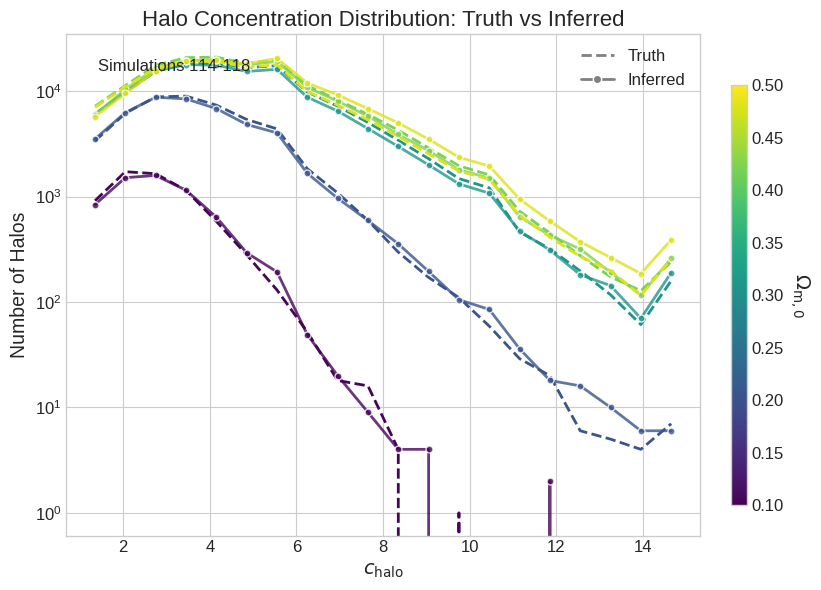

In [5]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colorbar import ColorbarBase

# Set the style
plt.style.use('seaborn-v0_8-whitegrid')

# Create figure and axes with better size and resolution
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

# Load data
params_all = np.loadtxt('/projects/bdne/spandey3/halo_gotham/GOTHAM/prep_data/latin_hypercube_params.txt')
isim_fid_array = np.arange(114, 119)

# Create a colormap for Om0 values
cmap = plt.cm.viridis
norm = mcolors.Normalize(vmin=0.1, vmax=0.5)  # Range of Om0 from 0.1 to 0.5

# Set up the plot
ax.set_xlabel(r'$c_{\rm halo}$', fontsize=14)
ax.set_ylabel('Number of Halos', fontsize=14)
ax.set_title('Halo Concentration Distribution: Truth vs Inferred', fontsize=16)
ax.set_yscale('log')
ax.tick_params(axis='both', which='major', labelsize=12)

# Create plot lines with beautiful colors
for ji, isim in enumerate(isim_fid_array):
    Om0 = params_all[isim][0]
    sig8 = params_all[isim][-1]
    
    # Get color from Om0 value
    color = cmap(norm(Om0))
    
    # Process data
    prop_truth_all = saved_all[isim]['prop_truth']
    prop_infer_all = saved_all[isim]['prop_infer']
    
    Mhalo_truth = prop_truth_all[:,2]
    Mhalo_infer = prop_infer_all[:,2]
    
    Mhalo_bins_edges = np.linspace(1, 15, 21)
    Mhalo_bins = 0.5 * (Mhalo_bins_edges[1:] + Mhalo_bins_edges[:-1])
    
    hist_Mhalo_truth = np.histogram(Mhalo_truth, bins=Mhalo_bins_edges)[0]
    hist_Mhalo_infer = np.histogram(Mhalo_infer, bins=Mhalo_bins_edges)[0]
    
    # Plot with better styling
    ax.plot(Mhalo_bins, hist_Mhalo_truth, ls='--', marker='', color=color, 
            linewidth=2, label=f'Truth (Om0={Om0:.2f})')
    ax.plot(Mhalo_bins, hist_Mhalo_infer, ls='-', marker='o', color=color, 
            markersize=5, alpha=0.8, linewidth=2, markeredgecolor='white',
            label=f'Inferred (Om0={Om0:.2f})')

# Add a colorbar
cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cb = ColorbarBase(cax, cmap=cmap, norm=norm)
cb.set_label(r'$\Omega_{\mathrm{m,0}}$', fontsize=14, rotation=270, labelpad=20)
cb.ax.tick_params(labelsize=12)

# Create a custom legend that doesn't repeat for each simulation
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='gray', linestyle='--', lw=2, label='Truth'),
    Line2D([0], [0], color='gray', linestyle='-', marker='o', markeredgecolor='white', lw=2, label='Inferred')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=12)

# Add text about the simulation range
ax.text(0.05, 0.95, f'Simulations {isim_fid_array[0]}-{isim_fid_array[-1]}', 
        transform=ax.transAxes, fontsize=12, va='top')

# Adjust layout
plt.tight_layout(rect=[0, 0, 0.9, 1])  # Make room for the colorbar

# Save figure with high quality
# plt.savefig('halo_mass_distribution.png', dpi=300, bbox_inches='tight')

plt.show()





In [6]:
import Pk_library as PKL
import MAS_library as MASL

grid_Pk = 512
MAS = 'CIC'
BoxSize = 1000.

Pk_all = {}

for isim_fid in isim_fid_array:

    pos_infer_all = saved_all[isim_fid]['pos_infer']
    mesh_pred = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
    MASL.MA(pos_infer_all.astype(np.float32), mesh_pred, BoxSize, MAS)
    mesh_pred /= np.mean(mesh_pred, dtype=np.float64);  mesh_pred -= 1.0
    Pk_pred = PKL.Pk(mesh_pred, BoxSize, axis=0, MAS=None,  verbose=False)

    pos_truth_all = saved_all[isim_fid]['pos_truth']
    mesh_truth = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
    MASL.MA(pos_truth_all.astype(np.float32), mesh_truth, BoxSize, MAS)
    mesh_truth /= np.mean(mesh_truth, dtype=np.float64);  mesh_truth -= 1.0
    Pk_truth = PKL.Pk(mesh_truth, BoxSize, axis=0, MAS=None, verbose=False)

    Pk_all_ratio = (Pk_pred.Pk[:,0]/Pk_truth.Pk[:,0])

    # Pk_all_truth.append(Pk_truth.Pk[:,0])
    Pk_all[isim_fid] = {'Pk_pred':Pk_pred.Pk[:,0], 'Pk_truth':Pk_truth.Pk[:,0], 'Pk_ratio':Pk_all_ratio, 'k':Pk_truth.k3D}





/tmp/ipykernel_1560154/4206517807.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Make room for the colorbar


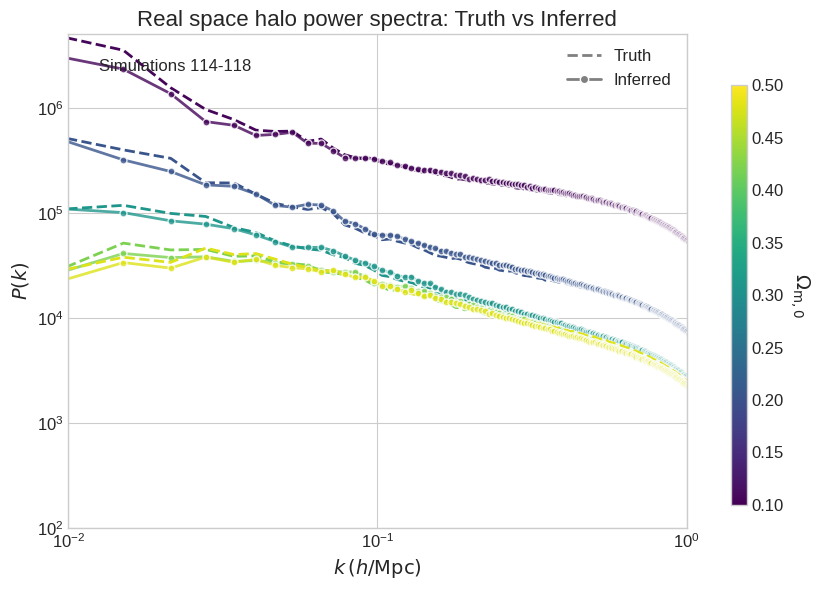

In [7]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colorbar import ColorbarBase

# Set the style
# plt.style.use('seaborn-v0_8-whitegrid')

# Create figure and axes with better size and resolution
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

# Load data
params_all = np.loadtxt('/projects/bdne/spandey3/halo_gotham/GOTHAM/prep_data/latin_hypercube_params.txt')
isim_fid_array = np.arange(114, 119)

# Create a colormap for Om0 values
cmap = plt.cm.viridis
norm = mcolors.Normalize(vmin=0.1, vmax=0.5)  # Range of Om0 from 0.1 to 0.5

# Set up the plot
ax.set_xlabel(r'$k \, (h/{\rm Mpc})$', fontsize=14)
ax.set_ylabel(r'$P(k)$', fontsize=14)
ax.set_title('Real space halo power spectra: Truth vs Inferred', fontsize=16)
ax.set_yscale('log')
ax.set_xscale('log')
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xlim(0.01, 1)
ax.set_ylim(1e2, 5e6)

# Create plot lines with beautiful colors
for ji, isim in enumerate(isim_fid_array):
    Om0 = params_all[isim][0]
    sig8 = params_all[isim][-1]
    
    # Get color from Om0 value
    color = cmap(norm(Om0))
    
    # Process data
    
    # Plot with better styling
    ax.plot(Pk_all[isim]['k'], Pk_all[isim]['Pk_truth'], ls='--', marker='', color=color, 
            linewidth=2, label=f'Truth (Om0={Om0:.2f})')
    ax.plot(Pk_all[isim]['k'], Pk_all[isim]['Pk_pred'], ls='-', marker='o', color=color, 
            markersize=5, alpha=0.8, linewidth=2, markeredgecolor='white',
            label=f'Inferred (Om0={Om0:.2f})')

# Add a colorbar
cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cb = ColorbarBase(cax, cmap=cmap, norm=norm)
cb.set_label(r'$\Omega_{\mathrm{m,0}}$', fontsize=14, rotation=270, labelpad=20)
cb.ax.tick_params(labelsize=12)

# Create a custom legend that doesn't repeat for each simulation
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='gray', linestyle='--', lw=2, label='Truth'),
    Line2D([0], [0], color='gray', linestyle='-', marker='o', markeredgecolor='white', lw=2, label='Inferred')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=12)

# Add text about the simulation range
ax.text(0.05, 0.95, f'Simulations {isim_fid_array[0]}-{isim_fid_array[-1]}', 
        transform=ax.transAxes, fontsize=12, va='top')

# Adjust layout
plt.tight_layout(rect=[0, 0, 0.9, 1])  # Make room for the colorbar
# Save figure with high quality
# plt.savefig('halo_mass_distribution.png', dpi=300, bbox_inches='tight')

plt.show()









/tmp/ipykernel_1560154/796539961.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Make room for the colorbar


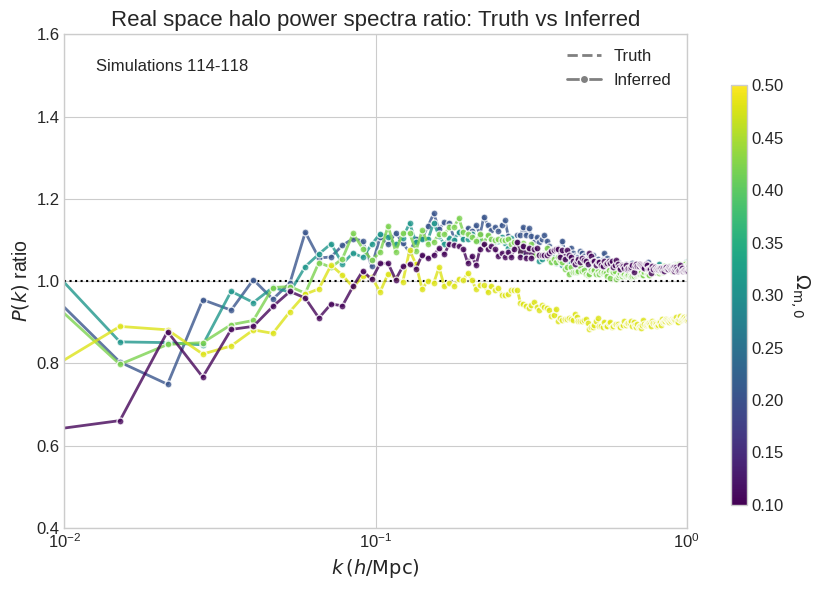

In [8]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colorbar import ColorbarBase

# Set the style
# plt.style.use('seaborn-v0_8-whitegrid')

# Create figure and axes with better size and resolution
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

# Load data
params_all = np.loadtxt('/projects/bdne/spandey3/halo_gotham/GOTHAM/prep_data/latin_hypercube_params.txt')
isim_fid_array = np.arange(114, 119)

# Create a colormap for Om0 values
cmap = plt.cm.viridis
norm = mcolors.Normalize(vmin=0.1, vmax=0.5)  # Range of Om0 from 0.1 to 0.5

# Set up the plot
ax.set_xlabel(r'$k \, (h/{\rm Mpc})$', fontsize=14)
ax.set_ylabel(r'$P(k)$ ratio', fontsize=14)
ax.set_title('Real space halo power spectra ratio: Truth vs Inferred', fontsize=16)
# ax.set_yscale('log')
ax.set_xscale('log')
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xlim(0.01, 1)
ax.set_ylim(0.4, 1.6)
ax.axhline(1.0, ls=':', color='k')
# Create plot lines with beautiful colors
for ji, isim in enumerate(isim_fid_array):
    Om0 = params_all[isim][0]
    sig8 = params_all[isim][-1]
    
    # Get color from Om0 value
    color = cmap(norm(Om0))
    
    # Process data
    
    # Plot with better styling
    # ax.plot(Pk_all[isim]['k'], Pk_all[isim]['Pk_truth'], ls='--', marker='', color=color, 
    #         linewidth=2, label=f'Truth (Om0={Om0:.2f})')
    ax.plot(Pk_all[isim]['k'], Pk_all[isim]['Pk_ratio'], ls='-', marker='o', color=color, 
            markersize=5, alpha=0.8, linewidth=2, markeredgecolor='white',
            label=f'Inferred (Om0={Om0:.2f})')

# Add a colorbar
cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cb = ColorbarBase(cax, cmap=cmap, norm=norm)
cb.set_label(r'$\Omega_{\mathrm{m,0}}$', fontsize=14, rotation=270, labelpad=20)
cb.ax.tick_params(labelsize=12)

# Create a custom legend that doesn't repeat for each simulation
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='gray', linestyle='--', lw=2, label='Truth'),
    Line2D([0], [0], color='gray', linestyle='-', marker='o', markeredgecolor='white', lw=2, label='Inferred')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=12)

# Add text about the simulation range
ax.text(0.05, 0.95, f'Simulations {isim_fid_array[0]}-{isim_fid_array[-1]}', 
        transform=ax.transAxes, fontsize=12, va='top')

# Adjust layout
plt.tight_layout(rect=[0, 0, 0.9, 1])  # Make room for the colorbar
# Save figure with high quality
# plt.savefig('halo_mass_distribution.png', dpi=300, bbox_inches='tight')

plt.show()











In [9]:
grid_Pk = 512
MAS = 'CIC'
BoxSize = 1000.

Pk_all_rsd = {}

for isim_fid in isim_fid_array:
    Om = params_all[isim_fid, 0]
    z=0.5
    Hz = 100.0 * np.sqrt(Om * (1. + z)**3 + (1 - Om))
    rsd_factor = (1. + z) / Hz

    pos_truth = np.copy(saved_all[isim_fid]['pos_truth'])
    vel_truth = np.copy(saved_all[isim_fid]['prop_truth'][:,1] * 2000.)
    mesh_truth = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
    pos_truth[:,0] = (pos_truth[:,0] + (vel_truth * rsd_factor))%(BoxSize)
    MASL.MA(pos_truth.astype(np.float32), mesh_truth, BoxSize, MAS)
    mesh_truth /= np.mean(mesh_truth, dtype=np.float64);  mesh_truth -= 1.0
    Pk_truth = PKL.Pk(mesh_truth, BoxSize, axis=0, MAS=None, verbose=False)

    
    pos_infer_all = saved_all[isim_fid]['pos_infer']
    prop_infer_all = saved_all[isim_fid]['prop_infer']
    mesh_pred = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
    pos_pred = np.copy(pos_infer_all)
    vel_pred = np.copy(prop_infer_all[:,1] * 2000.0)
    pos_pred[:,0] = (pos_pred[:,0] + (vel_pred * rsd_factor))%(BoxSize)
    MASL.MA(pos_pred.astype(np.float32), mesh_pred, BoxSize, MAS)
    mesh_pred /= np.mean(mesh_pred, dtype=np.float64);  mesh_pred -= 1.0
    Pk_pred = PKL.Pk(mesh_pred, BoxSize, axis=0, MAS=None,  verbose=False)

    Pk_all_rsd[isim_fid] = {'Pk_pred_ell0':Pk_pred.Pk[:,0], 'Pk_truth_ell0':Pk_truth.Pk[:,0], 
                            'Pk_pred_ell2':Pk_pred.Pk[:,1], 'Pk_truth_ell2':Pk_truth.Pk[:,1],
                            'Pk_pred_ell4':Pk_pred.Pk[:,2], 'Pk_truth_ell4':Pk_truth.Pk[:,2],
                            'k':Pk_truth.k3D}





/tmp/ipykernel_1560154/2762258796.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Make room for the colorbar


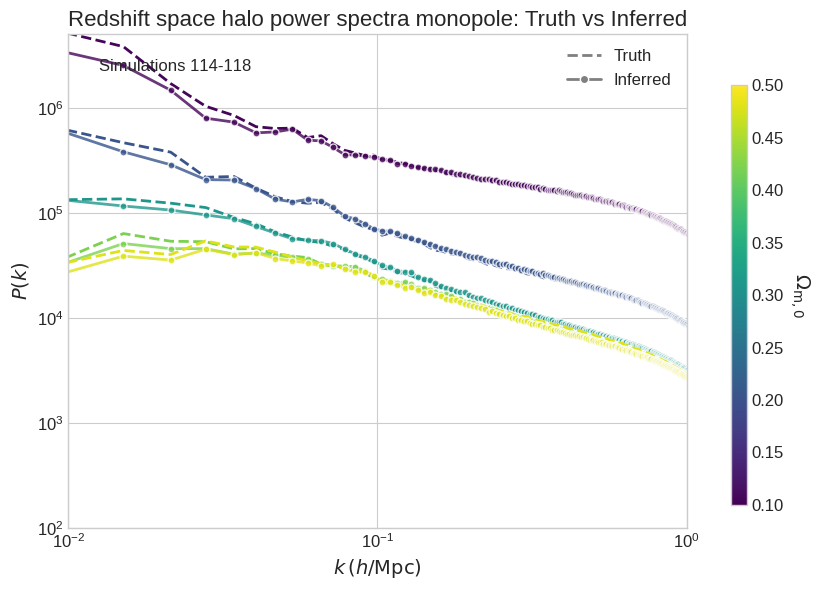

In [10]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colorbar import ColorbarBase

# Set the style
# plt.style.use('seaborn-v0_8-whitegrid')

# Create figure and axes with better size and resolution
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

# Load data
params_all = np.loadtxt('/projects/bdne/spandey3/halo_gotham/GOTHAM/prep_data/latin_hypercube_params.txt')
isim_fid_array = np.arange(114, 119)

# Create a colormap for Om0 values
cmap = plt.cm.viridis
norm = mcolors.Normalize(vmin=0.1, vmax=0.5)  # Range of Om0 from 0.1 to 0.5

# Set up the plot
ax.set_xlabel(r'$k \, (h/{\rm Mpc})$', fontsize=14)
ax.set_ylabel(r'$P(k)$', fontsize=14)
ax.set_title('Redshift space halo power spectra monopole: Truth vs Inferred', fontsize=16)
ax.set_yscale('log')
ax.set_xscale('log')
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xlim(0.01, 1)
ax.set_ylim(1e2, 5e6)

# Create plot lines with beautiful colors
for ji, isim in enumerate(isim_fid_array):
    Om0 = params_all[isim][0]
    sig8 = params_all[isim][-1]
    
    # Get color from Om0 value
    color = cmap(norm(Om0))
    
    # Process data
    
    # Plot with better styling
    ax.plot(Pk_all_rsd[isim]['k'], Pk_all_rsd[isim]['Pk_truth_ell0'], ls='--', marker='', color=color, 
            linewidth=2, label=f'Truth (Om0={Om0:.2f})')
    ax.plot(Pk_all_rsd[isim]['k'], Pk_all_rsd[isim]['Pk_pred_ell0'], ls='-', marker='o', color=color, 
            markersize=5, alpha=0.8, linewidth=2, markeredgecolor='white',
            label=f'Inferred (Om0={Om0:.2f})')

# Add a colorbar
cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cb = ColorbarBase(cax, cmap=cmap, norm=norm)
cb.set_label(r'$\Omega_{\mathrm{m,0}}$', fontsize=14, rotation=270, labelpad=20)
cb.ax.tick_params(labelsize=12)

# Create a custom legend that doesn't repeat for each simulation
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='gray', linestyle='--', lw=2, label='Truth'),
    Line2D([0], [0], color='gray', linestyle='-', marker='o', markeredgecolor='white', lw=2, label='Inferred')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=12)

# Add text about the simulation range
ax.text(0.05, 0.95, f'Simulations {isim_fid_array[0]}-{isim_fid_array[-1]}', 
        transform=ax.transAxes, fontsize=12, va='top')

# Adjust layout
plt.tight_layout(rect=[0, 0, 0.9, 1])  # Make room for the colorbar
# Save figure with high quality
# plt.savefig('halo_mass_distribution.png', dpi=300, bbox_inches='tight')

plt.show()




/tmp/ipykernel_1560154/2691335522.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Make room for the colorbar


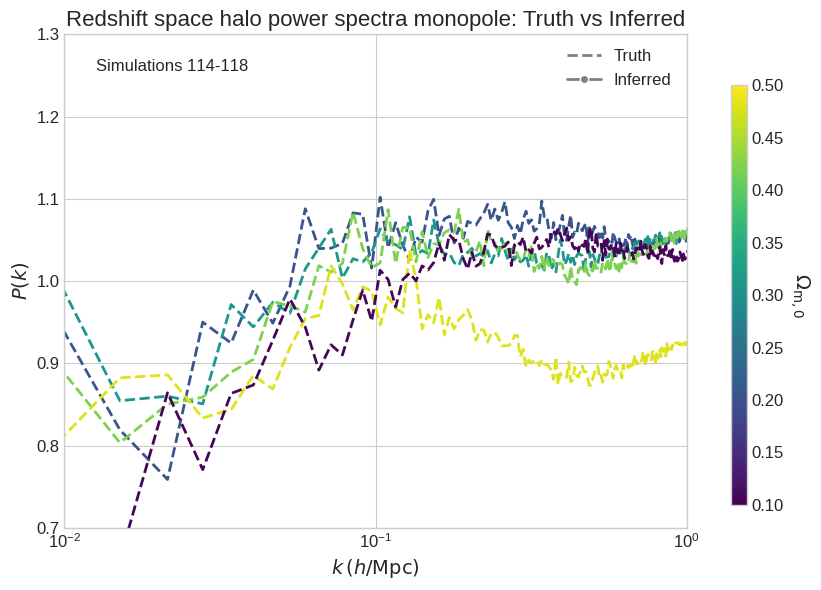

In [12]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colorbar import ColorbarBase

# Set the style
# plt.style.use('seaborn-v0_8-whitegrid')

# Create figure and axes with better size and resolution
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

# Load data
params_all = np.loadtxt('/projects/bdne/spandey3/halo_gotham/GOTHAM/prep_data/latin_hypercube_params.txt')
isim_fid_array = np.arange(114, 119)

# Create a colormap for Om0 values
cmap = plt.cm.viridis
norm = mcolors.Normalize(vmin=0.1, vmax=0.5)  # Range of Om0 from 0.1 to 0.5

# Set up the plot
ax.set_xlabel(r'$k \, (h/{\rm Mpc})$', fontsize=14)
ax.set_ylabel(r'$P(k)$', fontsize=14)
ax.set_title('Redshift space halo power spectra monopole: Truth vs Inferred', fontsize=16)
# ax.set_yscale('log')
ax.set_xscale('log')
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xlim(0.01, 1)
# ax.set_ylim(1e2, 5e6)
ax.set_ylim(0.7, 1.3)

# Create plot lines with beautiful colors
for ji, isim in enumerate(isim_fid_array):
    Om0 = params_all[isim][0]
    sig8 = params_all[isim][-1]
    
    # Get color from Om0 value
    color = cmap(norm(Om0))
    
    # Process data
    
    # Plot with better styling
    ax.plot(Pk_all_rsd[isim]['k'], Pk_all_rsd[isim]['Pk_pred_ell0']/Pk_all_rsd[isim]['Pk_truth_ell0'], ls='--', marker='', color=color, 
            linewidth=2, label=f'Truth (Om0={Om0:.2f})')
    # ax.plot(Pk_all_rsd[isim]['k'], Pk_all_rsd[isim]['Pk_pred_ell0'], ls='-', marker='o', color=color, 
    #         markersize=5, alpha=0.8, linewidth=2, markeredgecolor='white',
    #         label=f'Inferred (Om0={Om0:.2f})')

# Add a colorbar
cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cb = ColorbarBase(cax, cmap=cmap, norm=norm)
cb.set_label(r'$\Omega_{\mathrm{m,0}}$', fontsize=14, rotation=270, labelpad=20)
cb.ax.tick_params(labelsize=12)

# Create a custom legend that doesn't repeat for each simulation
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='gray', linestyle='--', lw=2, label='Truth'),
    Line2D([0], [0], color='gray', linestyle='-', marker='o', markeredgecolor='white', lw=2, label='Inferred')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=12)

# Add text about the simulation range
ax.text(0.05, 0.95, f'Simulations {isim_fid_array[0]}-{isim_fid_array[-1]}', 
        transform=ax.transAxes, fontsize=12, va='top')

# Adjust layout
plt.tight_layout(rect=[0, 0, 0.9, 1])  # Make room for the colorbar
# Save figure with high quality
# plt.savefig('halo_mass_distribution.png', dpi=300, bbox_inches='tight')

plt.show()




/tmp/ipykernel_1560154/3924112731.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Make room for the colorbar


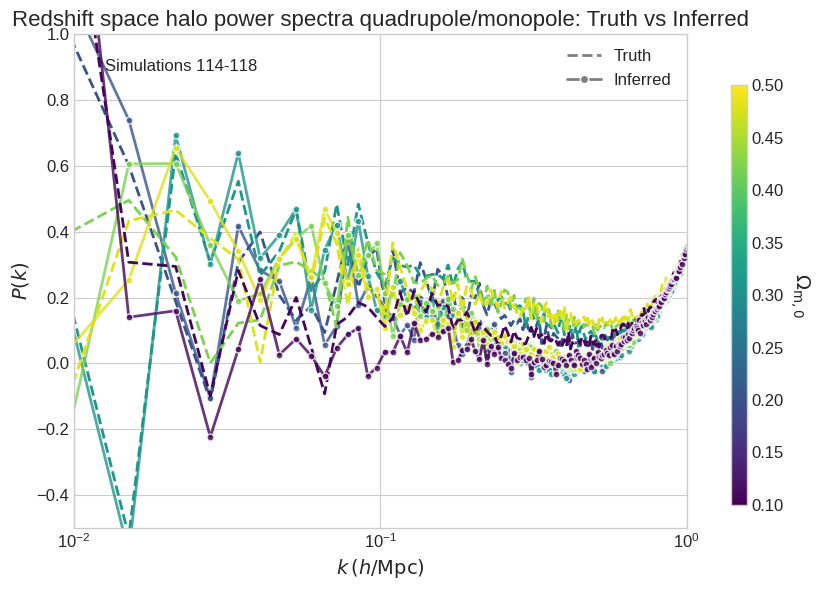

In [11]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colorbar import ColorbarBase

# Set the style
# plt.style.use('seaborn-v0_8-whitegrid')

# Create figure and axes with better size and resolution
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

# Load data
params_all = np.loadtxt('/projects/bdne/spandey3/halo_gotham/GOTHAM/prep_data/latin_hypercube_params.txt')
isim_fid_array = np.arange(114, 119)

# Create a colormap for Om0 values
cmap = plt.cm.viridis
norm = mcolors.Normalize(vmin=0.1, vmax=0.5)  # Range of Om0 from 0.1 to 0.5

# Set up the plot
ax.set_xlabel(r'$k \, (h/{\rm Mpc})$', fontsize=14)
ax.set_ylabel(r'$P(k)$', fontsize=14)
ax.set_title('Redshift space halo power spectra quadrupole/monopole: Truth vs Inferred', fontsize=16)
# ax.set_yscale('log')
ax.set_xscale('log')
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xlim(0.01, 1)
# ax.set_ylim(1e2, 5e6)
ax.set_ylim(-0.5, 1)

# Create plot lines with beautiful colors
for ji, isim in enumerate(isim_fid_array):
    Om0 = params_all[isim][0]
    sig8 = params_all[isim][-1]
    
    # Get color from Om0 value
    color = cmap(norm(Om0))
    
    # Process data
    
    # Plot with better styling
    ax.plot(Pk_all_rsd[isim]['k'], Pk_all_rsd[isim]['Pk_truth_ell2']/Pk_all_rsd[isim]['Pk_truth_ell0'], ls='--', marker='', color=color, 
            linewidth=2, label=f'Truth (Om0={Om0:.2f})')
    ax.plot(Pk_all_rsd[isim]['k'], Pk_all_rsd[isim]['Pk_pred_ell2']/Pk_all_rsd[isim]['Pk_pred_ell0'], ls='-', marker='o', color=color, 
            markersize=5, alpha=0.8, linewidth=2, markeredgecolor='white',
            label=f'Inferred (Om0={Om0:.2f})')
            

# Add a colorbar
cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cb = ColorbarBase(cax, cmap=cmap, norm=norm)
cb.set_label(r'$\Omega_{\mathrm{m,0}}$', fontsize=14, rotation=270, labelpad=20)
cb.ax.tick_params(labelsize=12)

# Create a custom legend that doesn't repeat for each simulation
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='gray', linestyle='--', lw=2, label='Truth'),
    Line2D([0], [0], color='gray', linestyle='-', marker='o', markeredgecolor='white', lw=2, label='Inferred')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=12)

# Add text about the simulation range
ax.text(0.05, 0.95, f'Simulations {isim_fid_array[0]}-{isim_fid_array[-1]}', 
        transform=ax.transAxes, fontsize=12, va='top')

# Adjust layout
plt.tight_layout(rect=[0, 0, 0.9, 1])  # Make room for the colorbar
# Save figure with high quality
# plt.savefig('halo_mass_distribution.png', dpi=300, bbox_inches='tight')

plt.show()




/tmp/ipykernel_740102/8738680.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


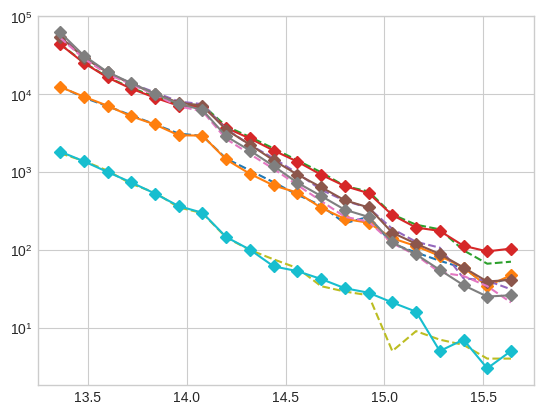

In [6]:
plt.figure()
params_all = np.loadtxt('/projects/bdne/spandey3/halo_gotham/GOTHAM/prep_data/latin_hypercube_params.txt')
isim_fid_array = np.arange(114, 119)
for ji in range(len(isim_fid_array)):
    isim = isim_fid_array[ji]

    Om0 = params_all[isim][0]
    sig8 = params_all[isim][-1]

    prop_truth_all = saved_all[isim]['prop_truth']
    prop_infer_all = saved_all[isim]['prop_infer']

    Mhalo_truth = prop_truth_all[:,0]
    Mhalo_infer = prop_infer_all[:,0]

    Mhalo_bins_edges = np.linspace(13.3, 15.7, 21)
    Mhalo_bins = 0.5 * (Mhalo_bins_edges[1:] + Mhalo_bins_edges[:-1])

    hist_Mhalo_truth = np.histogram(Mhalo_truth, bins=Mhalo_bins_edges)[0]
    hist_Mhalo_infer = np.histogram(Mhalo_infer, bins=Mhalo_bins_edges)[0]

    plt.plot(Mhalo_bins, hist_Mhalo_truth, ls='--', marker='')
    plt.plot(Mhalo_bins, hist_Mhalo_infer, ls='-', marker='D')

    # _ = plt.hist(prop_truth_all[:,0], bins=20, alpha=0.5, label='truth', range=(13.3, 15.7))
    # _ = plt.hist(prop_infer_all[:,0], bins=20, alpha=0.5, label='inferred', range=(13.3, 15.7))
    plt.yscale('log')
plt.legend()







In [ ]:
# idx_all_rs[0,30,0], X_val_rs[0,30,0]
# xarray




array([ 0.9765625,  2.9296875,  4.8828125,  6.8359375,  8.7890625,
       10.7421875, 12.6953125, 14.6484375, 16.6015625, 18.5546875,
       20.5078125, 22.4609375, 24.4140625, 26.3671875, 28.3203125,
       30.2734375])

In [5]:
# loss
# dim_tot
# ind_start_token + jh*ntokens_per_halo + 1 + jp
X_val_rs

array([[[[65, 19, 33, ..., 67, 67, 67],
         [65, 24, 39, ..., 67, 67, 67],
         [65, 13, 33, ..., 67, 67, 67],
         ...,
         [65,  6, 39, ..., 67, 67, 67],
         [65, 23, 35, ..., 67, 67, 67],
         [65, 19, 35, ..., 67, 67, 67]],

        [[65,  1, 40, ..., 67, 67, 67],
         [65,  1, 36, ..., 67, 67, 67],
         [65,  7, 27, ..., 67, 67, 67],
         ...,
         [65,  2, 45, ..., 67, 67, 67],
         [65,  9, 38, ..., 67, 67, 67],
         [65, 10, 42, ..., 67, 67, 67]],

        [[65, 12, 43, ..., 67, 67, 67],
         [65, 11, 35, ..., 67, 67, 67],
         [65, 25, 33, ..., 67, 67, 67],
         ...,
         [65, 22, 28, ..., 67, 67, 67],
         [65, 23, 19, ..., 67, 67, 67],
         [65, 13, 30, ..., 67, 67, 67]],

        ...,

        [[65, 11, 26, ..., 67, 67, 67],
         [65, 12, 32, ..., 67, 67, 67],
         [65,  8, 36, ..., 67, 67, 67],
         ...,
         [65, 10, 30, ..., 67, 67, 67],
         [65,  6, 39, ..., 67, 67, 67],
    

In [7]:
# probs.shape
# probs_to_plot = probs.detach().cpu().to(float).numpy()

plt.figure()
plt.plot(prob_to_plot[154,:])




TypeError: list indices must be integers or slices, not tuple

<Figure size 640x480 with 0 Axes>

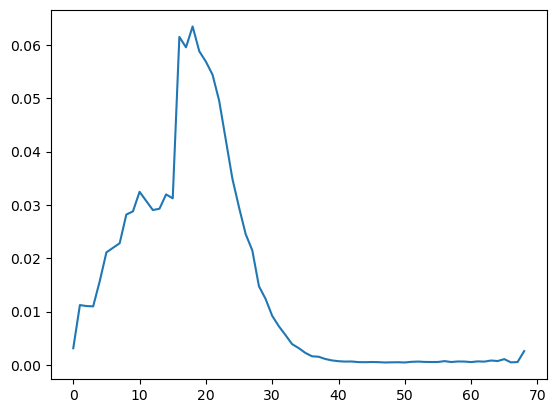

In [25]:
plt.figure()
plt.plot(probs_to_plot[154,:])



In [3]:
pos_truth_all.shape, prop_truth_all.shape, pos_infer_all.shape, prop_infer_all.shape




((154380, 3), (154380, 3), (149638, 3), (149638, 3))

In [25]:
prop_truth_all[:,0], prop_infer_all[:,0]






(array([13.71706667, 14.02213333, 13.7552    , ..., 13.37386667,
        13.48826667, 13.6408    ]),
 array([13.56453333, 13.60266667, 13.412     , ..., 13.5264    ,
        13.48826667, 13.45013333]))

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline



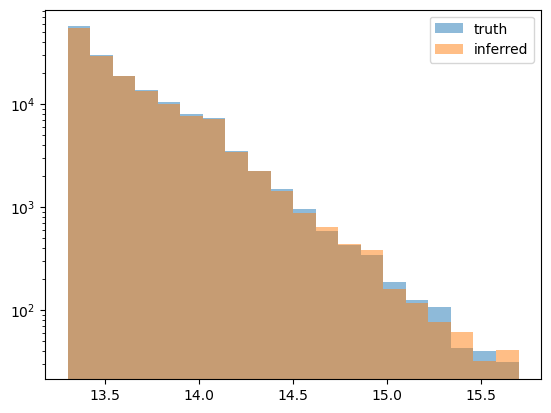

In [5]:
plt.figure()
_ = plt.hist(prop_truth_all[:,0], bins=20, alpha=0.5, label='truth', range=(13.3, 15.7))
_ = plt.hist(prop_infer_all[:,0], bins=20, alpha=0.5, label='inferred', range=(13.3, 15.7))
plt.yscale('log')
plt.legend()



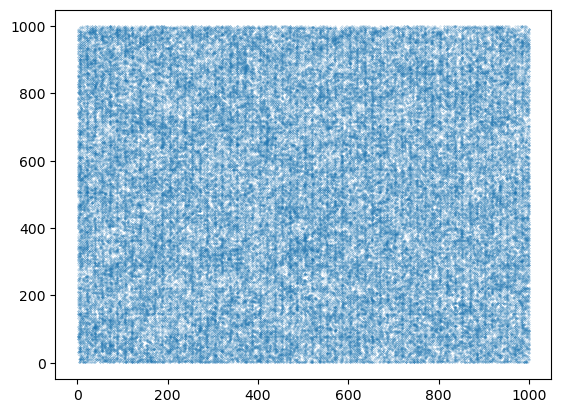

In [6]:
plt.figure()
plt.scatter(pos_truth_all[:,0], pos_truth_all[:,1], s=0.05, alpha=0.5)




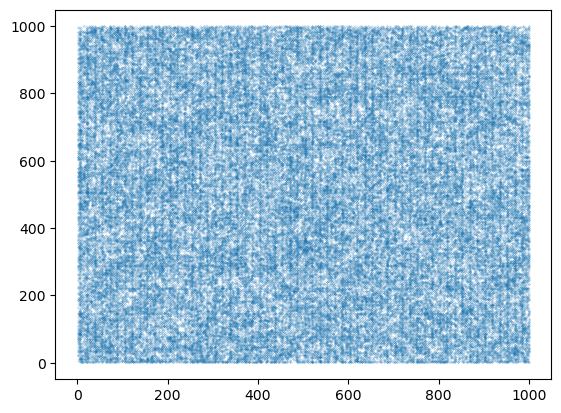

In [7]:
plt.figure()
plt.scatter(pos_infer_all[:,0], pos_infer_all[:,1], s=0.05, alpha=0.5)


In [43]:
# nrand_sel_box = 8192
# isfid = False
# nsims_tot = 2000
# n_gpus = 16
# train_fac = 0.75
# val_fac = 0.175
# test_fac = 0.075
# id_test_all = []
# sims_per_gpu = nsims_tot//n_gpus
# train_sims_per_gpu = int(train_fac * sims_per_gpu)
# val_sims_per_gpu = int(val_fac * sims_per_gpu)
# test_sims_per_gpu = int(test_fac * sims_per_gpu)
# for ji in range(n_gpus):
#     id_train_start = ji*sims_per_gpu
#     id_train_end = id_train_start + train_sims_per_gpu

#     id_val_start = id_train_end
#     id_val_end = id_val_start + val_sims_per_gpu

#     id_test_start = id_val_end
#     id_test_end = id_test_start + test_sims_per_gpu

#     # print(id_test_start, id_test_end)
#     id_test_all.append(np.arange(id_test_start, id_test_end))


In [44]:
# np.concatenate(id_test_all)


In [45]:
# # # idx_all
# idx_mat = np.array(idx_all)
# # find all the indices where idx_all is not equal to start_token, end_token, pad_token, and space_token:
# indsel = np.where((idx_mat != start_token) & (idx_mat != end_token) & (idx_mat != pad_token) & (idx_mat != space_token))
# print(len(indsel[0])//8)




In [46]:
# indsel[0].shape
# 5047591/8
# loss.item()

In [47]:
# # saved_all = pk.load(open('/projects/bdne/spandey3/halo_gotham/GOTHAM/infer_data/FINAL2_TEST_infer_halos_ng32_grid_8_isim_fid_113_113_nrandsubsel_32768_Mstarcut_12.7_spacetoken_False.pkl','rb')) 
# saved_all = pk.load(open('/projects/bdne/spandey3/halo_gotham/GOTHAM/infer_data/FINAL4_fidfinetune_TEST_infer_halos_ng32_grid_8_isim_fid_16_16_nrandsubsel_32768_Mstarcut_12.7_spacetoken_False.pkl','rb')) 
# # print(saved_all.keys())
# isim_fid = 16
# pos_truth_all = saved_all[isim_fid]['pos_truth']
# prop_truth_all = saved_all[isim_fid]['prop_truth']
# pos_infer_all = saved_all[isim_fid]['pos_infer']
# prop_infer_all = saved_all[isim_fid]['prop_infer']



In [48]:
# idx_all
# X_val[2,:]
# max_new_tokens, start_token,idx_all
# dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_0.shape
# prop_min, prop_max




In [49]:
# from tqdm import tqdm
# isim_fid_array = np.arange(975, 985)
# # isim_fid_array = np.arange(976, 977)
# for isim_fid in tqdm(isim_fid_array):

#     snapnum = 90
#     ldir = '/work/hdd/bdne/spandey3/camels_tng/hydro'
#     group_catalog = f'{ldir}/LH/LH_{isim_fid}/groups_0{snapnum}.hdf5'
#     photo_catalog = f'{ldir}/Photometry/IllustrisTNG/L25n256/LH/IllustrisTNG_LH_{isim_fid}_photometry.hdf5'
#     # open the catalogue
#     with h5.File(photo_catalog, "r") as hf:
#         subhalo_index = np.array(hf[f"snap_0{snapnum}/SubhaloIndex"][:], dtype=int)
#         g_band = np.log10(hf[f"snap_0{snapnum}/BC03/photometry/luminosity/attenuated/SLOAN/SDSS.g"][:])
#         r_band = np.log10(hf[f"snap_0{snapnum}/BC03/photometry/luminosity/attenuated/SLOAN/SDSS.r"][:])
#         i_band = np.log10(hf[f"snap_0{snapnum}/BC03/photometry/luminosity/attenuated/SLOAN/SDSS.i"][:])
    
#     # Read the stellar masses of the subhalos/galaxies
#     with h5.File(group_catalog, "r") as hf:
#         M_star = np.log10(hf['Subhalo/SubhaloMassType'][:,4]*1e10 + 0.01) # Stellar masses in Msun/h
#         pos = hf['Subhalo/SubhaloPos'][:]/1000.
#         vel = hf['Subhalo/SubhaloVel'][:]
    
#     M_star = M_star[subhalo_index]
#     pos_truth_orig = pos[subhalo_index]
#     vel_truth_orig = vel[subhalo_index][:,0]

#     indsel2 = np.where(M_star > 8.25)[0]
#     print(len(M_star), len(indsel2))
    


In [50]:
2+2


4

In [51]:
# def get_prop_pos(X_val):
#     pos_infer_all = []
#     prop_infer_all = []
    
#     for jx in range(grid):
#         for jy in range(grid):
#             for jz in range(grid):
#                 sentence_here = X_val[jx, jy, jz]
#                 if add_space_token:
#                     ntokens_per_halo = dim_tot + 1
#                 else:
#                     ntokens_per_halo = dim_tot
#                 ind_start_token = np.where(sentence_here == start_token)[0][0]
#                 if end_token in sentence_here:
#                     ind_end_token = np.where(sentence_here == end_token)[0]
#                     try:
#                         Nhalos_here = ((ind_end_token - ind_start_token - 1) / ntokens_per_halo)[0]
#                     except:
#                         print(ind_end_token, ind_start_token, ntokens_per_halo)
#                     if (int(Nhalos_here) - Nhalos_here) != 0:
#                         print('Nhalos_here is not an integer')
#                     else:
#                         if Nhalos_here > 0:
#                             for jh in range(int(Nhalos_here)):
#                                 try:
#                                     coord_x = (xarray[sentence_here[ind_start_token + jh*ntokens_per_halo + 1]] + (BoxSize/grid)*jx) % BoxSize
#                                     coord_y = (yarray[sentence_here[ind_start_token + jh*ntokens_per_halo + 2]] + (BoxSize/grid)*jy) % BoxSize
#                                     coord_z = (zarray[sentence_here[ind_start_token + jh*ntokens_per_halo + 3]] + (BoxSize/grid)*jz) % BoxSize
#                                 except:
#                                     print(sentence_here[ind_start_token], ntokens_per_halo)
    
#                                 pos_infer_all.append([coord_x, coord_y, coord_z])
#                                 prop_all = np.zeros(dim_prop)
#                                 for jp in range(dim_prop):
#                                     # noise_val = np.random.uniform(-delta_bin/2, delta_bin/2)
#                                     noise_val = 0
#                                     bin_val_jp = sentence_here[ind_start_token + jh*ntokens_per_halo + 4 + jp]
#                                     prop_all[jp] = prop_min[jp] + (prop_max[jp] - prop_min[jp]) * (bins_digitize[bin_val_jp] + noise_val)
#                                 prop_infer_all.append(prop_all)
#                 else:           
#                     print('End token not found')
    
#     pos_infer_all = np.array(pos_infer_all)
#     prop_infer_all = np.array(prop_infer_all)
#     return pos_infer_all, prop_infer_all

# idx_all_rs = np.reshape(np.array(idx_all), (grid, grid, grid, idx_all.shape[-1])).astype(int)
# X_val_rs = np.reshape(X_val.cpu().numpy(), (grid, grid, grid, X_val.shape[-1])).astype(int)
# pos_infer_all, prop_infer_all = get_prop_pos(idx_all_rs)



In [8]:
pos_infer_all.shape, pos_truth_all.shape



((149638, 3), (154380, 3))

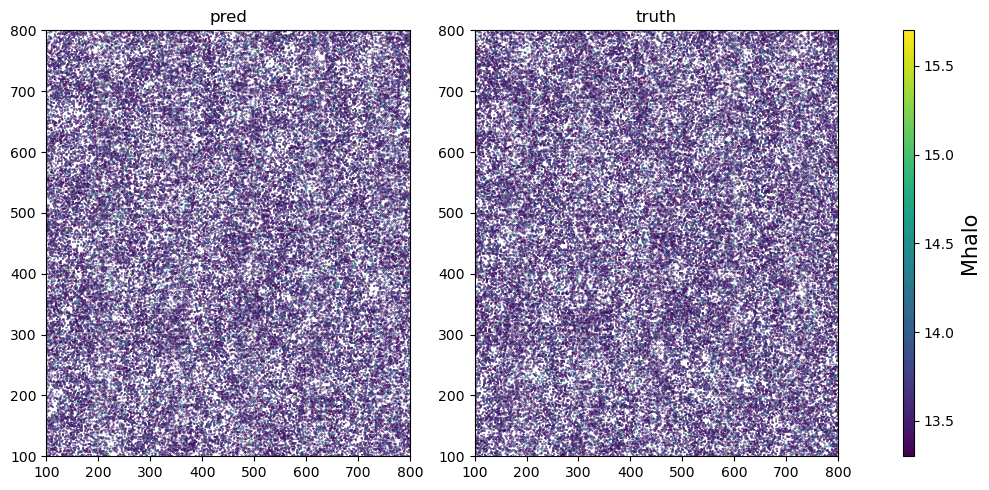

In [9]:
import matplotlib.pyplot as pl
import numpy as np
import matplotlib.gridspec as gridspec

# isim_fid = 937
# prop_min, prop_max = 26, 29

prop_min_h = 13.3
prop_max_h = 15.7


fig = pl.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 0.03])  # Two equal subplots and a narrow colorbar

ax1 = pl.subplot(gs[0])
sc = ax1.scatter(pos_infer_all[:, 0], pos_infer_all[:, 1], c=np.clip(prop_infer_all[:,0], prop_min_h, prop_max_h), cmap='viridis', s=0.1)
ax1.set_title('pred')
ax1.grid(alpha=0.2)

ax1.set_xlim(100, 800)
ax1.set_ylim(100, 800)

# ax1.set_xlim(100, 200)
# ax1.set_ylim(100, 200)

ax2 = pl.subplot(gs[1])
sc = ax2.scatter(pos_truth_all[:, 0], pos_truth_all[:, 1], c=np.clip(prop_truth_all[:,0], prop_min_h, prop_max_h), cmap='viridis', s=0.1)
ax2.set_title('truth')
# ax2.grid()
ax2.set_xlim(100, 800)
ax2.set_ylim(100, 800)
ax2.grid(alpha=0.2)
# ax2.set_xlim(100, 200)
# ax2.set_ylim(100, 200)


cax = pl.subplot(gs[2])  # Colorbar axis
colorbar = pl.colorbar(sc, cax=cax)
colorbar.set_label('Mhalo', fontsize=15)

pl.tight_layout()
pl.show()




In [96]:
# isim_fid_array


In [10]:
import Pk_library as PKL
import MAS_library as MASL

grid_Pk = 512
MAS = 'NGP'
# MAS = 'TSC'

# MAS = 'CIC'

BoxSize = 1000.
# saved_all[isim_fid] = {'pos_truth':pos_truth_all, 'prop_truth':prop_truth_all, 'pos_infer':pos_infer_all, 'prop_infer':prop_infer_all}


Pk_all_truth = []
Pk_all_mock = []
Pk_all_ratio = []
Pk_all_ratio2 = []
# isim_fid_array = [113]
# isim_fid_array = [16]
for isim_fid in isim_fid_array:

    # # pos_truth_all = saved_all[isim_fid]['pos_truth']
    # mesh_truth = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
    # MASL.MA(pos_truth_all.astype(np.float32), mesh_truth, BoxSize, MAS)
    # mesh_truth /= np.mean(mesh_truth, dtype=np.float64);  mesh_truth -= 1.0
    # Pk_truth = PKL.Pk(mesh_truth, BoxSize, axis=0, MAS=None, verbose=False)
    # Pk_all_truth.append(Pk_truth.Pk[:,0])
    
    pos_infer_all = saved_all[isim_fid]['pos_infer']
    mesh_pred = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
    MASL.MA(pos_infer_all.astype(np.float32), mesh_pred, BoxSize, MAS)
    mesh_pred /= np.mean(mesh_pred, dtype=np.float64);  mesh_pred -= 1.0
    Pk_pred = PKL.Pk(mesh_pred, BoxSize, axis=0, MAS=None,  verbose=False)
    Pk_all_mock.append(Pk_pred.Pk[:,0])

    # Pk_all_ratio.append(Pk_pred.Pk[:,0]/Pk_truth.Pk[:,0])

    pos_truth_all = saved_all[isim_fid]['pos_truth']
    mesh_truth = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
    MASL.MA(pos_truth_all.astype(np.float32), mesh_truth, BoxSize, MAS)
    mesh_truth /= np.mean(mesh_truth, dtype=np.float64);  mesh_truth -= 1.0
    Pk_truth2 = PKL.Pk(mesh_truth, BoxSize, axis=0, MAS=None, verbose=False)
    Pk_all_ratio2.append(Pk_pred.Pk[:,0]/Pk_truth2.Pk[:,0])
    # Pk_all_truth.append(Pk_truth.Pk[:,0])



In [9]:
# np.log(1.01 + mesh_pred[256, :, :])




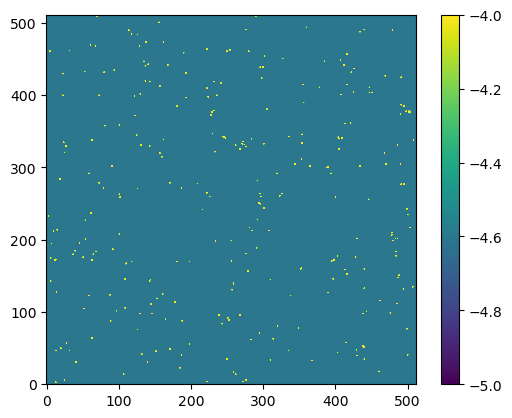

In [11]:
pl.figure()
pl.imshow(np.log(1.01 + mesh_pred[256, :, :]), origin='lower', cmap='viridis', vmin = -5, vmax = -4)
pl.colorbar()




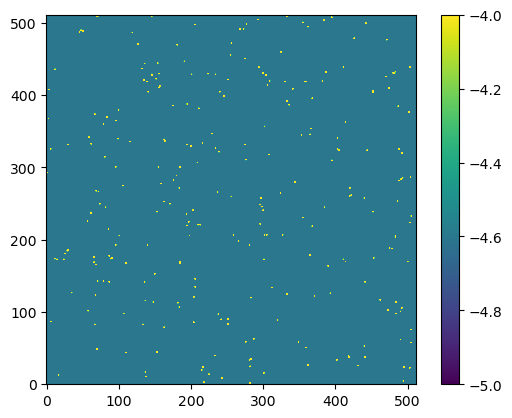

In [12]:
pl.figure()
pl.imshow(np.log(1.01 + mesh_truth[256, :, :]), origin='lower', cmap='viridis', vmin = -5, vmax = -4)
pl.colorbar()




Text(0, 0.5, 'Histogram')

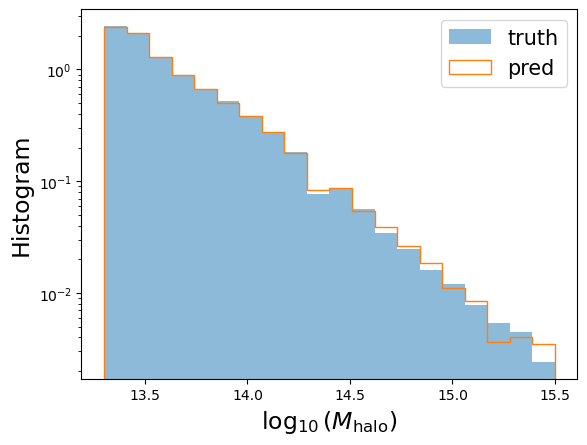

In [13]:
pl.figure()
_ = pl.hist(prop_truth_all[:,0], bins=20, alpha=0.5, label='truth', range=(13.3, 15.5), density=True)
_ = pl.hist(prop_infer_all[:,0], bins=20, alpha=1.0, label='pred', range=(13.3, 15.5), histtype='step', density=True)
pl.yscale('log')
pl.legend(fontsize=15)
pl.xlabel(r'$\log_{10}(M_{\rm halo})$', fontsize=17)
pl.ylabel('Histogram', fontsize=17)




Text(0, 0.5, 'Histogram')

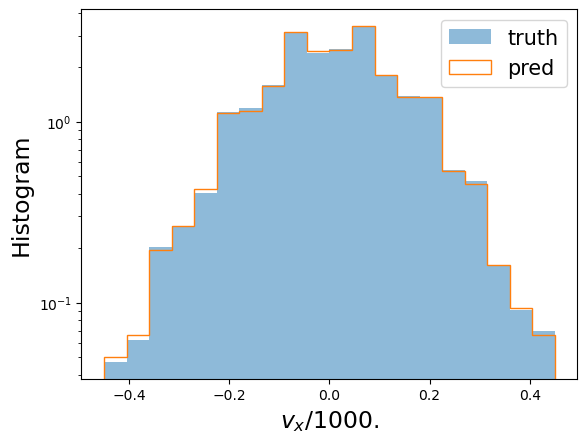

In [14]:
pl.figure()
_ = pl.hist(prop_truth_all[:,1], bins=20, alpha=0.5, label='truth', range=(-0.45, 0.45), density=True)
_ = pl.hist(prop_infer_all[:,1], bins=20, alpha=1.0, label='pred', range=(-0.45, 0.45), histtype='step', density=True)
pl.yscale('log')
pl.legend(fontsize=15)
pl.xlabel(r'$v_x/1000.$', fontsize=17)
pl.ylabel('Histogram', fontsize=17)


Text(0, 0.5, 'Histogram')

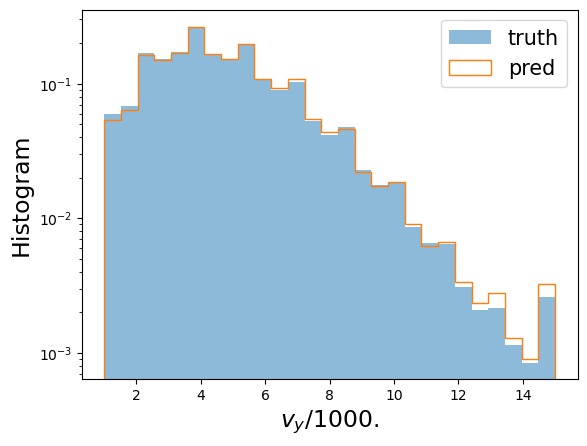

In [15]:
pl.figure()
_ = pl.hist(prop_truth_all[:,2], bins=27, alpha=0.5, label='truth', range=(1, 15), density=True)
_ = pl.hist(prop_infer_all[:,2], bins=27, alpha=1.0, label='pred', range=(1, 15), histtype='step', density=True)
pl.yscale('log')
pl.legend(fontsize=15)
pl.xlabel(r'$v_y/1000.$', fontsize=17)
pl.ylabel('Histogram', fontsize=17)


In [16]:
# pl.figure()
# _ = pl.hist(prop_truth_all[:,4], bins=20, alpha=0.5, label='truth', range=(0.5, 15), density=True)
# _ = pl.hist(prop_infer_all[:,4], bins=20, alpha=1.0, label='pred', range=(0.5, 15), histtype='step', density=True)
# pl.yscale('log')
# pl.legend(fontsize=15)
# pl.xlabel(r'Concentration', fontsize=17)
# pl.ylabel('Histogram', fontsize=17)





In [17]:
1/(pos_infer_all.shape[0]/BoxSize**3), 1/(pos_truth_all.shape[0]/BoxSize**3)



(6682.794477338643, 6477.522995206633)

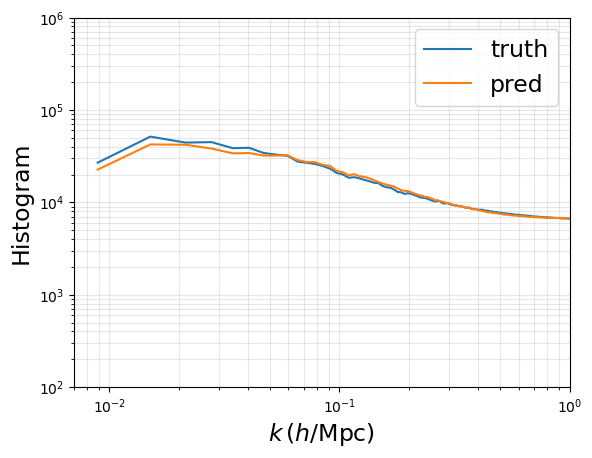

In [18]:
pl.figure()

# pl.plot(Pk_truth2.k3D, Pk_truth2.Pk[:,0] - 1/(pos_truth_all.shape[0]/BoxSize**3), label='truth')
# pl.plot(Pk_pred.k3D, Pk_pred.Pk[:,0] - 1/(pos_infer_all.shape[0]/BoxSize**3), label='mock')
pl.plot(Pk_truth2.k3D, Pk_truth2.Pk[:,0], label='truth')
pl.plot(Pk_pred.k3D, Pk_pred.Pk[:,0], label='pred')
# 

pl.xscale('log')
pl.yscale('log')
pl.xlim(7e-3, 1.0)
pl.ylim(100, 1e6)
pl.legend(fontsize=17)
pl.xlabel(r'$k \, (h/{\rm Mpc})$', fontsize=17)
pl.ylabel(r'$P(k)$', fontsize=17)
pl.ylabel('Histogram', fontsize=17)
pl.grid(which='both', alpha=0.3)




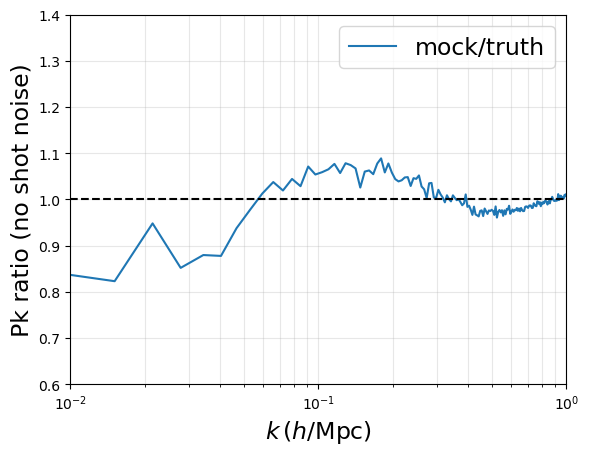

In [19]:
pl.figure()
# pl.plot(Pk_pred.k3D, (Pk_pred.Pk[:,0] - 1/(pos_infer_all.shape[0]/BoxSize**3))/(Pk_truth2.Pk[:,0] - 1/(pos_truth_all.shape[0]/BoxSize**3)), label='mock/truth')
pl.plot(Pk_pred.k3D, (Pk_pred.Pk[:,0])/(Pk_truth2.Pk[:,0]), label='mock/truth')
# pl.plot(Pk_truth2.k3D, , label='truth')
# pl.plot(Pk_truth2.k3D, Pk_truth2.Pk[:,0], label='truth')
# pl.plot(Pk_pred.k3D, Pk_pred.Pk[:,0], label='pred')


pl.xscale('log')
pl.axhline(1.0, color='black', linestyle='--')
# pl.yscale('log')
# pl.xlim(1e-2, 10.0)
pl.xlim(1e-2, 1.0)
# pl.ylim(10, 1e5)
pl.ylim(0.6, 1.4)
pl.legend(fontsize=17)
pl.xlabel(r'$k \, (h/{\rm Mpc})$', fontsize=17)
pl.ylabel(r'$P(k)$', fontsize=17)
pl.ylabel('Pk ratio (no shot noise)', fontsize=17)
pl.grid(which='both', alpha=0.3)




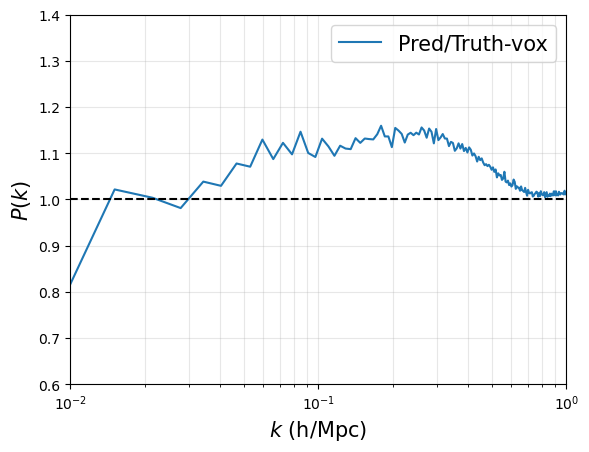

In [8]:
# Pk_all_ratio_array = np.array(Pk_all_ratio)
# Pk_all_ratio_mean = np.mean(Pk_all_ratio_array, axis=0)
# Pk_all_ratio_std = np.std(Pk_all_ratio_array, axis=0)

Pk_all_ratio_array2 = np.array(Pk_all_ratio2)
Pk_all_ratio_mean2 = np.mean(Pk_all_ratio_array2, axis=0)
Pk_all_ratio_std2 = np.std(Pk_all_ratio_array2, axis=0)


# np.array(Pk_all_ratio).shape
pl.figure()
# pl.plot(Pk_truth.k3D, Pk_all_ratio_mean, label='Pred/Truth')
pl.plot(Pk_truth2.k3D, Pk_all_ratio_mean2, label='Pred/Truth-vox')
# pl.fill_between(Pk_truth2.k3D, 1-Pk_all_ratio_std2, 1+Pk_all_ratio_std2, alpha=0.2)
pl.axhline(1, ls='--', color='k')
pl.xlabel(r'$k$ (h/Mpc)', fontsize=15)
pl.ylabel(r'$P(k)$', fontsize=15)
# pl.ylim(0.9, 1.1)
pl.ylim(0.6, 1.4)
pl.xlim(1e-2, 1.0)
# pl.xlim(0, 10)
# pl.yscale('log')
pl.xscale('log')
pl.legend(fontsize=15)
pl.grid(which='both', alpha=0.3)



In [58]:
np.arange(16)[1::2]

array([ 1,  3,  5,  7,  9, 11, 13, 15])

In [33]:
# pl.figure()
# pl.plot(Pk_truth.k3D, Pk_pred.Pk[:,0]/Pk_truth.Pk[:,0], label='Truth/Pred')
# pl.axhline(1, ls='--', color='k')
# pl.xlabel(r'$k$ (h/Mpc)', fontsize=15)
# pl.ylabel(r'$P(k)$', fontsize=15)
# # pl.ylim(0.9, 1.1)
# pl.ylim(0.3, 1.7)
# pl.xlim(0, 10)
# # pl.yscale('log')
# # pl.xscale('log')
# pl.legend(fontsize=15)



In [16]:
grid_Pk = 256
MAS = 'CIC'
Pk_all_truth = []
Pk_all_mock = []
Pk_all_ratio = []
Pk_all_ratio2 = []
Pk_all_ratio3 = []

for isim_fid in isim_fid_array:
    Om = params_all[isim_fid, 0]
    z=0
    Hz = 100.0 * np.sqrt(Om * (1. + z)**3 + (1 - Om))
    rsd_factor = (1. + z) / Hz
    snapnum = 90
    ldir = '/work/hdd/bdne/spandey3/camels_tng/hydro'
    group_catalog = f'{ldir}/LH/LH_{isim_fid}/groups_0{snapnum}.hdf5'
    photo_catalog = f'{ldir}/Photometry/IllustrisTNG/L25n256/LH/IllustrisTNG_LH_{isim_fid}_photometry.hdf5'
    # open the catalogue
    with h5.File(photo_catalog, "r") as hf:
        subhalo_index = np.array(hf[f"snap_0{snapnum}/SubhaloIndex"][:], dtype=int)
        g_band = np.log10(hf[f"snap_0{snapnum}/BC03/photometry/luminosity/attenuated/SLOAN/SDSS.g"][:])
        r_band = np.log10(hf[f"snap_0{snapnum}/BC03/photometry/luminosity/attenuated/SLOAN/SDSS.r"][:])
        i_band = np.log10(hf[f"snap_0{snapnum}/BC03/photometry/luminosity/attenuated/SLOAN/SDSS.i"][:])
    
    # Read the stellar masses of the subhalos/galaxies
    with h5.File(group_catalog, "r") as hf:
        M_star = np.log10(hf['Subhalo/SubhaloMassType'][:,4]*1e10 + 0.01) # Stellar masses in Msun/h
        pos = hf['Subhalo/SubhaloPos'][:]/1000.
        vel = hf['Subhalo/SubhaloVel'][:]
    
    M_star = M_star[subhalo_index]
    pos_truth = pos[subhalo_index]
    vel_truth = vel[subhalo_index][:,0]
    indsel = np.where(M_star > Mstar_cut)[0]
    pos_truth = pos_truth[indsel,:]
    vel_truth = vel_truth[indsel]
    
    # pos_truth_all = saved_all[isim_fid]['pos_truth']
    # prop_truth_all = saved_all[isim_fid]['prop_truth']
    # pos_truth = np.copy(pos_truth_all)
    # vel_truth = np.copy(prop_truth_all[:,-1]) * 1000.    
    mesh_truth = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
    pos_truth[:,0] = (pos_truth[:,0] + (vel_truth * rsd_factor))%(BoxSize)
    MASL.MA(pos_truth.astype(np.float32), mesh_truth, BoxSize, MAS)
    mesh_truth /= np.mean(mesh_truth, dtype=np.float64);  mesh_truth -= 1.0
    Pk_truth = PKL.Pk(mesh_truth, BoxSize, axis=0, MAS=None, verbose=False)
    Pk_all_truth.append(Pk_truth.Pk[:,0])

    
    pos_infer_all = saved_all[isim_fid]['pos_infer']
    prop_infer_all = saved_all[isim_fid]['prop_infer']
    mesh_pred = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
    pos_pred = np.copy(pos_infer_all)
    vel_pred = np.copy(prop_infer_all[:, -1] * 1000.0)
    pos_pred[:,0] = (pos_pred[:,0] + (vel_pred * rsd_factor))%(BoxSize)
    MASL.MA(pos_pred.astype(np.float32), mesh_pred, BoxSize, MAS)
    mesh_pred /= np.mean(mesh_pred, dtype=np.float64);  mesh_pred -= 1.0
    Pk_pred = PKL.Pk(mesh_pred, BoxSize, axis=0, MAS=None,  verbose=False)
    Pk_all_mock.append(Pk_pred.Pk[:,0])

    Pk_all_ratio.append(Pk_pred.Pk[:,0]/Pk_truth.Pk[:,0])

    pos_truth_all = saved_all[isim_fid]['pos_truth']
    prop_truth_all = saved_all[isim_fid]['prop_truth']
    pos_truth = np.copy(pos_truth_all)
    vel_truth = np.copy(prop_truth_all[:,-1]) * 1000.    
    mesh_truth = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
    pos_truth[:,0] = (pos_truth[:,0] + (vel_truth * rsd_factor))%(BoxSize)
    MASL.MA(pos_truth.astype(np.float32), mesh_truth, BoxSize, MAS)
    mesh_truth /= np.mean(mesh_truth, dtype=np.float64);  mesh_truth -= 1.0
    Pk_truth2 = PKL.Pk(mesh_truth, BoxSize, axis=0, MAS=None, verbose=False)
    Pk_all_ratio2.append(Pk_pred.Pk[:,0]/Pk_truth2.Pk[:,0])

    Pk_all_ratio3.append(Pk_truth2.Pk[:,0]/Pk_truth.Pk[:,0])




/tmp/ipykernel_787986/168376543.py:4: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('retina')


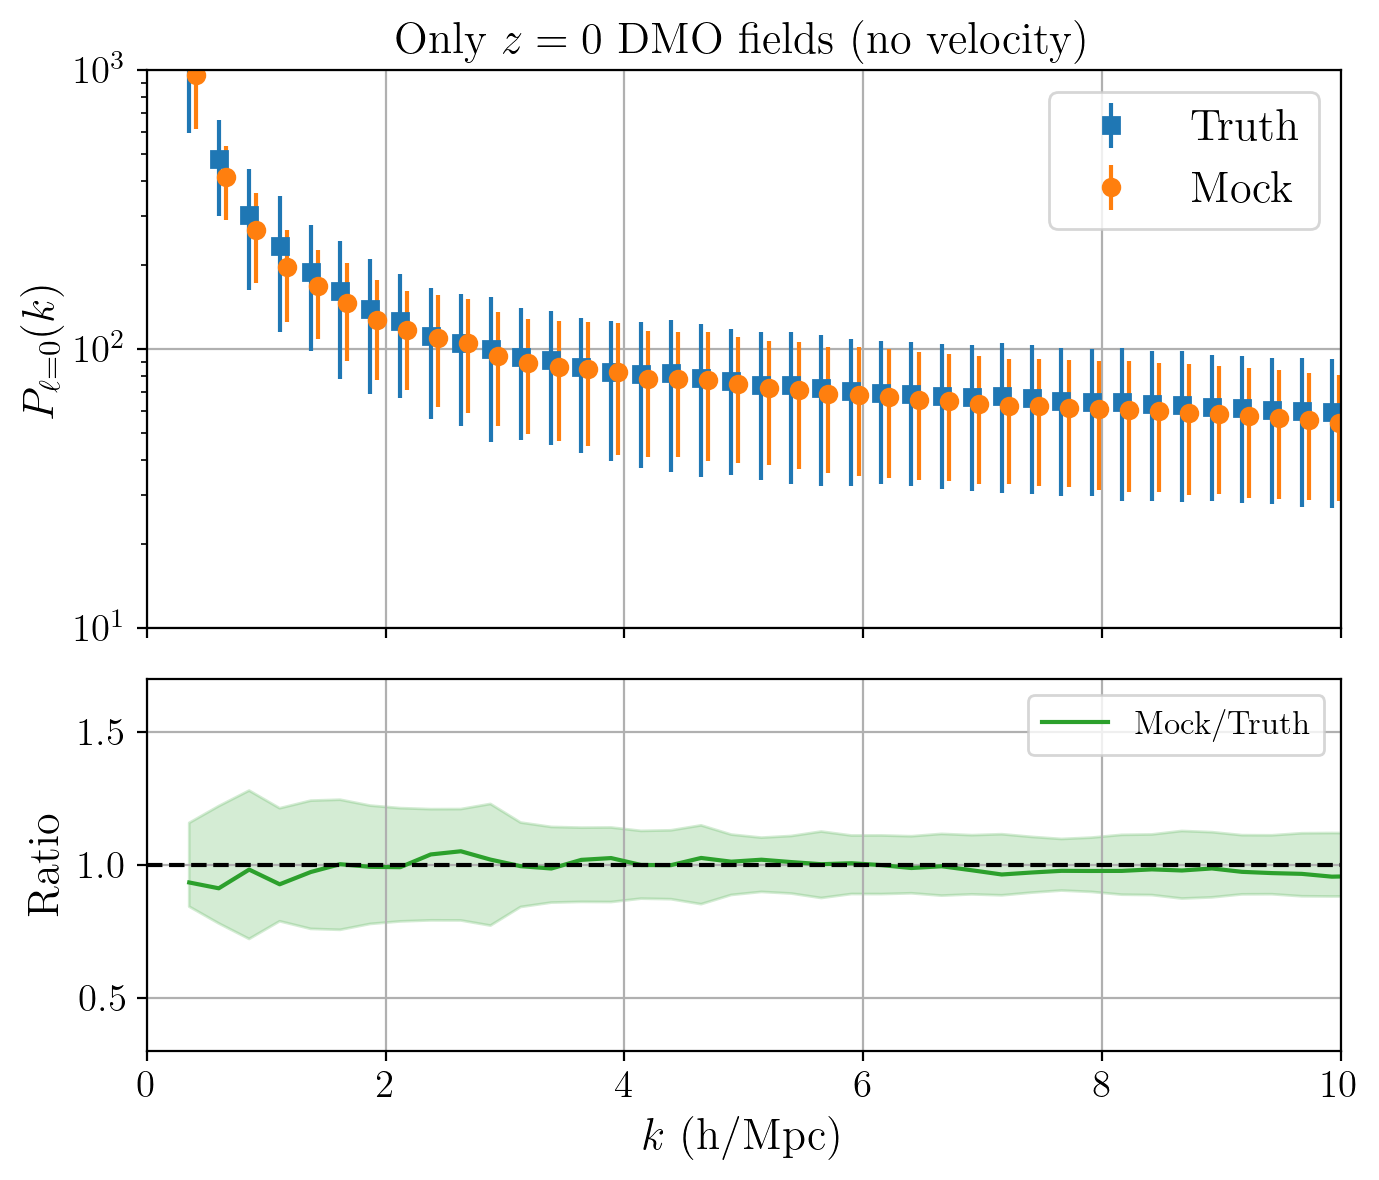

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina')

# Convert lists to numpy arrays
Pk_all_truth_array = np.array(Pk_all_truth)
Pk_all_mock_array = np.array(Pk_all_mock)
Pk_all_ratio_array = np.array(Pk_all_ratio)

# Compute mean and standard deviation
Pk_all_truth_mean = np.mean(Pk_all_truth_array, axis=0)
Pk_all_mock_mean = np.mean(Pk_all_mock_array, axis=0)
Pk_all_truth_std = np.std(Pk_all_truth_array, axis=0)
Pk_all_mock_std = np.std(Pk_all_mock_array, axis=0)

Pk_all_ratio_mean = np.mean(Pk_all_ratio_array, axis=0)
Pk_all_ratio_std = np.std(Pk_all_ratio_array, axis=0)

# Create figure with two panels
fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True, gridspec_kw={'height_ratios': [3, 2]}, figsize=(7, 6))

# Top panel: Comparison between truth and mock
ax1 = axes[0]
# ax1.plot(Pk_truth.k3D, Pk_all_truth_mean, label='Truth', color='C0')
# ax1.fill_between(Pk_truth.k3D, Pk_all_truth_mean - Pk_all_truth_std, 
#                  Pk_all_truth_mean + Pk_all_truth_std, color='C0', alpha=0.2)
# ax1.plot(Pk_truth.k3D, Pk_all_mock_mean, label='Mock', color='C1')

ax1.errorbar(Pk_truth.k3D, Pk_all_truth_mean,Pk_all_truth_std, label='Truth', ls='', marker='s', color='C0')
# ax1.fill_between(Pk_truth.k3D, Pk_all_truth_mean - Pk_all_truth_std, 
                 # Pk_all_truth_mean + Pk_all_truth_std, color='C0', alpha=0.2)
ax1.errorbar(Pk_truth.k3D+0.06, Pk_all_mock_mean, Pk_all_mock_std, label='Mock', ls='', marker='o', color='C1')

ax1.set_ylabel(r'$P_{\ell = 0}(k)$', fontsize=16)
ax1.set_xlim(0, 10)
ax1.legend(fontsize=16)
ax1.set_ylim(10, 1e3)
ax1.grid()
ax1.set_yscale('log')
ax1.tick_params(axis='both', labelsize=14)
ax1.set_title(r'Only $z=0$ DMO fields (no velocity)', size=16)

# Bottom panel: Ratio plot
ax2 = axes[1]
ax2.plot(Pk_truth.k3D, Pk_all_ratio_mean, label='Mock/Truth', color='C2')
ax2.fill_between(Pk_truth.k3D, 1 - Pk_all_ratio_std, 1 + Pk_all_ratio_std, color='C2', alpha=0.2)
ax2.axhline(1, ls='--', color='k')  # Reference line at 1
ax2.set_xlabel(r'$k$ (h/Mpc)', fontsize=16)
ax2.set_ylabel('Ratio', fontsize=16)
# ax2.set_ylim(0.5, 1.5)  # Adjusting limits for better visibility
ax2.set_ylim(0.3, 1.7)
ax2.set_xlim(0, 10)
ax2.grid()
ax2.legend(fontsize=12)
# Increase tick label size

ax2.tick_params(axis='both', labelsize=14)  # Slightly smaller for the ratio plot
# Adjust spacing
plt.tight_layout()
plt.show()



Text(0.5, 1.0, 'with space token')

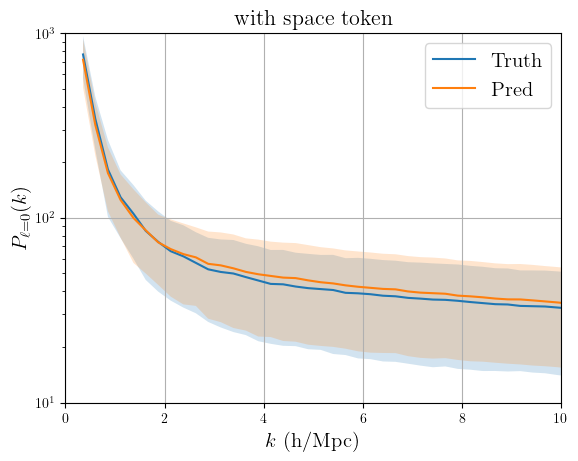

In [25]:
Pk_all_truth_array = np.array(Pk_all_truth)
Pk_all_mock_array = np.array(Pk_all_mock)
Pk_all_truth_mean = np.mean(Pk_all_truth_array, axis=0)
Pk_all_truth_std = np.std(Pk_all_truth_array, axis=0)
Pk_all_mock_mean = np.mean(Pk_all_mock_array, axis=0)
Pk_all_mock_std = np.std(Pk_all_mock_array, axis=0)
# np.array(Pk_all_ratio).shape
pl.figure()
pl.plot(Pk_truth.k3D, Pk_all_truth_mean, label='Truth')
pl.fill_between(Pk_truth.k3D, Pk_all_truth_mean-Pk_all_truth_std, Pk_all_truth_mean+Pk_all_truth_std, alpha=0.2)
pl.plot(Pk_truth.k3D, Pk_all_mock_mean, label='Pred')
pl.fill_between(Pk_truth.k3D, Pk_all_mock_mean-Pk_all_mock_std, Pk_all_mock_mean+Pk_all_mock_std, alpha=0.2)
# pl.fill_between(Pk_truth.k3D, 1-Pk_all_ratio_std, 1+Pk_all_ratio_std, label='Pred/Truth', alpha=0.2)
# pl.axhline(1, ls='--', color='k')
pl.xlabel(r'$k$ (h/Mpc)', fontsize=15)
pl.ylabel(r'$P_{\ell = 0}(k)$', fontsize=15)
pl.ylim(10, 1e3)
# pl.ylim(0.0, 2.0)
pl.xlim(0, 10)
pl.yscale('log')
# pl.xscale('log')
pl.legend(fontsize=15)
pl.grid()
# pl.title('No space token', size=16)
pl.title('with space token', size=16)





Text(0.5, 1.0, 'with space token')

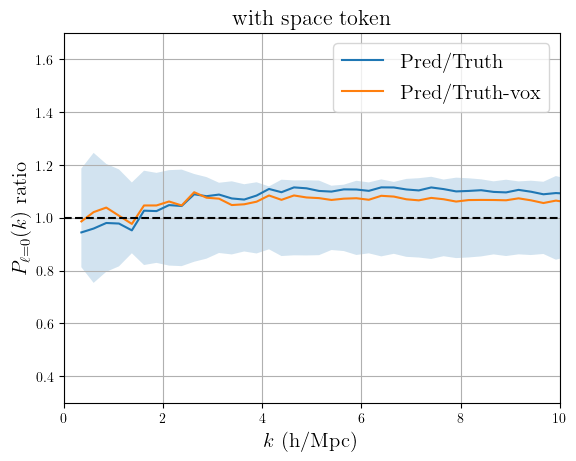

In [28]:
Pk_all_ratio_array = np.array(Pk_all_ratio)
Pk_all_ratio_mean = np.mean(Pk_all_ratio_array, axis=0)
Pk_all_ratio_std = np.std(Pk_all_ratio_array, axis=0)

Pk_all_ratio_array2 = np.array(Pk_all_ratio2)
Pk_all_ratio_mean2 = np.mean(Pk_all_ratio_array2, axis=0)
Pk_all_ratio_std2 = np.std(Pk_all_ratio_array2, axis=0)

Pk_all_ratio_array3 = np.array(Pk_all_ratio3)
Pk_all_ratio_mean3 = np.mean(Pk_all_ratio_array3, axis=0)
Pk_all_ratio_std3 = np.std(Pk_all_ratio_array3, axis=0)

# np.array(Pk_all_ratio).shape
pl.figure()
pl.plot(Pk_truth.k3D, Pk_all_ratio_mean, label='Pred/Truth')
pl.plot(Pk_truth.k3D, Pk_all_ratio_mean2, label='Pred/Truth-vox')
# pl.plot(Pk_truth.k3D, Pk_all_ratio_mean3, label='Truth2/Truth')
pl.fill_between(Pk_truth.k3D, 1-Pk_all_ratio_std, 1+Pk_all_ratio_std, alpha=0.2)
pl.axhline(1, ls='--', color='k')
pl.xlabel(r'$k$ (h/Mpc)', fontsize=15)
pl.ylabel(r'$P_{\ell = 0}(k)$ ratio', fontsize=15)
# pl.ylim(0.9, 1.1)
pl.ylim(0.3, 1.7)
pl.xlim(0, 10)
pl.grid()
# pl.yscale('log')
# pl.xscale('log')
pl.legend(fontsize=15)
# pl.title('No space token', size=16)
pl.title('with space token', size=16)





In [20]:
grid_Pk = 256
MAS = 'CIC'
Pk_all_truth = []
Pk_all_mock = []
Pk_all_ratio = []

for isim_fid in isim_fid_array:
    Om = params_all[isim_fid, 0]
    z=0
    Hz = 100.0 * np.sqrt(Om * (1. + z)**3 + (1 - Om))
    rsd_factor = (1. + z) / Hz

    snapnum = 90
    ldir = '/work/hdd/bdne/spandey3/camels_tng/hydro'
    group_catalog = f'{ldir}/LH/LH_{isim_fid}/groups_0{snapnum}.hdf5'
    photo_catalog = f'{ldir}/Photometry/IllustrisTNG/L25n256/LH/IllustrisTNG_LH_{isim_fid}_photometry.hdf5'
    # open the catalogue
    with h5.File(photo_catalog, "r") as hf:
        subhalo_index = np.array(hf[f"snap_0{snapnum}/SubhaloIndex"][:], dtype=int)
        g_band = np.log10(hf[f"snap_0{snapnum}/BC03/photometry/luminosity/attenuated/SLOAN/SDSS.g"][:])
        r_band = np.log10(hf[f"snap_0{snapnum}/BC03/photometry/luminosity/attenuated/SLOAN/SDSS.r"][:])
        i_band = np.log10(hf[f"snap_0{snapnum}/BC03/photometry/luminosity/attenuated/SLOAN/SDSS.i"][:])
    
    # Read the stellar masses of the subhalos/galaxies
    with h5.File(group_catalog, "r") as hf:
        M_star = np.log10(hf['Subhalo/SubhaloMassType'][:,4]*1e10 + 0.01) # Stellar masses in Msun/h
        pos = hf['Subhalo/SubhaloPos'][:]/1000.
        vel = hf['Subhalo/SubhaloVel'][:]
    
    M_star = M_star[subhalo_index]
    pos_truth = pos[subhalo_index]
    vel_truth = vel[subhalo_index][:,0]
    

    # pos_truth_all = saved_all[isim_fid]['pos_truth']
    # prop_truth_all = saved_all[isim_fid]['prop_truth']
    mesh_truth = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
    # pos_truth = np.copy(pos_truth_all)
    # vel_truth = np.copy(prop_truth_all[:,-1]) * 1000.
    pos_truth[:,0] = (pos_truth[:,0] + (vel_truth * rsd_factor))%(BoxSize)
    MASL.MA(pos_truth.astype(np.float32), mesh_truth, BoxSize, MAS)
    mesh_truth /= np.mean(mesh_truth, dtype=np.float64);  mesh_truth -= 1.0
    Pk_truth = PKL.Pk(mesh_truth, BoxSize, axis=0, MAS=None, verbose=False)
    # Pk_all_truth.append(Pk_truth.Pk[:,1]/Pk_truth.Pk[:,0])
    Pk_all_truth.append(Pk_truth.Pk[:,1])    

    
    pos_infer_all = saved_all[isim_fid]['pos_infer']
    prop_infer_all = saved_all[isim_fid]['prop_infer']
    mesh_pred = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
    pos_pred = np.copy(pos_infer_all)
    vel_pred = np.copy(prop_infer_all[:, -1] * 1000.0)
    pos_pred[:,0] = (pos_pred[:,0] + (vel_pred * rsd_factor))%(BoxSize)
    MASL.MA(pos_pred.astype(np.float32), mesh_pred, BoxSize, MAS)
    mesh_pred /= np.mean(mesh_pred, dtype=np.float64);  mesh_pred -= 1.0
    Pk_pred = PKL.Pk(mesh_pred, BoxSize, axis=0, MAS=None,  verbose=False)
    # Pk_all_mock.append(Pk_pred.Pk[:,1]/Pk_pred.Pk[:,0])
    Pk_all_mock.append(Pk_pred.Pk[:,1])    

    # Pk_all_ratio.append((Pk_pred.Pk[:,1]/Pk_pred.Pk[:,0])/(Pk_truth.Pk[:,1]/Pk_truth.Pk[:,0]))
    Pk_all_ratio.append((Pk_pred.Pk[:,1])/(Pk_truth.Pk[:,1]))







In [101]:
# torch.array([1,2,3])
torch.from_numpy(np.array([0,3,4,5]))

tensor([0, 3, 4, 5])

Text(0.5, 1.0, 'No high-z DMO fields')

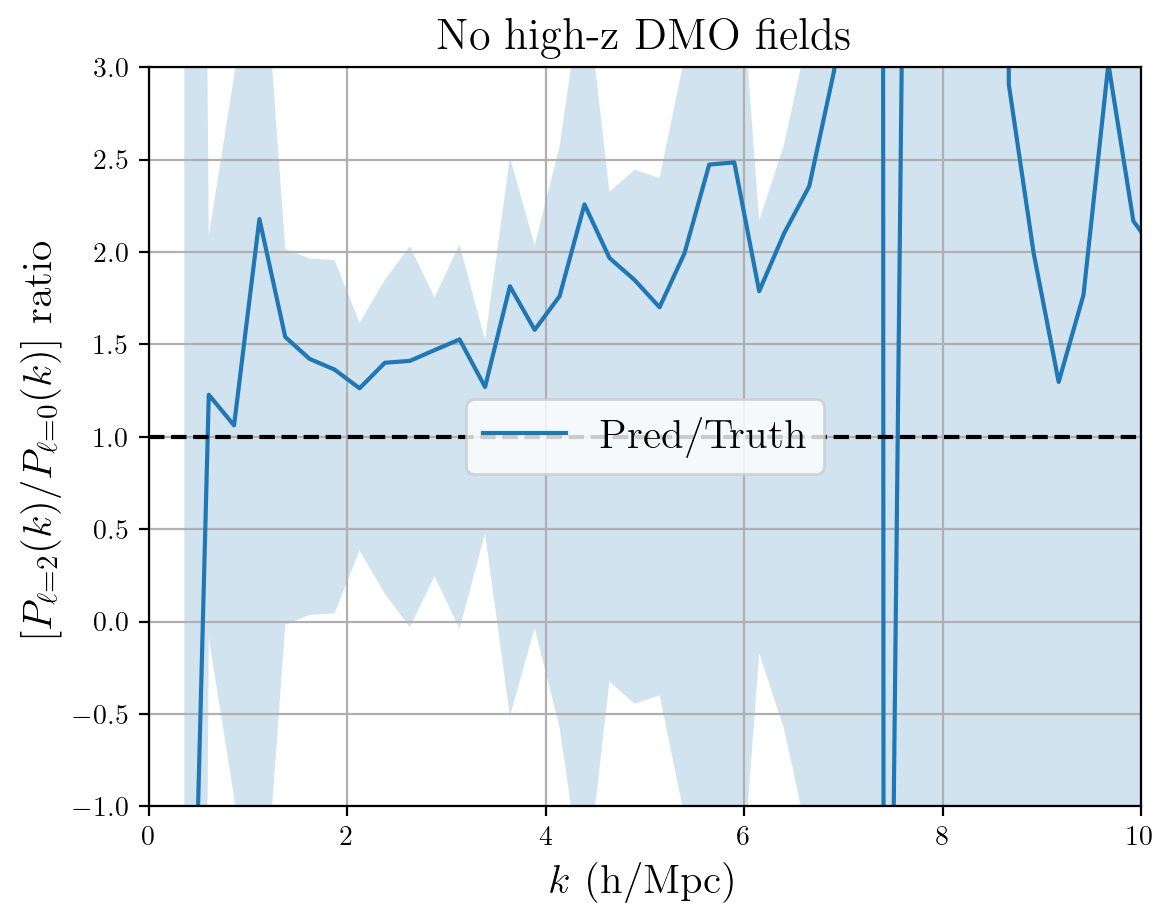

In [83]:
Pk_all_ratio_array = np.array(Pk_all_ratio)
Pk_all_ratio_mean = np.mean(Pk_all_ratio_array, axis=0)
Pk_all_ratio_std = np.std(Pk_all_ratio_array, axis=0)

pl.figure()
pl.plot(Pk_truth.k3D, Pk_all_ratio_mean, label='Pred/Truth')
pl.fill_between(Pk_truth.k3D, 1-Pk_all_ratio_std, 1+Pk_all_ratio_std, alpha=0.2)
pl.axhline(1, ls='--', color='k')
pl.xlabel(r'$k$ (h/Mpc)', fontsize=15)
pl.ylabel(r'$[P_{\ell = 2}(k)/P_{\ell = 0}(k)]$ ratio', fontsize=15)
pl.ylim(-1.0, 3.0)
pl.xlim(0, 10)
pl.grid()
pl.legend(fontsize=15)
pl.title('No high-z DMO fields', size=16)





Text(0.5, 1.0, 'No high-z DMO fields')

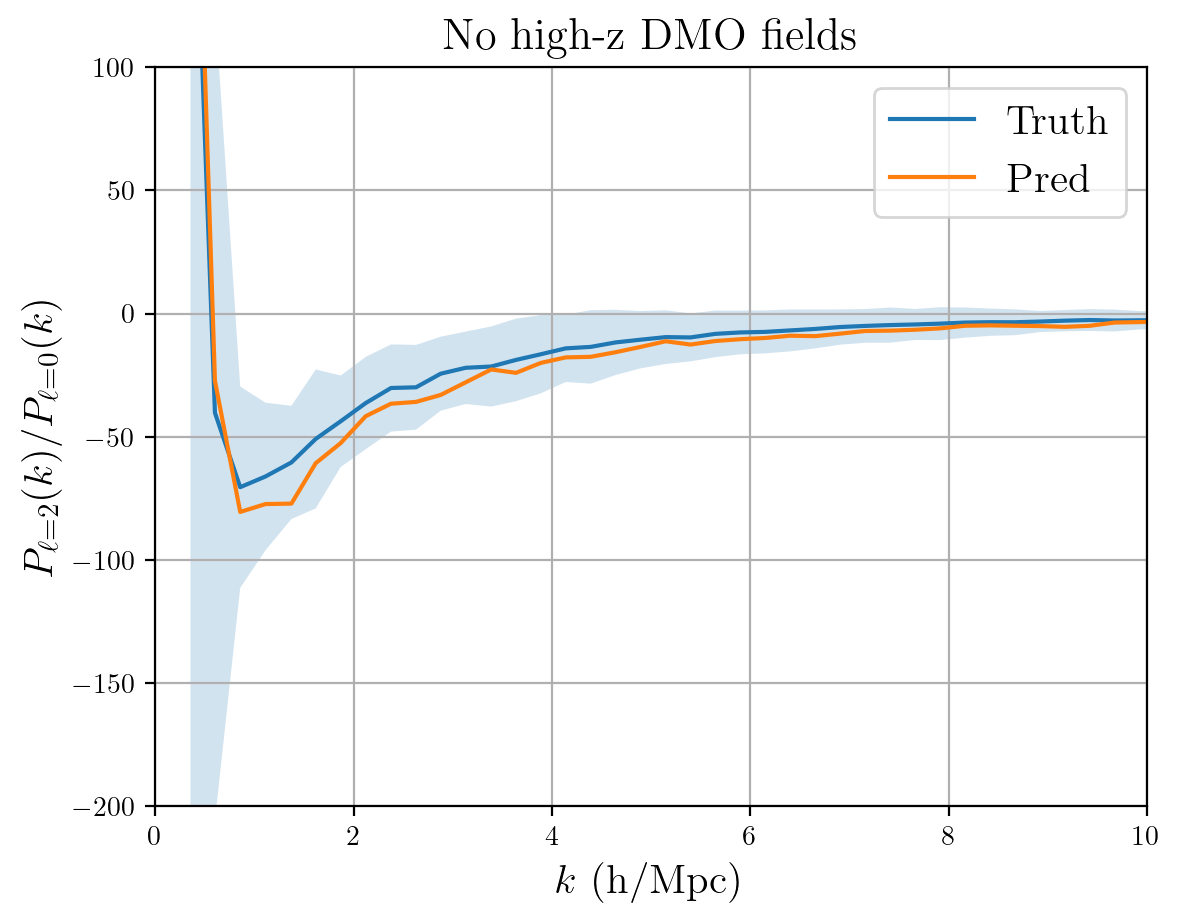

In [87]:
Pk_all_truth_array = np.array(Pk_all_truth)
Pk_all_mock_array = np.array(Pk_all_mock)
Pk_all_truth_mean = np.mean(Pk_all_truth_array, axis=0)
Pk_all_mock_mean = np.mean(Pk_all_mock_array, axis=0)
Pk_all_truth_std = np.std(Pk_all_truth_array, axis=0)

pl.figure()
pl.plot(Pk_truth.k3D, Pk_all_truth_mean, label='Truth')
pl.fill_between(Pk_truth.k3D, Pk_all_truth_mean-Pk_all_truth_std, Pk_all_truth_mean+Pk_all_truth_std, alpha=0.2)
pl.plot(Pk_truth.k3D, Pk_all_mock_mean, label='Pred')
pl.xlabel(r'$k$ (h/Mpc)', fontsize=15)
pl.ylabel(r'$P_{\ell = 2}(k)/P_{\ell = 0}(k)$', fontsize=15)
pl.xlim(0, 10)
pl.ylim(-200,100)
pl.legend(fontsize=15)
pl.grid()
pl.title('No high-z DMO fields', size=16)


/tmp/ipykernel_645719/836527052.py:4: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('retina')


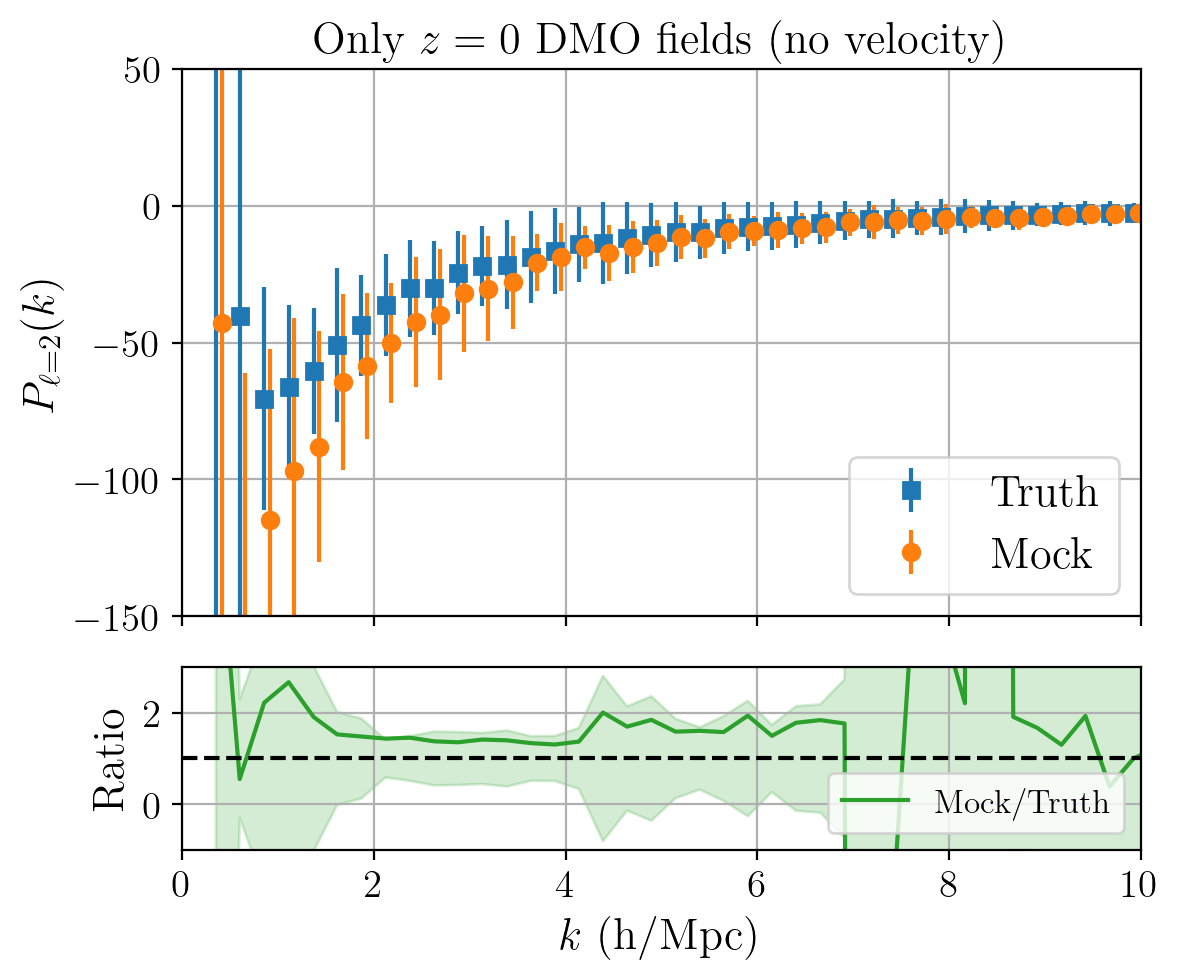

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina')

# Convert lists to numpy arrays
Pk_all_truth_array = np.array(Pk_all_truth)
Pk_all_mock_array = np.array(Pk_all_mock)
Pk_all_ratio_array = np.array(Pk_all_ratio)

# Compute mean and standard deviation
Pk_all_truth_mean = np.mean(Pk_all_truth_array, axis=0)
Pk_all_mock_mean = np.mean(Pk_all_mock_array, axis=0)
Pk_all_truth_std = np.std(Pk_all_truth_array, axis=0)
Pk_all_mock_std = np.std(Pk_all_mock_array, axis=0)

Pk_all_ratio_mean = np.mean(Pk_all_ratio_array, axis=0)
Pk_all_ratio_std = np.std(Pk_all_ratio_array, axis=0)

# Create figure with two panels
fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True, gridspec_kw={'height_ratios': [3, 1]}, figsize=(6, 5))

# Top panel: Comparison between truth and mock
ax1 = axes[0]
# ax1.plot(Pk_truth.k3D, Pk_all_truth_mean, label='Truth', color='C0')
# ax1.fill_between(Pk_truth.k3D, Pk_all_truth_mean - Pk_all_truth_std, 
#                  Pk_all_truth_mean + Pk_all_truth_std, color='C0', alpha=0.2)
# ax1.plot(Pk_truth.k3D, Pk_all_mock_mean, label='Mock', color='C1')

ax1.errorbar(Pk_truth.k3D, Pk_all_truth_mean,Pk_all_truth_std, label='Truth', ls='', marker='s', color='C0')
# ax1.fill_between(Pk_truth.k3D, Pk_all_truth_mean - Pk_all_truth_std, 
                 # Pk_all_truth_mean + Pk_all_truth_std, color='C0', alpha=0.2)
ax1.errorbar(Pk_truth.k3D+0.06, Pk_all_mock_mean, Pk_all_mock_std, label='Mock', ls='', marker='o', color='C1')

# ax1.set_ylabel(r'$P_{\ell = 2}(k)/P_{\ell = 0}(k)$', fontsize=16)
ax1.set_ylabel(r'$P_{\ell = 2}(k)$', fontsize=16)
ax1.set_xlim(0, 10)
ax1.legend(fontsize=16, loc='lower right')
# ax1.set_ylim(-1.5, 1.5)
ax1.set_ylim(-150, 50)
ax1.grid()
ax1.tick_params(axis='both', labelsize=14)
ax1.set_title(r'Only $z=0$ DMO fields (no velocity)', size=16)
# ax1.set_title(r'Only $z=0$ DMO fields', size=16)


# Bottom panel: Ratio plot
ax2 = axes[1]
ax2.plot(Pk_truth.k3D, Pk_all_ratio_mean, label='Mock/Truth', color='C2')
ax2.fill_between(Pk_truth.k3D, 1 - Pk_all_ratio_std, 1 + Pk_all_ratio_std, color='C2', alpha=0.2)
ax2.axhline(1, ls='--', color='k')  # Reference line at 1
ax2.set_xlabel(r'$k$ (h/Mpc)', fontsize=16)
ax2.set_ylabel('Ratio', fontsize=16)
# ax2.set_ylim(0.5, 1.5)  # Adjusting limits for better visibility
ax2.set_ylim(-1.0, 3.0)
ax2.set_xlim(0, 10)
ax2.grid()
ax2.legend(fontsize=12)
# Increase tick label size

ax2.tick_params(axis='both', labelsize=14)  # Slightly smaller for the ratio plot
# Adjust spacing
plt.tight_layout()
plt.savefig(f'/projects/bdne/spandey3/GOTHAM/run_scripts/camels/figs/P_ell2_comp_{subsel_type}.pdf')
plt.show()



In [93]:
# subsel_type


'all'

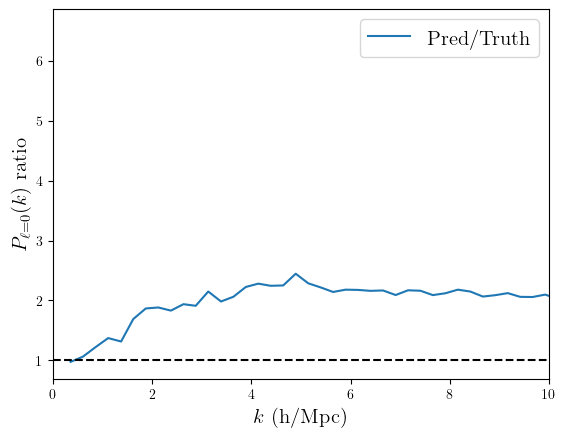

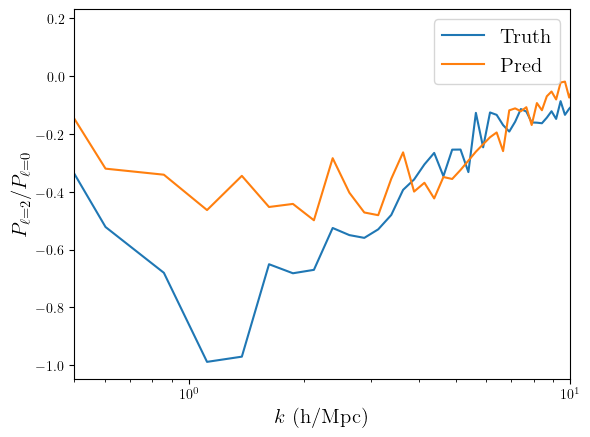

In [107]:

pl.figure()
pl.plot(Pk_truth.k3D, Pk_pred.Pk[:,0]/Pk_truth.Pk[:,0], label='Pred/Truth')
pl.axhline(1, ls='--', color='k')
pl.xlabel(r'$k$ (h/Mpc)', fontsize=15)
pl.ylabel(r'$P_{\ell = 0}(k)$ ratio', fontsize=15)
# pl.ylim(0.9, 1.1)
pl.xlim(0, 10)
# pl.yscale('log')
# pl.xscale('log')
pl.legend(fontsize=15)

pl.figure()
pl.plot(Pk_truth.k3D, Pk_truth.Pk[:,1]/Pk_truth.Pk[:,0], label='Truth')
pl.plot(Pk_truth.k3D, Pk_pred.Pk[:,1]/Pk_pred.Pk[:,0], label='Pred')
# pl.plot(Pk_pred.k3D, Pk_pred.Pk[:,0], label='Inferred')
pl.xlabel(r'$k$ (h/Mpc)', fontsize=15)
pl.ylabel(r'$P_{\ell = 2}/P_{\ell = 0}$', fontsize=15)
pl.xlim(0.5,10)
pl.xscale('log')
pl.legend(fontsize=15)




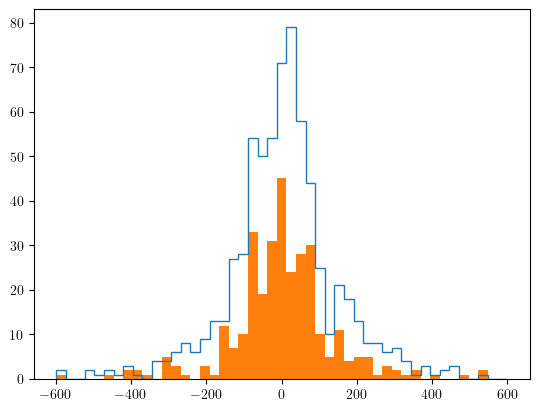

In [109]:
pl.figure()
_ = pl.hist(vel_truth, bins=47, range=(-600,600), histtype='step')
_ = pl.hist(vel_pred, bins=47, range=(-600,600))



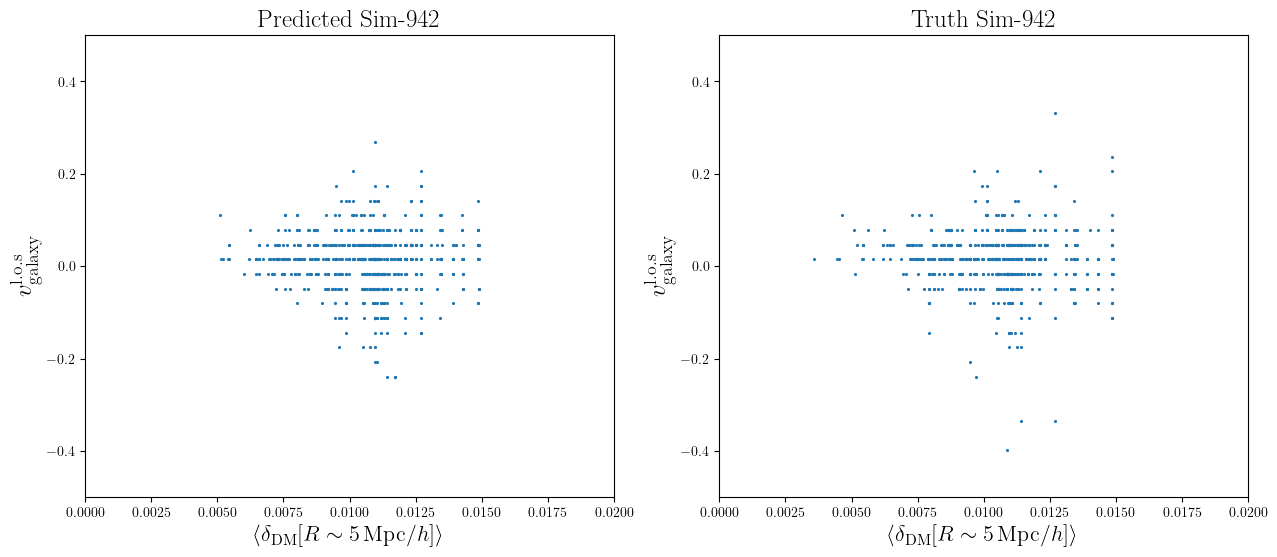

In [14]:
isim_fid = 942
pl.figure(figsize=(15, 6))

pl.subplot(1, 2, 1)
pl.scatter(saved_all[isim_fid]['dm_mean_truth_all'], saved_all[isim_fid]['prop_all_truth'][:,1], s=1.6)
pl.title('Predicted Sim-'+str(isim_fid), fontsize=18)
pl.xlabel(r'$\langle \delta_{\rm DM}[R \sim 5 \, {\rm Mpc}/h] \rangle$', fontsize=16)
pl.ylabel(r'$v^{\rm l.o.s}_{\rm galaxy}$', fontsize=18)
# pl.ylim(-0.75,0.75)
pl.ylim(-0.5,0.5)
pl.xlim(0.0, 0.02)
# pl.xtick

pl.subplot(1, 2, 2)
pl.scatter(saved_all[isim_fid]['dm_mean_all'], saved_all[isim_fid]['prop_all'][:,1], s=1.6)
pl.xlabel(r'$\langle \delta_{\rm DM}[R \sim 5 \, {\rm Mpc}/h] \rangle$', fontsize=16)
pl.ylabel(r'$v^{\rm l.o.s}_{\rm galaxy}$', fontsize=18)
pl.title('Truth Sim-'+str(isim_fid), fontsize=18)
# pl.ylim(-0.75,0.75)
pl.ylim(-0.5,0.5)
pl.xlim(0.0, 0.02)

pl.show()


In [15]:
# ids = 959
# pl.figure()
# # pl.scatter(saved_all[ids]['dm_mean_truth_all'], saved_all[ids]['prop_all_truth'][:,-1], s=1.0)
# pl.scatter(saved_all[ids]['dm_mean_truth_all'], saved_all[ids]['prop_all_truth'][:,-1], s=1.0)
# pl.ylim(-0.75,0.75)
# pl.xlim(0.0, 0.02)
# # pl.show()



In [16]:
# pl.figure()
# pl.scatter(saved_all[ids]['dm_mean_all'], saved_all[ids]['prop_all'][:,-1], s=1.0)
# # pl.ylim(0.025, 0.225)
# # pl.ylim(-1.2,1.2)
# # pl.ylim(-0.5,0.5)
# pl.ylim(-0.75,0.75)
# pl.xlim(0.0, 0.02)
# pl.show()



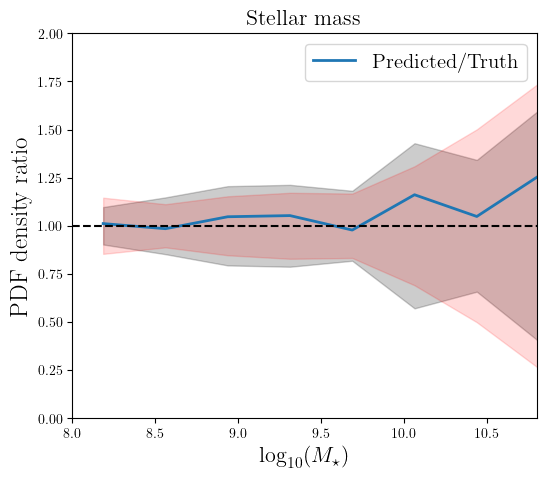

In [15]:
# snapnum = 90
# isim_fid = isim_fid_array[0]
# snap_dir_base = f'/work/hdd/bdne/spandey3/camels_tng/hydro/LH'
# snapdir = snap_dir_base + '/' + f'LH_{isim_fid}'  #folder hosting the catalogue
# group_catalog = f'{snapdir}/groups_090.hdf5'
# with h5.File(group_catalog, "r") as hf:
#     M_star = np.log10(hf['Subhalo/SubhaloMassType'][:,4]*1e10 + 0.1)
#     pos = hf['Subhalo/SubhaloPos'][:]/1000.

# Mstar_cut = 8
# indsel = np.where(M_star > Mstar_cut)[0]
# pos_h_truth = pos[indsel]
# prop_truth = M_star[indsel]
# prop_min = Mstar_cut
# prop_max = 11
hist_M_truth = []
hist_M_pred = []
hist_M_ratio = []
lgM_edges = np.linspace(8, 11, 9)
# lgM_edges = np.linspace(25, 30, 11)
lgM_cents = 0.5*(lgM_edges[1:] + lgM_edges[:-1])
for isim_fid in (isim_fid_array):
    # Mhalo_all_pred = saved_all[isim_fid]['prop_all'][:,-1]
    # Mhalo_all_truth = saved_all[isim_fid]['prop_all_truth'][:,-1]

    Mhalo_all_pred = saved_all[isim_fid]['prop_all'][:,0]
    Mhalo_all_truth = saved_all[isim_fid]['prop_all_truth'][:,0]    

    hist_pred = np.histogram(Mhalo_all_pred, bins=lgM_edges, density=True)[0]
    hist_truth = np.histogram(Mhalo_all_truth, bins=lgM_edges, density=True)[0]
    hist_ratio = hist_pred/hist_truth

    hist_M_truth.append(hist_truth)
    hist_M_pred.append(hist_pred)
    hist_M_ratio.append(hist_ratio)

hist_M_truth = np.array(hist_M_truth)
hist_M_pred = np.array(hist_M_pred)
hist_M_ratio = np.array(hist_M_ratio)

hist_M_truth_mean = np.mean(hist_M_truth, axis=0)
hist_M_truth_std = np.std(hist_M_truth, axis=0)

hist_M_pred_mean = np.mean(hist_M_pred, axis=0)
hist_M_pred_std = np.std(hist_M_pred, axis=0)

hist_M_ratio_mean = np.mean(hist_M_ratio, axis=0)
hist_M_ratio_std = np.std(hist_M_ratio, axis=0)

# hist_M_truth_ratiomean = hist_M_truth/np.mean(hist_M_truth, axis=0)[None,:]

pl.figure(figsize=(6, 5))
pl.plot(lgM_cents, hist_M_ratio_mean, label='Predicted/Truth', lw=2)
pl.fill_between(lgM_cents, 1 - hist_M_ratio_std, 1 + hist_M_ratio_std, alpha=0.2, color='k')
pl.fill_between(lgM_cents, 1 - hist_M_truth_std/hist_M_truth_mean, 1 + hist_M_truth_std/hist_M_truth_mean, alpha=0.15, color='r')

pl.axhline(1, color='k', ls='--')
pl.legend(fontsize=15)
# pl.xlim(26.8,29.4)
pl.xlim(8.0,10.8)
pl.ylim(0,2)
# pl.title('SDSS i-band photometry', fontsize=16)
pl.title('Stellar mass', fontsize=16)
# pl.xlabel(r'$\log_{10}(M_{i})$', fontsize=16)
pl.xlabel(r'$\log_{10}(M_{\star})$', fontsize=16)
pl.ylabel('PDF density ratio', fontsize=18)
pl.show()


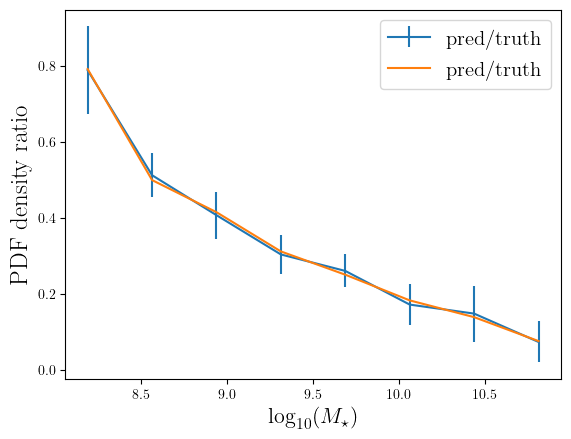

In [16]:
# np.array(Mhalo_all_concat).shape, np.array(Mhalo_all_truth_concat).shape
pl.figure()
pl.errorbar(lgM_cents, hist_M_truth_mean, hist_M_truth_std, label='pred/truth')
pl.errorbar(lgM_cents, hist_M_pred_mean, label='pred/truth')
# pl.fill_between(lgM_cents, 1 - hist_M_truth_std, 1 + hist_M_truth_std, alpha=0.3)
# pl.axhline(1, color='k', ls='--')
# pl.plot(lgM_cents, hist_M_pred_mean, label='pred')
# _ = pl.hist(np.array(Mhalo_all_concat), alpha=0.5, label='pred', range=(8, 12), bins=15, density=True)
# _ = pl.hist(np.array(Mhalo_all_truth_concat), alpha=0.5, label='truth', range=(8, 12), bins=15, density=True)
# _ = pl.hist(np.array(prop_truth), alpha=0.5, label='truth', range=(8, 12), bins=15, density=True)
# pl.yscale('log')
pl.legend(fontsize=15)
pl.xlabel(r'$\log_{10}(M_{\star})$', fontsize=16)
pl.ylabel('PDF density ratio', fontsize=18)
pl.show()



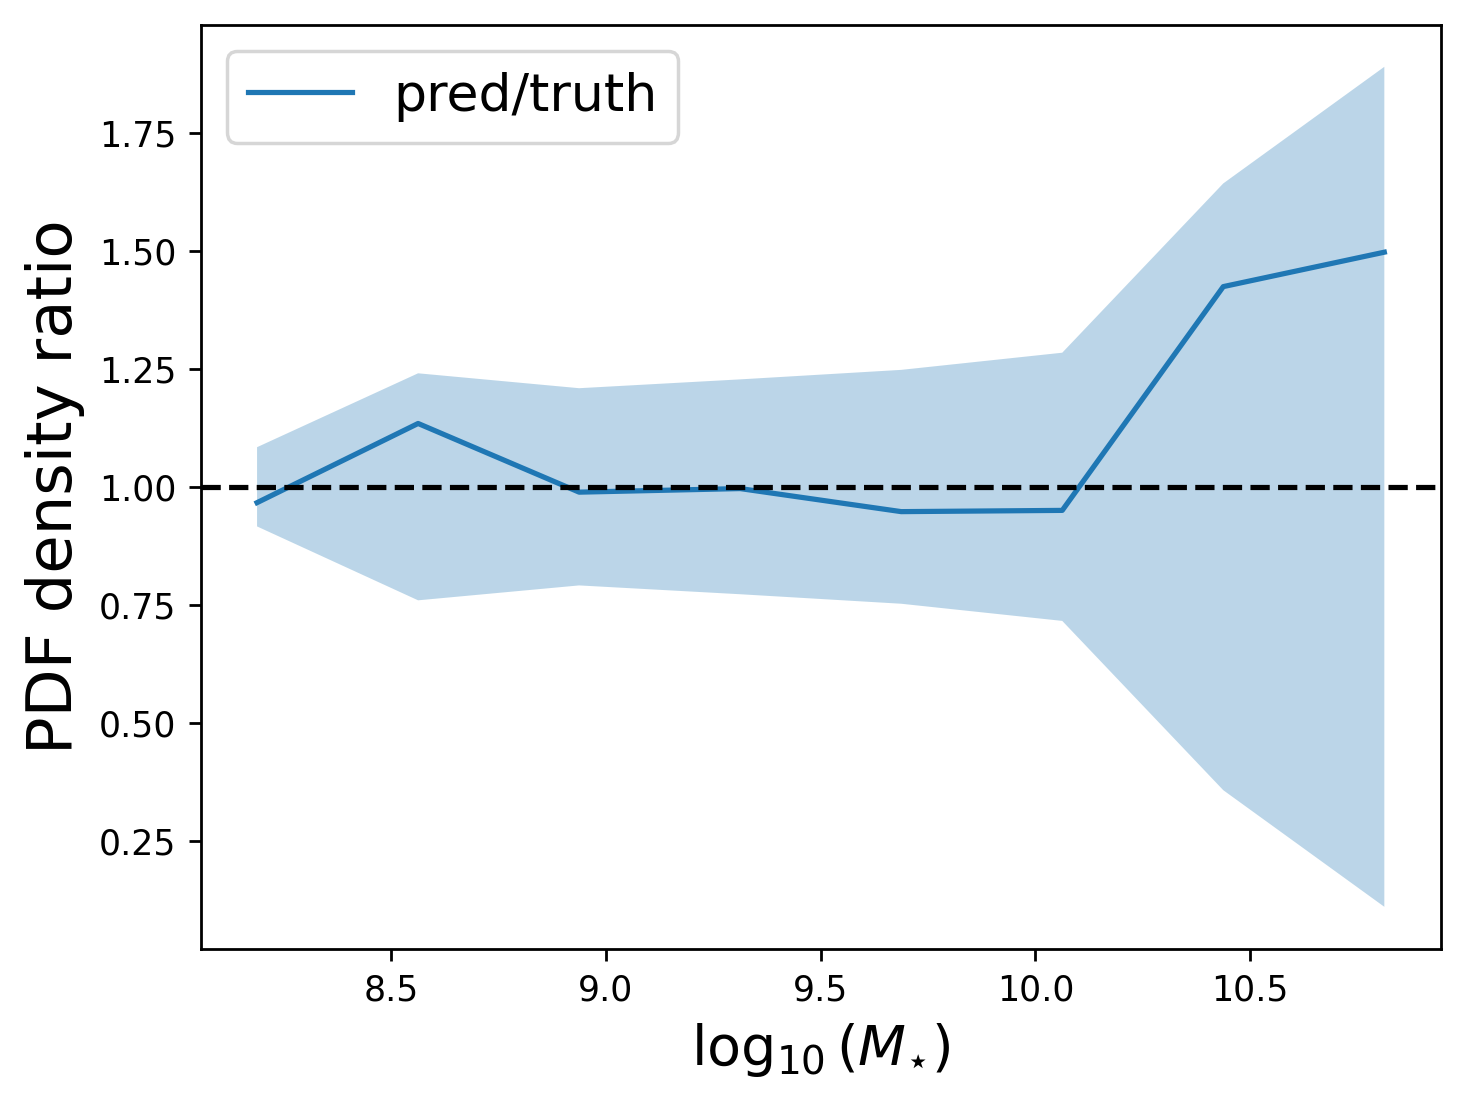

In [31]:
# np.array(Mhalo_all_concat).shape, np.array(Mhalo_all_truth_concat).shape
pl.figure()
pl.plot(lgM_cents, hist_M_ratio_mean, label='pred/truth')
pl.fill_between(lgM_cents, 1 - hist_M_truth_std, 1 + hist_M_truth_std, alpha=0.3)
pl.axhline(1, color='k', ls='--')
# pl.plot(lgM_cents, hist_M_pred_mean, label='pred')
# _ = pl.hist(np.array(Mhalo_all_concat), alpha=0.5, label='pred', range=(8, 12), bins=15, density=True)
# _ = pl.hist(np.array(Mhalo_all_truth_concat), alpha=0.5, label='truth', range=(8, 12), bins=15, density=True)
# _ = pl.hist(np.array(prop_truth), alpha=0.5, label='truth', range=(8, 12), bins=15, density=True)
# pl.yscale('log')
pl.legend(fontsize=15)
pl.xlabel(r'$\log_{10}(M_{\star})$', fontsize=16)
pl.ylabel('PDF density ratio', fontsize=18)
pl.show()



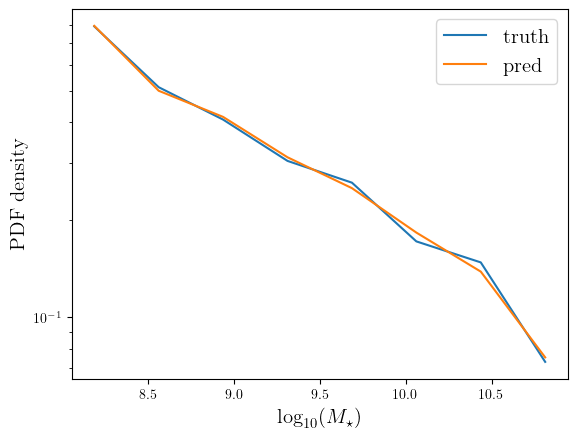

In [17]:
# np.array(Mhalo_all_concat).shape, np.array(Mhalo_all_truth_concat).shape
pl.figure()
pl.plot(lgM_cents, hist_M_truth_mean, label='truth')
pl.plot(lgM_cents, hist_M_pred_mean, label='pred')
# _ = pl.hist(np.array(Mhalo_all_concat), alpha=0.5, label='pred', range=(8, 12), bins=15, density=True)
# _ = pl.hist(np.array(Mhalo_all_truth_concat), alpha=0.5, label='truth', range=(8, 12), bins=15, density=True)
# _ = pl.hist(np.array(prop_truth), alpha=0.5, label='truth', range=(8, 12), bins=15, density=True)
pl.yscale('log')
pl.legend(fontsize=15)
pl.xlabel(r'$\log_{10}(M_{\star})$', fontsize=15)
pl.ylabel('PDF density', fontsize=15)
pl.show()



In [11]:
# pos_all_concat.shape
import matplotlib
%matplotlib inline


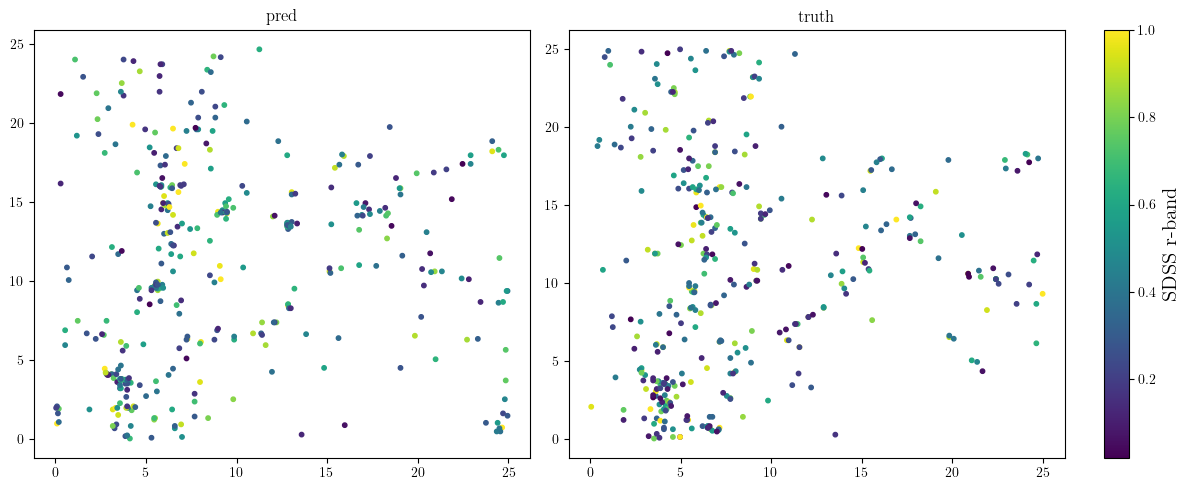

In [18]:
import matplotlib.gridspec as gridspec

isim_fid = 937
prop_min, prop_max = 26, 29

fig = pl.figure(figsize=(12, 5))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 0.05])  # Two equal subplots and a narrow colorbar

ax1 = pl.subplot(gs[0])
prop = np.clip((saved_all[isim_fid]['prop_all'][:,2] - prop_min) / (prop_max - prop_min), 0, 1)
ax1.scatter(saved_all[isim_fid]['pos_all'][:,0], saved_all[isim_fid]['pos_all'][:,1], c=prop, cmap='viridis', s=10)
ax1.set_title('pred')

ax2 = pl.subplot(gs[1])
prop = np.clip((saved_all[isim_fid]['prop_all_truth'][:,2] - prop_min) / (prop_max - prop_min), 0, 1)
sc = ax2.scatter(saved_all[isim_fid]['pos_all_truth'][:,0], saved_all[isim_fid]['pos_all_truth'][:,1], c=prop, cmap='viridis', s=10)
# ax2.set_xlabel('X Coordinate')
# ax2.set_ylabel('Y Coordinate')
ax2.set_title('truth')

cax = pl.subplot(gs[2])  # Colorbar axis
colorbar = pl.colorbar(sc, cax=cax)
colorbar.set_label('SDSS r-band', fontsize=15)

pl.tight_layout()
pl.show()


/tmp/ipykernel_1029328/1669695737.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


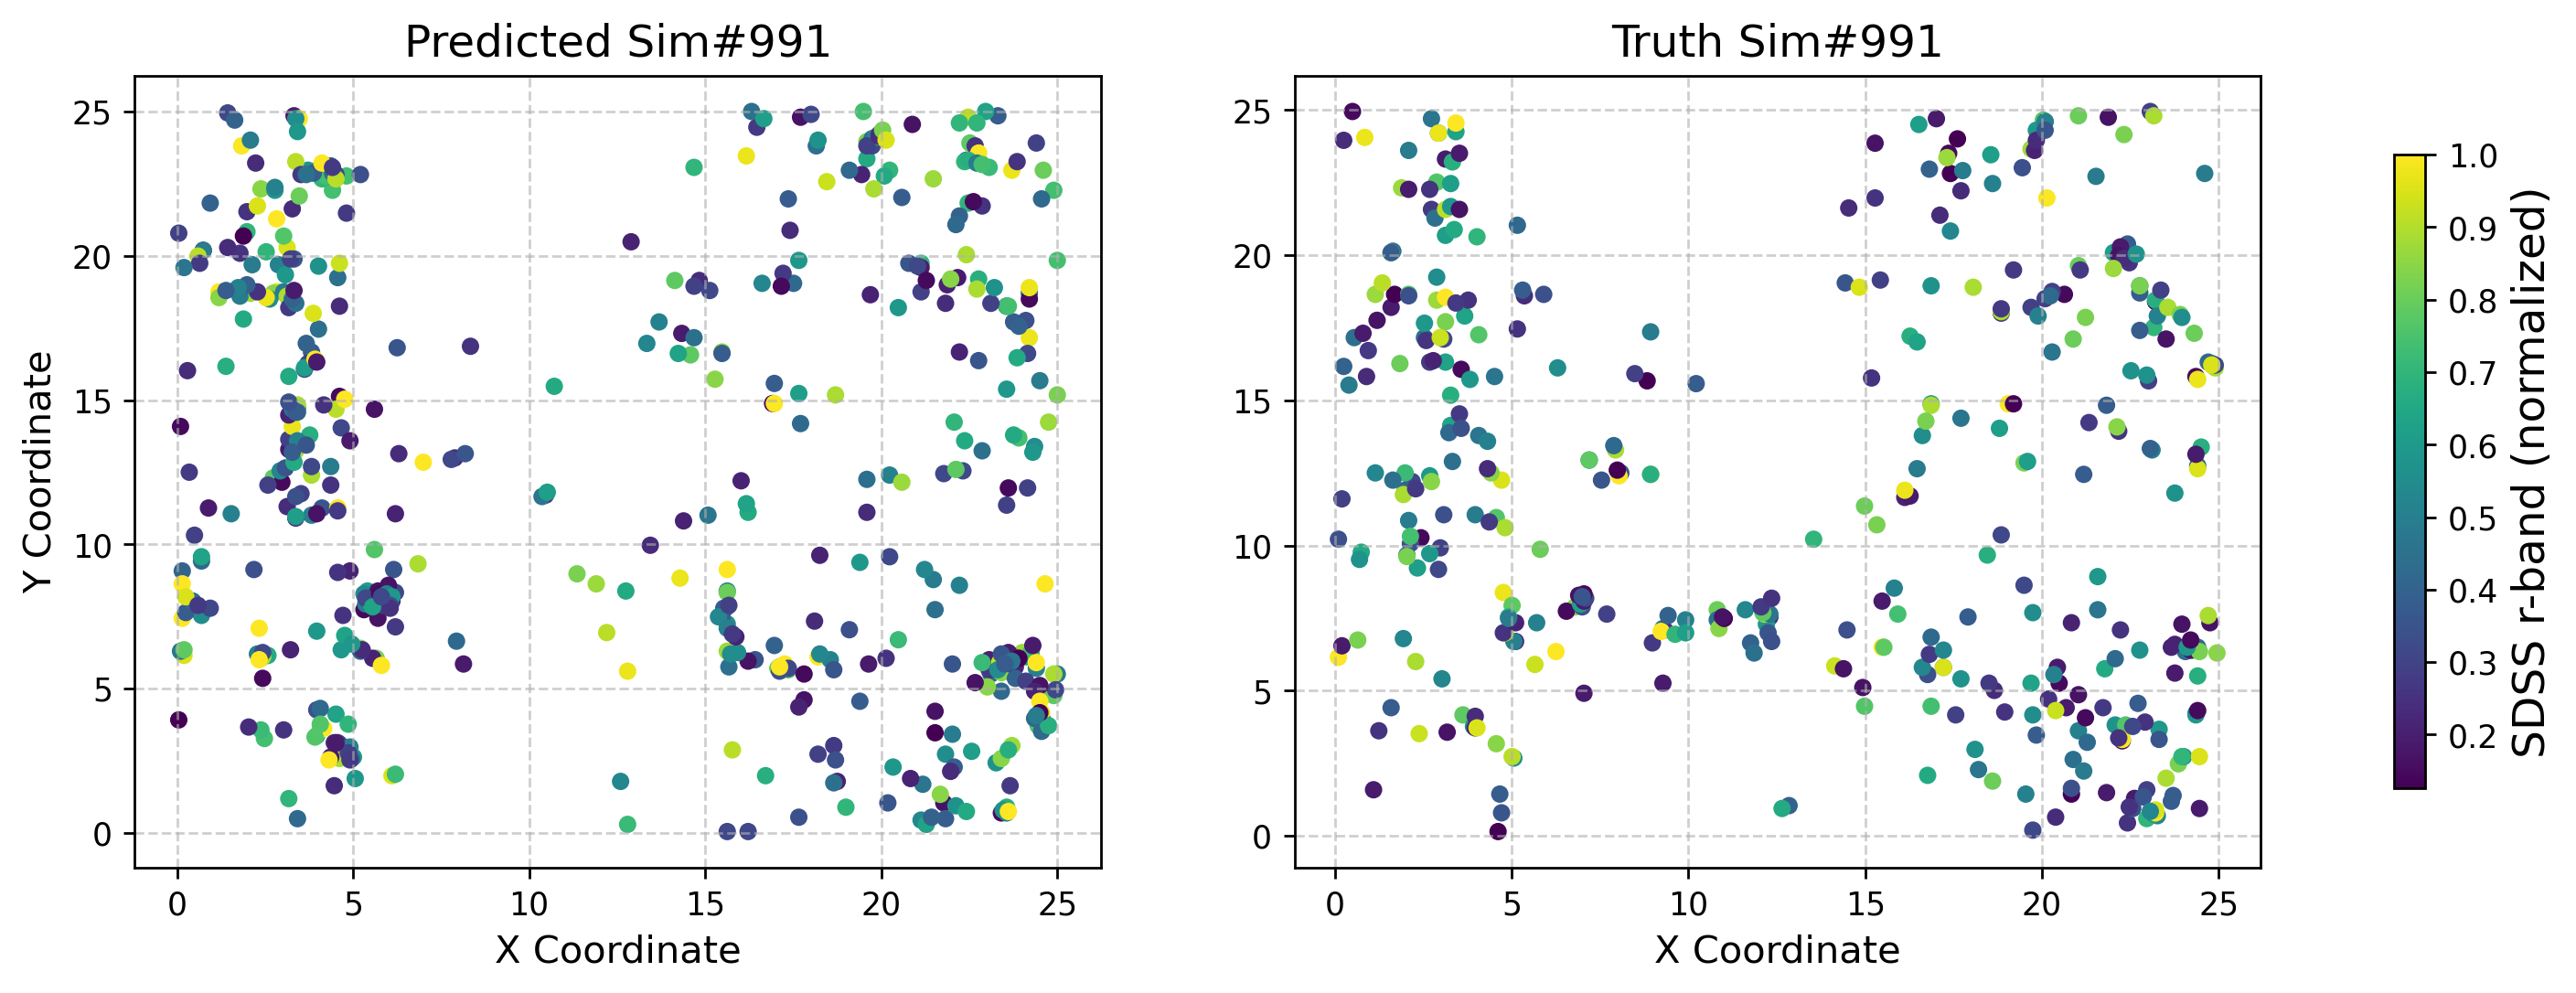

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
isim_fid = 991
prop_min = 26
prop_max = 29

# Example data for two panels
prop = np.clip((saved_all[isim_fid]['prop_all'][:,1] - prop_min)/(prop_max - prop_min), 0, 1)
x1, y1, property_values1 = saved_all[isim_fid]['pos_all'][:,0], saved_all[isim_fid]['pos_all'][:,1], prop

prop = np.clip((saved_all[isim_fid]['prop_all_truth'][:,1] - prop_min)/(prop_max - prop_min), 0, 1)
x2, y2, property_values2 = saved_all[isim_fid]['pos_all_truth'][:,0], saved_all[isim_fid]['pos_all_truth'][:,1], prop

# Combine property values for shared colorbar range
all_property_values = np.concatenate([property_values1, property_values2])

# Create a figure with two subplots
fig = plt.figure(figsize=(15, 4.5))
gs = GridSpec(1, 2, width_ratios=[1, 1], wspace=0.2)

# First subplot
ax1 = fig.add_subplot(gs[0, 0])
sc1 = ax1.scatter(x1, y1, c=property_values1, cmap='viridis', s=20)
ax1.set_title('Predicted Sim#991', fontsize=14)
ax1.set_xlabel('X Coordinate', fontsize=12)
ax1.set_ylabel('Y Coordinate', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)

# Second subplot
ax2 = fig.add_subplot(gs[0, 1])
sc2 = ax2.scatter(x2, y2, c=property_values2, cmap='viridis', s=20)
ax2.set_title('Truth Sim#991', fontsize=14)
ax2.set_xlabel('X Coordinate', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)

# Shared colorbar
cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=min(all_property_values), vmax=max(all_property_values))),
    ax=[ax1, ax2],
    orientation='vertical',
    shrink=0.8,
)
cbar.set_label('SDSS r-band (normalized)', fontsize=14)

# Show the plot
plt.tight_layout()
plt.show()



/tmp/ipykernel_1029328/2529282994.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


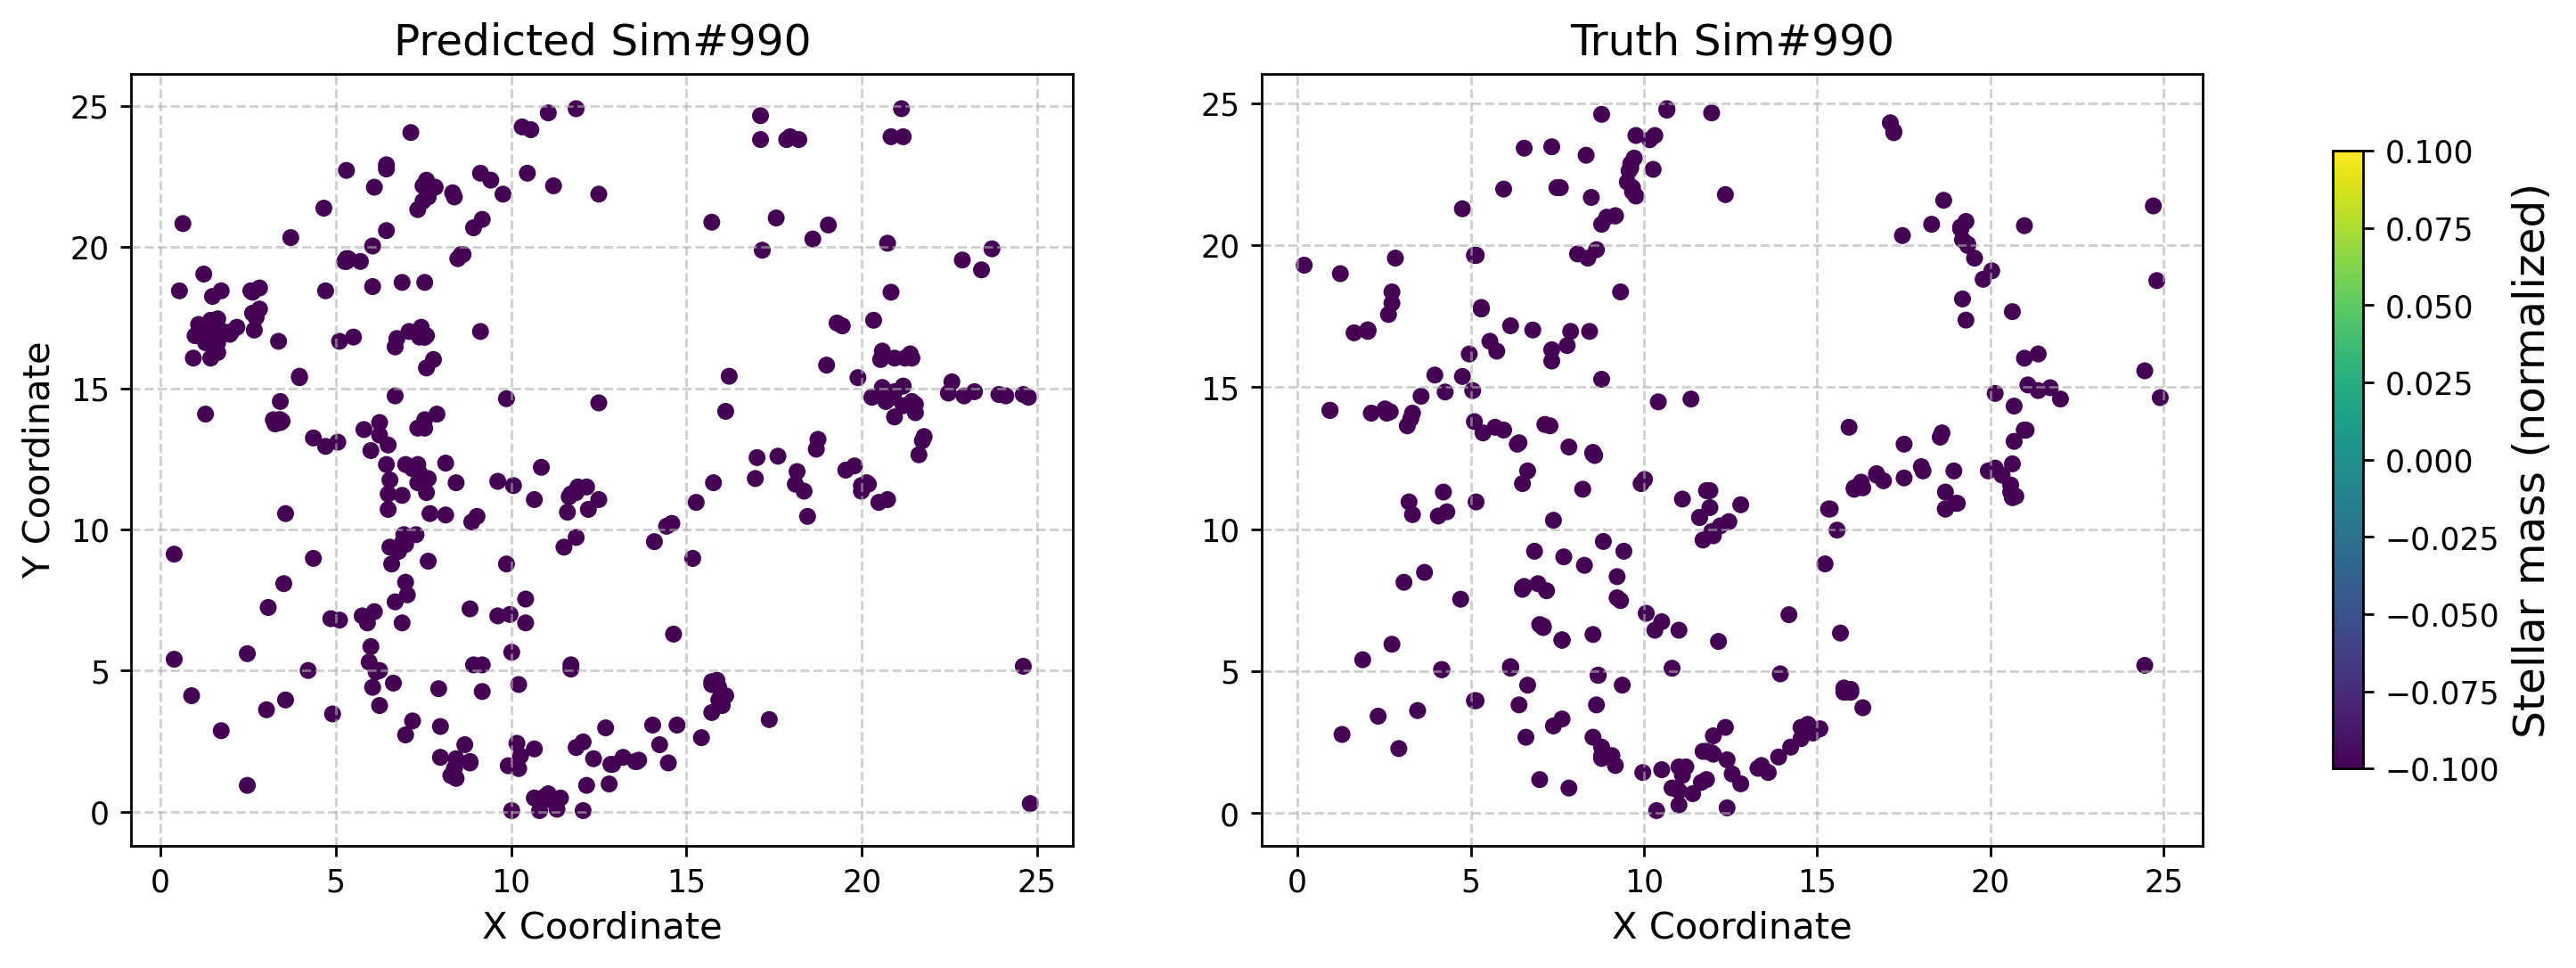

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
isim_fid = 990
prop_min = 7
prop_max = 10

# Example data for two panels
prop = np.clip((saved_all[isim_fid]['prop_all'][:,-1] - prop_min)/(prop_max - prop_min), 0, 1)
x1, y1, property_values1 = saved_all[isim_fid]['pos_all'][:,0], saved_all[isim_fid]['pos_all'][:,1], prop

prop = np.clip((saved_all[isim_fid]['prop_all_truth'][:,-1] - prop_min)/(prop_max - prop_min), 0, 1)
x2, y2, property_values2 = saved_all[isim_fid]['pos_all_truth'][:,0], saved_all[isim_fid]['pos_all_truth'][:,1], prop

# Combine property values for shared colorbar range
all_property_values = np.concatenate([property_values1, property_values2])

# Create a figure with two subplots
fig = plt.figure(figsize=(15, 4.5))
gs = GridSpec(1, 2, width_ratios=[1, 1], wspace=0.2)

# First subplot
ax1 = fig.add_subplot(gs[0, 0])
sc1 = ax1.scatter(x1, y1, c=property_values1, cmap='viridis', s=20)
ax1.set_title('Predicted Sim#990', fontsize=14)
ax1.set_xlabel('X Coordinate', fontsize=12)
ax1.set_ylabel('Y Coordinate', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)

# Second subplot
ax2 = fig.add_subplot(gs[0, 1])
sc2 = ax2.scatter(x2, y2, c=property_values2, cmap='viridis', s=20)
ax2.set_title('Truth Sim#990', fontsize=14)
ax2.set_xlabel('X Coordinate', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)

# Shared colorbar
cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=min(all_property_values), vmax=max(all_property_values))),
    ax=[ax1, ax2],
    orientation='vertical',
    shrink=0.8,
)
cbar.set_label('Stellar mass (normalized)', fontsize=14)

# Show the plot
plt.tight_layout()
plt.show()



In [20]:
saved_all[isim_fid]['prop_all_truth'].shape


(852, 4)

In [133]:
# isim_fid = 997
Pk_pred_all = []
Pk_truth_all = []
Pk_ratio_all = []

# ind_prop = 2
# normw = 10**27

ind_prop = 0
normw = 10**8
params_all = np.loadtxt('/projects/bdne/spandey3/GOTHAM/prep_data/camels_tng_LH_params.txt', usecols=range(1, 7))
z = 0.0
BoxSize = 25

grid_Pk = 64
MAS = 'CIC'


for isim_fid in isim_fid_array:
    Om = params_all[isim_fid, 0]
    Hz = 100.0 * np.sqrt(Om * (1. + z)**3 + (1 - Om))
    rsd_factor = (1. + z) / Hz

    pos_truth = saved_all[isim_fid]['pos_all_truth']
    vel_truth = saved_all[isim_fid]['prop_all_truth'][:,1] * 1000.
    
    # pos_truth = (pos_truth + (vel_truth * rsd_factor)[:,None])%(BoxSize)
    # pos_truth[:,0] = (pos_truth[:,0] + (vel_truth * rsd_factor))%(BoxSize)
    mesh_truth = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
    # MASL.MA(pos_truth.astype(np.float32), mesh_truth, BoxSize, MAS)

    W = (10**saved_all[isim_fid]['prop_all_truth'][:,ind_prop].astype(np.float32))/normw
    MASL.MA(pos_truth.astype(np.float32), mesh_truth, BoxSize, MAS , W=W) 

    mesh_truth /= np.mean(mesh_truth, dtype=np.float64);  mesh_truth -= 1.0
    Pk_truth = PKL.Pk(mesh_truth, BoxSize, axis=0, MAS=None, threads=threads, verbose=False)
    # Pk_truth_all.append(Pk_truth.Pk[:,0])
    Pk_truth_all.append(Pk_truth.Pk)
    
    pos_pred = saved_all[isim_fid]['pos_all']
    vel_pred = saved_all[isim_fid]['prop_all'][:,1] * 1000.
    # pos_pred = (pos_pred + (vel_pred * rsd_factor)[:,None])%(BoxSize)
    # pos_pred[:,0] = (pos_pred[:,0] + (vel_pred * rsd_factor))%(BoxSize)
    mesh_pred = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
    # MASL.MA(pos_pred.astype(np.float32), mesh_pred, BoxSize, MAS)
    
    W = 10**saved_all[isim_fid]['prop_all'][:,ind_prop].astype(np.float32)/normw
    MASL.MA(pos_pred.astype(np.float32), mesh_pred, BoxSize, MAS, W=W)     

    mesh_pred /= np.mean(mesh_pred, dtype=np.float64);  mesh_pred -= 1.0
    Pk_pred = PKL.Pk(mesh_pred, BoxSize, axis=0, MAS=None, threads=threads, verbose=False)
    # Pk_pred_all.append(Pk_pred.Pk[:,0])
    Pk_pred_all.append(Pk_pred.Pk)    

    # Pk_ratio_all.append(Pk_pred.Pk[:,0]/Pk_truth.Pk[:,0])
    Pk_ratio_all.append(Pk_pred.Pk/Pk_truth.Pk)


In [134]:
# Pk_pred_all.shape
# vel_truth
# (vel_truth * rsd_factor)[:,None]


In [135]:
Pk_pred_all = np.array(Pk_pred_all)
Pk_truth_all = np.array(Pk_truth_all)
Pk_ratio_all = np.array(Pk_ratio_all)


Pk_pred_mean = np.mean(Pk_pred_all, axis=0)
Pk_truth_mean = np.mean(Pk_truth_all, axis=0)
Pk_pred_std = np.std(Pk_pred_all, axis=0)
Pk_truth_std = np.std(Pk_truth_all, axis=0)

Pk_ratio_mean = np.mean(Pk_ratio_all, axis=0)
Pk_ratio_std = np.std(Pk_ratio_all, axis=0)


Pk_pred_quad_mono = Pk_pred_all[...,1]/Pk_pred_all[...,0]
Pk_truth_quad_mono = Pk_truth_all[...,1]/Pk_truth_all[...,0]
Pk_pred_quad_mono_mean = np.mean(Pk_pred_quad_mono, axis=0)
Pk_truth_quad_mono_mean = np.mean(Pk_truth_quad_mono, axis=0)
Pk_pred_quad_mono_std = np.std(Pk_pred_quad_mono, axis=0)
Pk_truth_quad_mono_std = np.std(Pk_truth_quad_mono, axis=0)



In [136]:
Pk_truth_all.shape, Pk_truth_mean.shape
# np.std(Pk_truth_mean[None,...]/Pk_truth_all, axis=0)


((10, 55, 3), (55, 3))

In [137]:
Pk_ratio_mean.shape, Pk_ratio_std.shape


((55, 3), (55, 3))

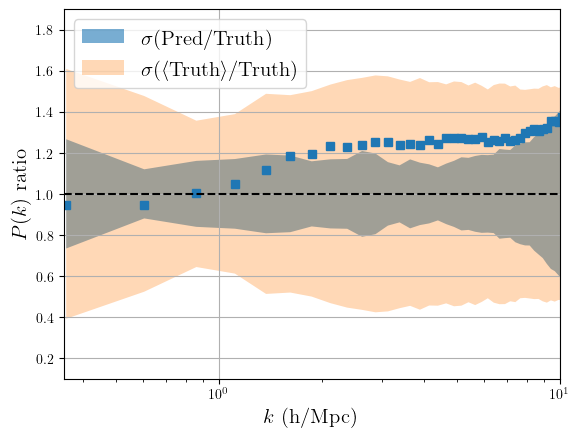

In [138]:
pl.figure()
pl.plot(Pk_truth.k3D, Pk_ratio_mean[:,0], ls='', marker='s')
pl.fill_between(Pk_truth.k3D, 1-Pk_ratio_std[:,0], 1+Pk_ratio_std[:,0], alpha=0.6, label=r'$\sigma({\rm Pred}/{\rm Truth})$')
# pl.fill_between(Pk_truth.k3D, 1-Pk_truth_std[:,0]/Pk_truth_mean[:,0], 1+Pk_truth_std[:,0]/Pk_truth_mean[:,0], alpha=0.1, label=r'$\sigma(Truth/\langle Truth \rangle)$')
pl.fill_between(Pk_truth.k3D, 1-(np.std(Pk_truth_mean[None,...]/Pk_truth_all, axis=0))[:,0], 1+(np.std(Pk_truth_mean[None,...]/Pk_truth_all, axis=0))[:,0], alpha=0.3, label=r'$\sigma(\langle {\rm Truth} \rangle/{\rm Truth})$')
# pl.errorbar(Pk_pred.k3D+0.035, Pk_pred_mean, yerr=Pk_pred_std, label='Predicted', ls='', marker='D')
# pl.errorbar(Pk_truth.k3D, Pk_truth_mean[:,0], yerr=Pk_truth_std[:,0], label='Truth', ls='', marker='s')
# pl.errorbar(Pk_pred.k3D+0.035, Pk_pred_mean[:,0], yerr=Pk_pred_std[:,0], label='Predicted', ls='', marker='D')
pl.axhline(1.0, ls='--', color='k')
# pl.yscale('log')
pl.xscale('log')
pl.xlabel(r'$k$ (h/Mpc)', fontsize=15)
pl.ylabel(r'$P(k)$ ratio', fontsize=15)
pl.ylim(0.1, 1.9)
pl.grid()
# pl.xlim(0.35, 6.5)
pl.xlim(0.35, 10.0)
# pl.text(0.3, 0.2, 'Weighted power spectra' + '\n' + r'$w = M_i/10^{27}$', transform=pl.gca().transAxes, fontsize=11, color='blue', ha='center', va='center')
# pl.text(0.3, 0.2, 'Weighted power spectra' + '\n' + r'$w = M_{\star}/10^{8}$', transform=pl.gca().transAxes, fontsize=11, color='blue', ha='center', va='center')
# pl.text(0.3, 0.2, 'Un-weighted power spectra', transform=pl.gca().transAxes, fontsize=11, color='blue', ha='center', va='center')
# pl.ylim(0.5,2e3)
pl.legend(fontsize=15)



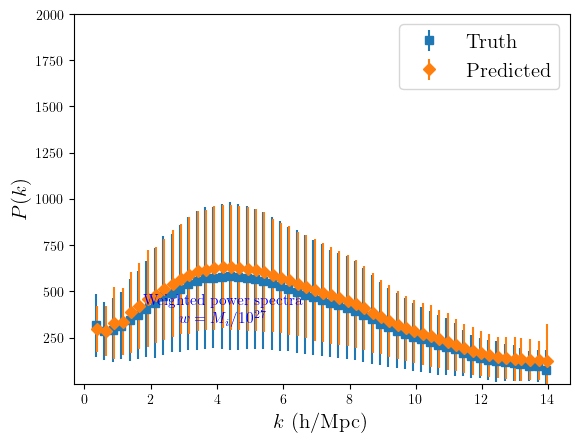

In [118]:
pl.figure()
# pl.errorbar(Pk_truth.k3D, Pk_truth_mean, yerr=Pk_truth_std, label='Truth', ls='', marker='s')
# pl.errorbar(Pk_pred.k3D+0.035, Pk_pred_mean, yerr=Pk_pred_std, label='Predicted', ls='', marker='D')
pl.errorbar(Pk_truth.k3D, Pk_truth.k3D*Pk_truth_mean[:,0], yerr=Pk_truth.k3D*Pk_truth_std[:,0], label='Truth', ls='', marker='s')
pl.errorbar(Pk_pred.k3D+0.035, Pk_pred.k3D*Pk_pred_mean[:,0], yerr=Pk_pred.k3D*Pk_pred_std[:,0], label='Predicted', ls='', marker='D')

# pl.yscale('log')
# pl.xscale('log')
pl.xlabel(r'$k$ (h/Mpc)', fontsize=15)
pl.ylabel(r'$P(k)$', fontsize=15)
pl.text(0.3, 0.2, 'Weighted power spectra' + '\n' + r'$w = M_i/10^{27}$', transform=pl.gca().transAxes, fontsize=11, color='blue', ha='center', va='center')
# pl.text(0.3, 0.2, 'Weighted power spectra' + '\n' + r'$w = M_{\star}/10^{8}$', transform=pl.gca().transAxes, fontsize=11, color='blue', ha='center', va='center')
# pl.text(0.3, 0.2, 'Un-weighted power spectra', transform=pl.gca().transAxes, fontsize=11, color='blue', ha='center', va='center')
pl.ylim(0.5,2e3)
pl.legend(fontsize=15)



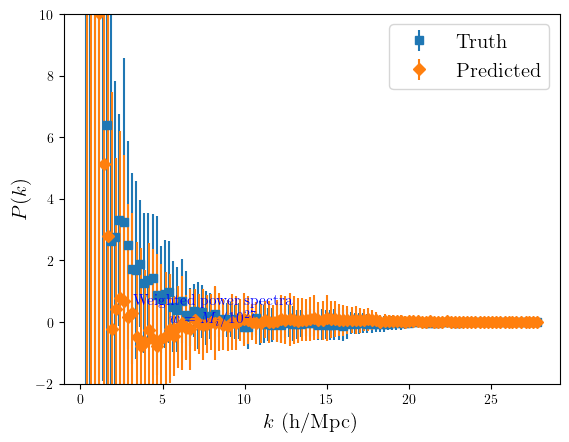

In [81]:
pl.figure()
# pl.errorbar(Pk_truth.k3D, Pk_truth_mean, yerr=Pk_truth_std, label='Truth', ls='', marker='s')
# pl.errorbar(Pk_pred.k3D+0.035, Pk_pred_mean, yerr=Pk_pred_std, label='Predicted', ls='', marker='D')
pl.errorbar(Pk_truth.k3D, Pk_truth_mean[:,1], yerr=Pk_truth_std[:,1], label='Truth', ls='', marker='s')
pl.errorbar(Pk_pred.k3D+0.035, Pk_pred_mean[:,1], yerr=Pk_pred_std[:,1], label='Predicted', ls='', marker='D')

# pl.yscale('log')
pl.xlabel(r'$k$ (h/Mpc)', fontsize=15)
pl.ylabel(r'$P(k)$', fontsize=15)
pl.text(0.3, 0.2, 'Weighted power spectra' + '\n' + r'$w = M_i/10^{27}$', transform=pl.gca().transAxes, fontsize=11, color='blue', ha='center', va='center')
# pl.text(0.3, 0.2, 'Weighted power spectra' + '\n' + r'$w = M_{\star}/10^{8}$', transform=pl.gca().transAxes, fontsize=11, color='blue', ha='center', va='center')
# pl.text(0.3, 0.2, 'Un-weighted power spectra', transform=pl.gca().transAxes, fontsize=11, color='blue', ha='center', va='center')
# pl.ylim(0.5,2e3)
pl.ylim(-2,10)
pl.legend(fontsize=15)



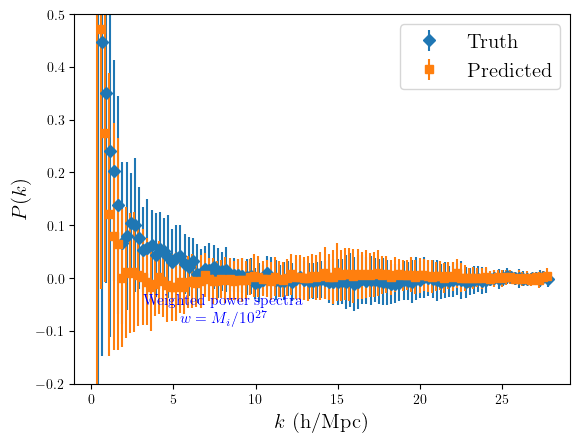

In [82]:
pl.figure()
# pl.errorbar(Pk_truth.k3D, Pk_truth_mean, yerr=Pk_truth_std, label='Truth', ls='', marker='s')
# pl.errorbar(Pk_pred.k3D+0.035, Pk_pred_mean, yerr=Pk_pred_std, label='Predicted', ls='', marker='D')
pl.errorbar(Pk_pred.k3D+0.035, Pk_truth_quad_mono_mean, yerr=Pk_truth_quad_mono_std, label='Truth', ls='', marker='D')
pl.errorbar(Pk_truth.k3D, Pk_pred_quad_mono_mean, yerr=Pk_pred_quad_mono_std, label='Predicted', ls='', marker='s')


# pl.yscale('log')
pl.xlabel(r'$k$ (h/Mpc)', fontsize=15)
pl.ylabel(r'$P(k)$', fontsize=15)
pl.text(0.3, 0.2, 'Weighted power spectra' + '\n' + r'$w = M_i/10^{27}$', transform=pl.gca().transAxes, fontsize=11, color='blue', ha='center', va='center')
# pl.text(0.3, 0.2, 'Weighted power spectra' + '\n' + r'$w = M_{\star}/10^{8}$', transform=pl.gca().transAxes, fontsize=11, color='blue', ha='center', va='center')
# pl.text(0.3, 0.2, 'Un-weighted power spectra', transform=pl.gca().transAxes, fontsize=11, color='blue', ha='center', va='center')
# pl.ylim(0.5,2e3)
pl.ylim(-0.2,0.5)
pl.legend(fontsize=15)



ValueError: too many values to unpack (expected 1)

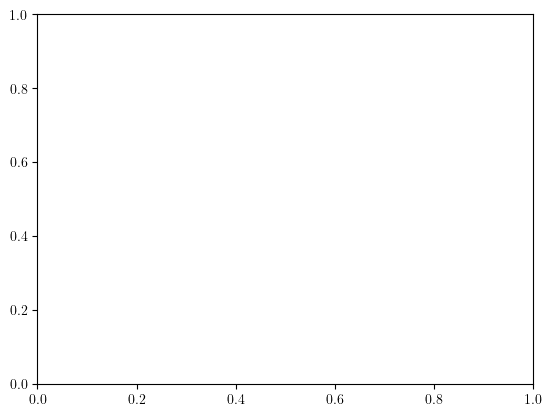

In [73]:
pl.figure()
pl.errorbar(Pk_truth.k3D, Pk_ratio_mean, label='pred/truth')
pl.fill_between(Pk_truth.k3D, 1 - Pk_ratio_std, 1+ Pk_ratio_std, alpha=0.5)
# pl.errorbar(Pk_pred.k3D*1.02, Pk_pred_mean, yerr=Pk_pred_std, label='pred')
pl.xscale('log')
# pl.yscale('log')
pl.axhline(1.0, ls='--', color='k')
pl.ylim(0.4, 1.4)
pl.xlabel(r'$k$', fontsize=15)
pl.ylabel(r'$P(k)$ ratio', fontsize=15)
pl.legend(fontsize=15)



Text(0, 0.5, '$P(k)$')

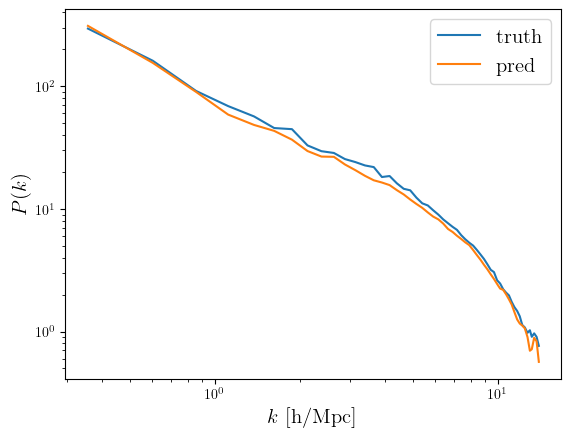

In [74]:
pl.figure()
pl.plot(Pk_truth.k3D, Pk_truth.Pk[:,0], label='truth')
pl.plot(Pk_pred.k3D, Pk_pred.Pk[:,0], label='pred')
pl.xscale('log')
pl.yscale('log')
pl.legend(fontsize=15)
pl.xlabel(r'$k$ [h/Mpc]', fontsize=15)
pl.ylabel(r'$P(k)$', fontsize=15)




In [76]:
# isim_fid_array = np.arange(7, 11)
# isim_fid_array = np.arange(0, 3)
# isim_fid = 6
# for isim_fid in isim_fid_array:
isim_fid = 3
df = pk.load(open(f'/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyzM_tokenized_PM_384x384x384_density3Dgrid_32_isim_{isim_fid}_snap_3_nvocab64_Mmin_1e13p5.pkl','rb'))

dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_0 = df['dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed']
dfhalo_ngp_wxyzM_0 = df['dfhalo_ngp_wxyzM']
Nhalos_truth_0 = df['Nhalos_truth']
delta_box_all_squeezed_0 = df['delta_box_all_squeezed']


grid = 32
shift_x_all, shift_y_all, shift_z_all = np.zeros((grid, grid, grid)), np.zeros((grid, grid, grid)), np.zeros((grid, grid, grid))
for jx in range(grid):
    for jy in range(grid):
        for jz in range(grid):
            shift_x_all[jx, jy, jz] = jx
            shift_y_all[jx, jy, jz] = jy
            shift_z_all[jx, jy, jz] = jz

shift_x_all_squeezed, shift_y_all_squeezed, shift_z_all_squeezed = shift_x_all.flatten(), shift_y_all.flatten(), shift_z_all.flatten()
shift_all_squeezed = np.vstack([shift_x_all_squeezed, shift_y_all_squeezed, shift_z_all_squeezed]).T


n1 = 32**3
test_data_halos = dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_0[:n1]

test_data_dm = delta_box_all_squeezed_0[:n1]

x = torch.tensor(test_data_halos[:, :-1])
y = torch.tensor(test_data_halos[:, 1:])
dm = torch.tensor(test_data_dm)
mask_test_orig = x != 1
mask_test = torch.logical_not(mask_test_orig)
masked_logits = torch.zeros(mask_test.shape)
mask_test_final = masked_logits.masked_fill(mask_test, float('-inf'))
mask_test = mask_test_final[:,None,:]
x, y = torch.tensor(x), torch.tensor(y)
x_test = x.long()
y_test = y.long()
dm_test = dm.bfloat16()
mask_test = torch.tensor(mask_test).bfloat16()

x_test_gpu = x_test.to(dev)
y_test_gpu = y_test.to(dev)
dm_test_gpu = dm_test.to(dev)
mask_test_gpu = mask_test.to(dev)


def get_batch(split, ji=0, batch_size=None):
    if split == 'train':
        x = x_train_gpu
        y = y_train_gpu
        mask = mask_train_gpu
        dm = dm_train_gpu

    elif split == 'val':
        x = x_val_gpu
        y = y_val_gpu
        mask = mask_val_gpu
        dm = dm_val_gpu

    elif split == 'test':
        x = x_test_gpu
        y = y_test_gpu
        mask = mask_test_gpu
        dm = dm_test_gpu        

    if batch_size is not None:
        x = x[batch_size*(ji):batch_size*(ji+1)].to(dev, non_blocking=True)
        y = y[batch_size*(ji):batch_size*(ji+1)].to(dev, non_blocking=True)
        mask = mask[batch_size*(ji):batch_size*(ji+1)].to(dev, non_blocking=True)
        dm = dm[batch_size*(ji):batch_size*(ji+1)].to(dev, non_blocking=True)

    return x, y, mask, dm

batch_size = 32**3
X_val, Y_val, MASK_val, DM_val = get_batch('test', 0, batch_size)
DM_val = torch.moveaxis(DM_val, -1, 1)
# DM_val.shape

DM_val_tosplit = DM_val.detach().cpu().to(torch.float16).numpy()[:batch_size, 0,:,:,:].reshape(batch_size, DM_val.shape[-1]**3)
DM_val_tosplit_mean = np.mean(DM_val_tosplit, axis=-1)

vlow = 0.00075
vmid = 0.0017

indlow = np.where(DM_val_tosplit_mean < vlow)[0]
indmid = np.where((DM_val_tosplit_mean >= vlow) & (DM_val_tosplit_mean < vmid))[0]
indhigh = np.where(DM_val_tosplit_mean >= vmid)[0]

print(len(indlow), len(indmid), len(indhigh))

max_new_tokens = df['max_sentence_length']
nvocab = df['nvocab_total'] - 3

bins_digitize = np.linspace(-1e-3, 1, nvocab)
# bins_digitize.insert(0, -1)
bins_digitize = np.insert(bins_digitize, 0, -1)


start_token = 0
pad_token = 1
end_token = nvocab + 1
space_token = nvocab + 2


from tqdm import tqdm

# end_token = 65
# nvox_samp = 32**3
# nbatches = 32
fac = 32
nvox_samp = fac*32**2
nbatches = fac
nvox_per_batch = nvox_samp // nbatches

# idx_all = []
# idx_all = torch.ones((nvox_samp, max_new_tokens), dtype=torch.long, device=dev)
idx_all = np.ones((nvox_samp, max_new_tokens))
for jb in tqdm(range(nbatches)):

    idx_inp = torch.zeros((nvox_per_batch, 1), dtype=torch.long, device=dev)

    DM_val_jb = DM_val[jb*nvox_per_batch:(jb+1)*nvox_per_batch,...]

    new_samples_jb = np.ones((nvox_per_batch, max_new_tokens))

    ind_jb = np.arange(nvox_per_batch)

    new_samples_jb[:, 0] = idx_inp[:,0].cpu().detach().numpy()
    # idx = idx_inp
    for jt in range(1, max_new_tokens):
        if len(ind_jb) > 0:
            # crop idx to the last block_size tokens
            idx_cond = torch.tensor(new_samples_jb[ind_jb, :jt], dtype=torch.long, device=dev)
            # get the predictions
            logits, loss = model(idx_cond, DM_val_jb[ind_jb,...])
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1).cpu().detach().numpy() # (B, 1)

            # append sampled index to the running sequence
            # if idx_next == end_token:
                # break
            new_samples_jb[ind_jb, jt] = idx_next[:,0]
            ind_to_del = np.where(idx_next[:,0] == end_token)[0]
            # for jv in range(len(ind_jb)):
                # if idx_next[jv, 0] == end_token:
            if len(ind_to_del) > 0:
                ind_jb = np.delete(ind_jb, ind_to_del)


        # print(new_samples_jb[0,:])
        # idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
    idx_all[jb*nvox_per_batch:(jb+1)*nvox_per_batch, :] = new_samples_jb
    # idx_all.append(idx)



FileNotFoundError: [Errno 2] No such file or directory: '/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyzM_tokenized_PM_384x384x384_density3Dgrid_32_isim_3_snap_3_nvocab64_Mmin_1e13p5.pkl'

In [14]:
# jv = 465
jv = indhigh[0]
id_start = 0
id_space = idx_all[jv][::5][1:]
M_jv = idx_all[jv, 1:][::5]
id_space, M_jv


(array([66., 66., 66., 66., 66., 66., 66., 66., 66., 66., 65.,  1.,  1.,
         1.,  1.,  1.,  1.,  1.,  1.,  1.]),
 array([33., 31., 27., 15., 11., 11.,  9.,  9.,  8.,  5.,  3.,  1.,  1.,
         1.,  1.,  1.,  1.,  1.,  1.,  1.]))

In [15]:
# idx_all[jv]
np.diff(M_jv)


array([ -2.,  -4., -12.,  -4.,   0.,  -2.,   0.,  -1.,  -3.,  -2.,  -2.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.])

In [22]:
from tqdm import tqdm
id_space_wrong = []
id_non_desc = []
num_space_wrong = []
for jv in tqdm(range(nvox_samp)):
    idx_jv = idx_all[jv,:]
    id_space_jv = idx_all[jv][::5][1:]
    M_jv = idx_all[jv, 1:][::5]

    if np.any(np.isin(id_space_jv, np.array([space_token, end_token, pad_token])) != True):
        id_space_wrong.append(jv)
        num_space_wrong.append(np.sum(np.isin(id_space_jv, np.array([space_token, end_token, pad_token])) != True))
    
    if np.any(np.diff(M_jv) > 0):
        id_non_desc.append(jv)



100%|██████████| 32768/32768 [00:00<00:00, 43925.88it/s]


In [2]:
# id_space_jv
# id_space_jv  [space_token, end_token, pad_token]
# np.isin(id_space_jv, np.array([space_token, end_token, pad_token]))
# id_space_wrong, id_non_desc
# id_non_desc[0]
# idx_all[id_non_desc[10]]
# len(id_non_desc)
# len(id_space_wrong)
# idx_all[id_space_wrong[20]]
import h5py as h5
f = h5.File('/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyzM_tokenized_PM_384x384x384_density3Dgrid_32_isim_012_snap_3_nvocab64_Mmin_13p5.h5', 'r')
dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all = f['dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all'][:]
delta_box_all_squeezed_all = f['delta_box_all_squeezed_all'][:]
nvocab_total = f['nvocab_total'][()]
grid_size = f['grid'][()]
start_token = f['start_token'][()]
pad_token = f['pad_token'][()]
end_token = f['end_token'][()]
max_sentence_length = f['max_sentence_length'][()]
f.close()


In [3]:
max_sentence_length



101

In [29]:
isim_fid_array = np.arange(0, 10)
M_all = []
snapnum = 3
mass_type = 'rockstar_200c'
snap_dir_base = '/mnt/home/fvillaescusa/ceph/Quijote/Halos/Rockstar/fiducial_HR'

for isim_fid in isim_fid_array:
    snapdir = snap_dir_base + '/' + str(isim_fid)  #folder hosting the catalogue
    rockstar = np.loadtxt(snapdir + '/out_' + str(snapnum) + '_pid.list')
    with open(snapdir + '/out_' + str(snapnum) + '_pid.list', 'r') as f:
        lines = f.readlines()
    header = lines[0].split()

    index_M = header.index('M200c')                    
    mass_truth = rockstar[:,index_M]  #Halo masses in Msun/h
    M_all.append(mass_truth)




In [30]:
logM_all = np.log10(np.concatenate(M_all))



/tmp/ipykernel_1104866/26522825.py:1: RuntimeWarning: divide by zero encountered in log10
  logM_all = np.log10(np.concatenate(M_all))


In [35]:
from colossus.cosmology import cosmology
params = {'flat': True, 'H0': 67.11, 'Om0': 0.3175, 'Ob0': 0.049, 'sigma8': 0.834, 'ns': 0.9624}
cosmo = cosmology.setCosmology('myCosmo', **params)
# get halo mass function:
from colossus.lss import mass_function
lgMmin = 12.5
lgMmax = 15.5
lgM_array = np.linspace(lgMmin, lgMmax, 1000)
M_array = 10**lgM_array
z_inference = 0.5
# if '200c' in mass_type:
dndlnM = mass_function.massFunction(M_array, float(z_inference), mdef = '200c', model = 'tinker08', q_out = 'dndlnM')

dlnM = np.log(M_array[1]/M_array[0])
dndM = dndlnM * M_array
dn = dndM * dlnM
n = np.cumsum(dn)



In [33]:
len(n), len(M_array)


(1000, 1000)

Text(0, 0.5, 'Histogram')

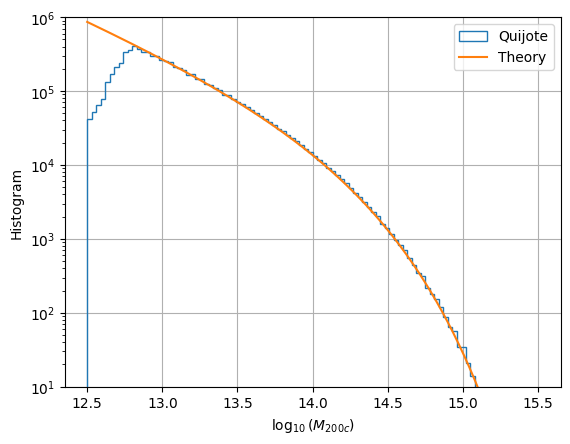

In [55]:
pl.figure()
_ = pl.hist(logM_all,bins=100, histtype='step', range=(12.5, 15.5), label='Quijote')
pl.plot(lgM_array, 0.6711*dndlnM * 1e9, label='Theory')
# pl.plot(lgM_array, n, label='Theory')
pl.yscale('log')
pl.ylim(10, 1e6)
pl.grid()
pl.legend()
pl.xlabel(r'$\log_{10}(M_{200c})$')
pl.ylabel(r'Histogram')


In [134]:
Mmin_cut = 10**13.5
lgMin = np.log10(Mmin_cut)
lgMax = 15.5

BoxSize = 1000.
grid = 32
xmin = BoxSize/grid/2

Nhalo_all_truth = []
Mhalo_all_truth = []
pos_all_truth = []
Pk_all_truth = []

MAS     = 'NGP'  #mass-assigment scheme
grid_Pk = 16
threads = 10

for jv in range(nvox_samp):
# for jv in indhigh[:nvox_samp]:    
    idx = X_val[jv]
    idx = idx.cpu().numpy().flatten().astype(int)
    # idx = idx[1:]
    # idx = idx[:np.where(idx == end_token)[0][0]]
    # idx = idx.reshape(-1, 5)
    idxe = np.where(idx == space_token)[0] + 1
    idx0 = np.where(idx == start_token)[0] + 1
    # check with idx0 is a scalar or an array:
    # try:
        # temp = len(idx0)
        # print(temp)
    # except:
    if len(idx0) == 1:
        if idx[idx0] != end_token:
            Nhalo = len(idxe) + len(idx0)
            Nhalo_all_truth.append(Nhalo)
            pos_halo = np.zeros((Nhalo, 3))
            pos_halo_unshifted = np.zeros((Nhalo, 3))        
            if Nhalo > 0:
                try:
                    Mhalo = np.zeros(Nhalo)
                    for jh in range(Nhalo):
                        if jh == 0:
                            Mhalo[jh] = bins_digitize[idx[idx0]] * (lgMax - lgMin) + lgMin
                            for jx in range(3):
                                # if jx == 0:
                                shift_coord = shift_all_squeezed[jv, jx] * (2 * xmin)
                                pos_halo[jh, jx] = bins_digitize[idx[idx0 + jx + 1]] * 2 * xmin  + shift_coord        
                                pos_halo_unshifted[jh, jx] = pos_halo[jh, jx] - shift_coord

                        else:
                            if Nhalo > 2:
                                Mhalo[jh] = bins_digitize[idx[idxe[jh-1]]] * (lgMax - lgMin) + lgMin
                                for jx in range(3):
                                    shift_coord = shift_all_squeezed[jv, jx] * (2 * xmin)
                                    pos_halo[jh, jx] = bins_digitize[idx[idxe[jh-1] + jx + 1]] * 2 * xmin  + shift_coord
                                    pos_halo_unshifted[jh, jx] = pos_halo[jh, jx] - shift_coord

                            else:
                                Mhalo[jh] = bins_digitize[idx[idxe]] * (lgMax - lgMin) + lgMin
                                for jx in range(3):
                                    shift_coord = shift_all_squeezed[jv, jx] * (2 * xmin)
                                    pos_halo[jh, jx] = bins_digitize[idx[idxe + jx + 1]] * 2 * xmin  + shift_coord    
                                    pos_halo_unshifted[jh, jx] = pos_halo[jh, jx] - shift_coord

                    Mhalo_all_truth.append(Mhalo)
                    pos_all_truth.append(pos_halo)

                    if Nhalo > 5:
                        mesh_truth = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
                        MASL.MA(pos_halo_unshifted.astype(np.float32), mesh_truth, 2*xmin, MAS)
                        mesh_truth /= np.mean(mesh_truth, dtype=np.float64);  mesh_truth -= 1.0
                        Pk_truth = PKL.Pk(mesh_truth, 2*xmin, axis=0, MAS=None, threads=threads, verbose=False)
                        Pk_all_truth.append(Pk_truth.Pk[:,0])
                    else:
                        Pk_all_truth.append([])

                except:
                    Nhalo_all_truth.pop()
                    Nhalo_all_truth.append(0)
                    Mhalo_all_truth.append(np.array([]))
                    pos_all_truth.append(np.array([]))
                    Pk_all_truth.append([])
                    pass
        else:
            Nhalo_all_truth.append(0)            
            Mhalo_all_truth.append(np.array([]))
            pos_all_truth.append(np.array([]))
            Pk_all_truth.append([])
    else:
        Nhalo_all_truth.append(0)  
        Nhalo_all_truth.append(np.array([]))
        Mhalo_all_truth.append(np.array([]))
        pos_all_truth.append(np.array([]))
        Pk_all_truth.append([])

Nhalo_all = []
Mhalo_all = []
pos_all = []
Pk_all = []


for jv in range(nvox_samp):
# for jv in indhigh[:nvox_samp]:    
    idx = idx_all[jv].astype(int)
    idx = idx.flatten()
    # idx = idx[1:]
    # idx = idx[:np.where(idx == end_token)[0][0]]
    # idx = idx.reshape(-1, 5)
    idxe = np.where(idx == space_token)[0] + 1
    idx0 = np.where(idx == start_token)[0] + 1
    # check with idx0 is a scalar or an array:
    # try:
        # temp = len(idx0)
        # print(temp)
    # except:

    if len(idx0) == 1:
        if idx[idx0] != end_token:
            Nhalo = len(idxe) + len(idx0)
            Nhalo_all.append(Nhalo)
            pos_halo = np.zeros((Nhalo, 3))
            pos_halo_unshifted = np.zeros((Nhalo, 3))
            if Nhalo > 0:
                try:
                    Mhalo = np.zeros(Nhalo)
                    for jh in range(Nhalo):
                        if jh == 0:
                            Mhalo[jh] = bins_digitize[idx[idx0]] * (lgMax - lgMin) + lgMin
                            for jx in range(3):
                                shift_coord = shift_all_squeezed[jv, jx] * (2 * xmin)
                                pos_halo[jh, jx] = bins_digitize[idx[idx0 + jx + 1]] * 2 * xmin + shift_coord    
                                pos_halo_unshifted[jh, jx] = pos_halo[jh, jx] - shift_coord

                        else:
                            if Nhalo > 2:
                                Mhalo[jh] = bins_digitize[idx[idxe[jh-1]]] * (lgMax - lgMin) + lgMin
                                for jx in range(3):
                                    shift_coord = shift_all_squeezed[jv, jx] * (2 * xmin)
                                    pos_halo[jh, jx] = bins_digitize[idx[idxe[jh-1] + jx + 1]] * 2 * xmin  + shift_coord   
                                    pos_halo_unshifted[jh, jx] = pos_halo[jh, jx] - shift_coord

                            else:
                                Mhalo[jh] = bins_digitize[idx[idxe]] * (lgMax - lgMin) + lgMin
                                for jx in range(3):
                                    shift_coord = shift_all_squeezed[jv, jx] * (2 * xmin)
                                    pos_halo[jh, jx] = bins_digitize[idx[idxe + jx + 1]] * 2 * xmin  + shift_coord 
                                    pos_halo_unshifted[jh, jx] = pos_halo[jh, jx] - shift_coord


                    Mhalo_all.append(Mhalo)
                    pos_all.append(pos_halo)

                    if Nhalo > 5:
                        mesh_truth = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
                        MASL.MA(pos_halo_unshifted.astype(np.float32), mesh_truth, 2*xmin, MAS)
                        mesh_truth /= np.mean(mesh_truth, dtype=np.float64);  mesh_truth -= 1.0
                        Pk_truth = PKL.Pk(mesh_truth, 2*xmin, axis=0, MAS=None, threads=threads, verbose=False)
                        Pk_all.append(Pk_truth.Pk[:,0])
                    else:
                        Pk_all.append([])


                except Exception as e:
                    Nhalo_all.pop()
                    Nhalo_all.append(0)
                    Mhalo_all.append(np.array([]))
                    pos_all.append(np.array([]))
                    Pk_all.append([])
                    # print(jv, e)
                    pass

        else:
            # Nhalo_all.append(np.array([]))
            Nhalo_all.append(0)            
            Mhalo_all.append(np.array([]))
            pos_all.append(np.array([]))
            Pk_all.append([])

    else:
        # Nhalo_all.append(np.array([]))
        Nhalo_all.append(0)                    
        Mhalo_all.append(np.array([]))
        pos_all.append(np.array([]))
        Pk_all.append([])


Nhalo_all_truth_concat = []
for jv in range(len(Nhalo_all_truth)):
    if type(Nhalo_all_truth[jv]) == int:
        Nhalo_all_truth_concat.append(Nhalo_all_truth[jv])

Nhalo_all_concat = []
for jv in range(len(Nhalo_all)):
    if type(Nhalo_all[jv]) == int:
        Nhalo_all_concat.append(Nhalo_all[jv])  

    
Mhalo_all_truth_concat = []
for jv in range(len(Mhalo_all_truth)):
    Mhalo_all_truth_concat.extend(Mhalo_all_truth[jv])

Mhalo_all_concat = []
for jv in range(len(Mhalo_all)):
    Mhalo_all_concat.extend(Mhalo_all[jv])  

    
pos_all_truth_concat = []
for jv in range(len(pos_all_truth)):
    if len(pos_all_truth[jv]) > 0:
        if len(pos_all_truth_concat) == 0:
            pos_all_truth_concat = pos_all_truth[jv]
        else:
            pos_all_truth_concat = np.vstack((pos_all_truth_concat, pos_all_truth[jv]))
        # pos_all_truth_concat.extend(pos_all_truth[jv])

pos_all_concat = []
for jv in range(len(pos_all)):
    if len(pos_all[jv]) > 0:
        if len(pos_all_concat) == 0:
            pos_all_concat = pos_all[jv]
        else:
            pos_all_concat = np.vstack((pos_all_concat, pos_all[jv]))
        # pos_all_concat.extend(pos_all[jv])  


saved = {'pos_all':pos_all_concat,
            'pos_all_truth':pos_all_truth_concat,
            'Mhalo_all':Mhalo_all_concat,
            'Mhalo_all_truth':Mhalo_all_truth_concat,
            'Nhalo_all':Nhalo_all_concat,
            'Nhalo_all_truth':Nhalo_all_truth_concat,
            # 'Pk_all':Pk_all_concat,
            # 'Pk_all_truth':Pk_all_truth_concat
            }

# pk.dump(saved, open(f'/mnt/home/spandey/ceph/CHARFORMER/results/pos_M_Nhalo_all_truth_concat_PM_isim_{isim_fid}_nvocab_64_nembed_64_Mmin_1e13p5.pkl', 'wb'))

        


/tmp/ipykernel_708657/2682590823.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Mhalo[jh] = bins_digitize[idx[idx0]] * (lgMax - lgMin) + lgMin
/tmp/ipykernel_708657/2682590823.py:39: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pos_halo[jh, jx] = bins_digitize[idx[idx0 + jx + 1]] * 2 * xmin  + shift_coord
/tmp/ipykernel_708657/2682590823.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Mhalo[jh] = bins_digitize[idx[idxe]] * (lgMax - lgMin) + lgMin
/tmp/i

/tmp/ipykernel_708657/2682590823.py:120: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Mhalo[jh] = bins_digitize[idx[idx0]] * (lgMax - lgMin) + lgMin
/tmp/ipykernel_708657/2682590823.py:123: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pos_halo[jh, jx] = bins_digitize[idx[idx0 + jx + 1]] * 2 * xmin + shift_coord
/tmp/ipykernel_708657/2682590823.py:135: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Mhalo[jh] = bins_digitize[idx[idxe]] * (lgMax - lgMin) + lgMin
/tmp

In [ ]:
Nhalo_all_truth = []
Mhalo_all_truth = []
pos_all_truth = []
Pk_all_truth = []

MAS     = 'NGP'  #mass-assigment scheme
grid_Pk = 16
threads = 10

for jv in range(nvox_samp):
# for jv in indhigh[:nvox_samp]:    
    idx = X_val[jv]
    idx = idx.cpu().numpy().flatten().astype(int)
    # idx = idx[1:]
    # idx = idx[:np.where(idx == end_token)[0][0]]
    # idx = idx.reshape(-1, 5)
    idxe = np.where(idx == space_token)[0] + 1
    idx0 = np.where(idx == start_token)[0] + 1
    # check with idx0 is a scalar or an array:
    # try:
        # temp = len(idx0)
        # print(temp)
    # except:
    if len(idx0) == 1:
        if idx[idx0] != end_token:
            Nhalo = len(idxe) + len(idx0)
            Nhalo_all_truth.append(Nhalo)
            pos_halo = np.zeros((Nhalo, 3))
            pos_halo_unshifted = np.zeros((Nhalo, 3))        
            if Nhalo > 0:
                try:
                    Mhalo = np.zeros(Nhalo)
                    for jh in range(Nhalo):
                        if jh == 0:
                            Mhalo[jh] = bins_digitize[idx[idx0]] * (lgMax - lgMin) + lgMin
                            for jx in range(3):
                                # if jx == 0:
                                shift_coord = shift_all_squeezed[jv, jx] * (2 * xmin)
                                pos_halo[jh, jx] = bins_digitize[idx[idx0 + jx + 1]] * 2 * xmin  + shift_coord        
                                pos_halo_unshifted[jh, jx] = pos_halo[jh, jx] - shift_coord

                        else:
                            if Nhalo > 2:
                                Mhalo[jh] = bins_digitize[idx[idxe[jh-1]]] * (lgMax - lgMin) + lgMin
                                for jx in range(3):
                                    shift_coord = shift_all_squeezed[jv, jx] * (2 * xmin)
                                    pos_halo[jh, jx] = bins_digitize[idx[idxe[jh-1] + jx + 1]] * 2 * xmin  + shift_coord
                                    pos_halo_unshifted[jh, jx] = pos_halo[jh, jx] - shift_coord

                            else:
                                Mhalo[jh] = bins_digitize[idx[idxe]] * (lgMax - lgMin) + lgMin
                                for jx in range(3):
                                    shift_coord = shift_all_squeezed[jv, jx] * (2 * xmin)
                                    pos_halo[jh, jx] = bins_digitize[idx[idxe + jx + 1]] * 2 * xmin  + shift_coord    
                                    pos_halo_unshifted[jh, jx] = pos_halo[jh, jx] - shift_coord

                    Mhalo_all_truth.append(Mhalo)
                    pos_all_truth.append(pos_halo)

                    if Nhalo > 5:
                        mesh_truth = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
                        MASL.MA(pos_halo_unshifted.astype(np.float32), mesh_truth, 2*xmin, MAS)
                        mesh_truth /= np.mean(mesh_truth, dtype=np.float64);  mesh_truth -= 1.0
                        Pk_truth = PKL.Pk(mesh_truth, 2*xmin, axis=0, MAS=None, threads=threads, verbose=False)
                        Pk_all_truth.append(Pk_truth.Pk[:,0])
                    else:
                        Pk_all_truth.append([])

                except:
                    Nhalo_all_truth.pop()
                    Nhalo_all_truth.append(0)
                    Mhalo_all_truth.append(np.array([]))
                    pos_all_truth.append(np.array([]))
                    Pk_all_truth.append([])
                    pass
        else:
            Nhalo_all_truth.append(0)            
            Mhalo_all_truth.append(np.array([]))
            pos_all_truth.append(np.array([]))
            Pk_all_truth.append([])
    else:
        Nhalo_all_truth.append(0)  
        Nhalo_all_truth.append(np.array([]))
        Mhalo_all_truth.append(np.array([]))
        pos_all_truth.append(np.array([]))
        Pk_all_truth.append([])


/tmp/ipykernel_708657/841951432.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Mhalo[jh] = bins_digitize[idx[idx0]] * (lgMax - lgMin) + lgMin
/tmp/ipykernel_708657/841951432.py:39: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pos_halo[jh, jx] = bins_digitize[idx[idx0 + jx + 1]] * 2 * xmin  + shift_coord
/tmp/ipykernel_708657/841951432.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Mhalo[jh] = bins_digitize[idx[idxe]] * (lgMax - lgMin) + lgMin
/tmp/ipyk

In [ ]:
# idx0, idxe
# jtest= 1288
jtest = np.where(np.array(Nhalo_all_truth) == 0)[0][0]
len(pos_all_truth[jtest]), Nhalo_all_truth[jtest], len(Mhalo_all_truth[jtest])



(0, 0, 0)

In [ ]:
Nhalo_all = []
Mhalo_all = []
pos_all = []
Pk_all = []


for jv in range(nvox_samp):
# for jv in indhigh[:nvox_samp]:    
    idx = idx_all[jv].astype(int)
    idx = idx.flatten()
    # idx = idx[1:]
    # idx = idx[:np.where(idx == end_token)[0][0]]
    # idx = idx.reshape(-1, 5)
    idxe = np.where(idx == space_token)[0] + 1
    idx0 = np.where(idx == start_token)[0] + 1
    # check with idx0 is a scalar or an array:
    # try:
        # temp = len(idx0)
        # print(temp)
    # except:

    if len(idx0) == 1:
        if idx[idx0] != end_token:
            Nhalo = len(idxe) + len(idx0)
            Nhalo_all.append(Nhalo)
            pos_halo = np.zeros((Nhalo, 3))
            pos_halo_unshifted = np.zeros((Nhalo, 3))
            if Nhalo > 0:
                try:
                    Mhalo = np.zeros(Nhalo)
                    for jh in range(Nhalo):
                        if jh == 0:
                            Mhalo[jh] = bins_digitize[idx[idx0]] * (lgMax - lgMin) + lgMin
                            for jx in range(3):
                                shift_coord = shift_all_squeezed[jv, jx] * (2 * xmin)
                                pos_halo[jh, jx] = bins_digitize[idx[idx0 + jx + 1]] * 2 * xmin + shift_coord    
                                pos_halo_unshifted[jh, jx] = pos_halo[jh, jx] - shift_coord

                        else:
                            if Nhalo > 2:
                                Mhalo[jh] = bins_digitize[idx[idxe[jh-1]]] * (lgMax - lgMin) + lgMin
                                for jx in range(3):
                                    shift_coord = shift_all_squeezed[jv, jx] * (2 * xmin)
                                    pos_halo[jh, jx] = bins_digitize[idx[idxe[jh-1] + jx + 1]] * 2 * xmin  + shift_coord   
                                    pos_halo_unshifted[jh, jx] = pos_halo[jh, jx] - shift_coord

                            else:
                                Mhalo[jh] = bins_digitize[idx[idxe]] * (lgMax - lgMin) + lgMin
                                for jx in range(3):
                                    shift_coord = shift_all_squeezed[jv, jx] * (2 * xmin)
                                    pos_halo[jh, jx] = bins_digitize[idx[idxe + jx + 1]] * 2 * xmin  + shift_coord 
                                    pos_halo_unshifted[jh, jx] = pos_halo[jh, jx] - shift_coord


                    Mhalo_all.append(Mhalo)
                    pos_all.append(pos_halo)

                    if Nhalo > 5:
                        mesh_truth = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
                        MASL.MA(pos_halo_unshifted.astype(np.float32), mesh_truth, 2*xmin, MAS)
                        mesh_truth /= np.mean(mesh_truth, dtype=np.float64);  mesh_truth -= 1.0
                        Pk_truth = PKL.Pk(mesh_truth, 2*xmin, axis=0, MAS=None, threads=threads, verbose=False)
                        Pk_all.append(Pk_truth.Pk[:,0])
                    else:
                        Pk_all.append([])


                except Exception as e:
                    Nhalo_all.pop()
                    Nhalo_all.append(0)
                    Mhalo_all.append(np.array([]))
                    pos_all.append(np.array([]))
                    Pk_all.append([])
                    # print(jv, e)
                    pass

        else:
            # Nhalo_all.append(np.array([]))
            Nhalo_all.append(0)            
            Mhalo_all.append(np.array([]))
            pos_all.append(np.array([]))
            Pk_all.append([])

    else:
        # Nhalo_all.append(np.array([]))
        Nhalo_all.append(0)                    
        Mhalo_all.append(np.array([]))
        pos_all.append(np.array([]))
        Pk_all.append([])



/tmp/ipykernel_708657/657509725.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Mhalo[jh] = bins_digitize[idx[idx0]] * (lgMax - lgMin) + lgMin
/tmp/ipykernel_708657/657509725.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pos_halo[jh, jx] = bins_digitize[idx[idx0 + jx + 1]] * 2 * xmin + shift_coord
/tmp/ipykernel_708657/657509725.py:48: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Mhalo[jh] = bins_digitize[idx[idxe]] * (lgMax - lgMin) + lgMin
/tmp/ipyke

In [ ]:
# np.array(Nhalo_all_truth).shape, 32**3
# np.array(Nhalo_all).shape, 32**3
# idx0, idxe
jtest= 1243
# jtest = np.where(np.array(Nhalo_all_truth) == 0)[0][0]
print(len(pos_all[jtest]), Nhalo_all[jtest], len(Mhalo_all[jtest]))
# print(len(pos_all_truth[jtest]), Nhalo_all_truth[jtest], len(Mhalo_all_truth[jtest]))




2 2 2


In [ ]:
# np.amin(np.array(Nhalo_all))


Text(0, 0.5, '$P_{\\rm mock}(k)/P_{\\rm truth}(k)$')

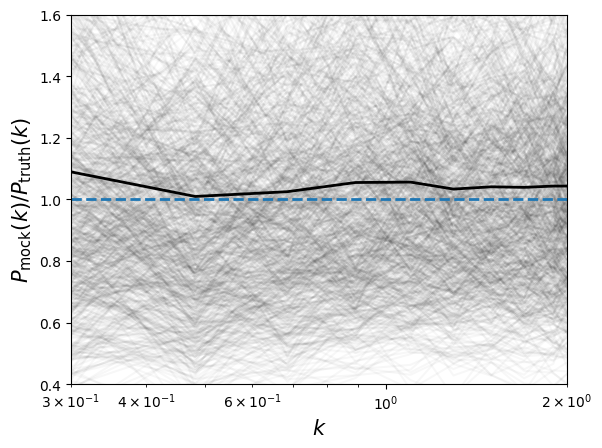

In [ ]:
pl.figure()
resid_all = []
# for jp in range(len(Pk_all)):
# for jp in indhigh:    
Pk_all_concat = []
Pk_all_truth_concat = []
# for jp in indlow:        
for jp in indhigh:       
# for jp in indmid:           
# for jp in range(nvox_samp):
# for jp in indmid[::10]:            
    if (len(Pk_all[jp]) > 0) and (len(Pk_all_truth[jp]) > 0):
        # pl.plot(Pk_truth.k3D, (Pk_all[jp] - Pk_all_truth[jp])/Pk_all_truth[jp], color='k', ls='-', alpha=0.0003)
        pl.plot(Pk_truth.k3D, (Pk_all[jp])/(Pk_all_truth[jp]), color='k', ls='-', alpha=0.03)
        resid_all.append((Pk_all[jp])/Pk_all_truth[jp])
        Pk_all_concat.append(Pk_all[jp])
        Pk_all_truth_concat.append(Pk_all_truth[jp])

Pk_all_concat = np.vstack(Pk_all_concat)
Pk_all_truth_concat = np.vstack(Pk_all_truth_concat)

resid_all = np.vstack(resid_all)
pl.plot(Pk_truth.k3D, np.mean(resid_all, axis=0), color='k', ls='-', alpha=1.0, lw=2.0)
pl.axhline(1.0, ls='--', lw=2.0)
pl.xscale('log')
pl.ylim(0.4, 1.6)
pl.xlim(0.3, 2)
# pl.scale('log')
pl.xlabel(r'$k$', size=15)
pl.ylabel(r'$P_{\rm mock}(k)/P_{\rm truth}(k)$', size=15)




Text(0, 0.5, '$P_{\\rm mock}(k)/P_{\\rm truth}(k)$')

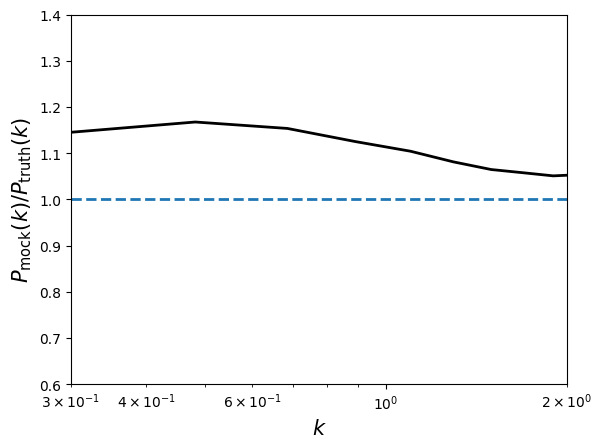

In [171]:
pl.figure()
resid_all = []
# for jp in range(len(Pk_all)):
# for jp in indhigh:    
Pk_all_concat = []
Pk_all_truth_concat = []
# for jp in indlow:        
# for jp in indhigh:       
for jp in range(nvox_samp):
# for jp in indmid[::10]:            
    if (len(Pk_all[jp]) > 0) and (len(Pk_all_truth[jp]) > 0):
        # pl.plot(Pk_truth.k3D, (Pk_all[jp] - Pk_all_truth[jp])/Pk_all_truth[jp], color='k', ls='-', alpha=0.0003)
        pl.plot(Pk_truth.k3D, (Pk_all[jp])/(Pk_all_truth[jp]), color='k', ls='-', alpha=0.0003)
        resid_all.append((Pk_all[jp])/Pk_all_truth[jp])
        Pk_all_concat.append(Pk_all[jp])
        Pk_all_truth_concat.append(Pk_all_truth[jp])

Pk_all_concat = np.vstack(Pk_all_concat)
Pk_all_truth_concat = np.vstack(Pk_all_truth_concat)

resid_all = np.vstack(resid_all)
pl.plot(Pk_truth.k3D, np.mean(resid_all, axis=0), color='k', ls='-', alpha=1.0, lw=2.0)
pl.axhline(1.0, ls='--', lw=2.0)
pl.xscale('log')
pl.ylim(0.6, 1.4)
pl.xlim(0.3, 2)
# pl.scale('log')
pl.xlabel(r'$k$', size=15)
pl.ylabel(r'$P_{\rm mock}(k)/P_{\rm truth}(k)$', size=15)




Text(0.5, 1.0, 'Power spectra of 32Mpc/$h$ sub-boxes')

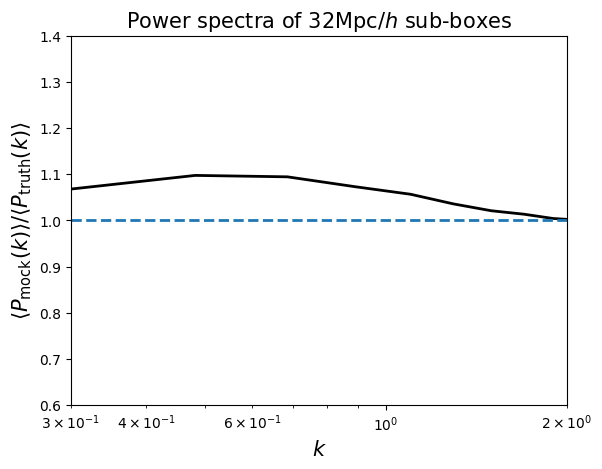

In [172]:
pl.figure()
pl.plot(Pk_truth.k3D, np.mean(Pk_all_concat, axis=0)/np.mean(Pk_all_truth_concat, axis=0), color='k', ls='-', alpha=1.0, lw=2.0)
pl.axhline(1.0, ls='--', lw=2.0)
pl.xscale('log')
pl.ylim(0.6, 1.4)
pl.xlim(0.3, 2)
# pl.scale('log')
pl.xlabel(r'$k$', size=15)
pl.ylabel(r'$\langle P_{\rm mock}(k) \rangle/\langle P_{\rm truth}(k) \rangle$', size=15)
pl.title(r'Power spectra of 32Mpc/$h$ sub-boxes', size=15)




Text(0.5, 1.0, 'Power spectra of 32Mpc/$h$ sub-boxes')

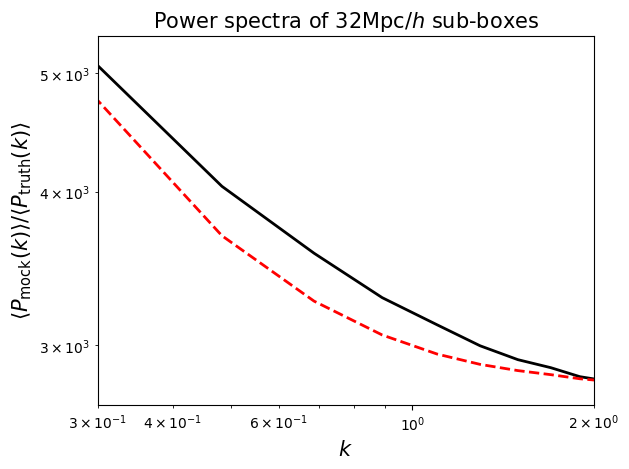

In [173]:
pl.figure()
pl.plot(Pk_truth.k3D, np.mean(Pk_all_concat, axis=0), color='k', ls='-', alpha=1.0, lw=2.0)
pl.plot(Pk_truth.k3D, np.mean(Pk_all_truth_concat, axis=0), color='r', ls='--', alpha=1.0, lw=2.0)
# pl.axhline(1.0, ls='--', lw=2.0)
pl.xscale('log')
pl.yscale('log')
# pl.ylim(0.6, 1.4)
pl.xlim(0.3, 2)
# pl.scale('log')
pl.xlabel(r'$k$', size=15)
pl.ylabel(r'$\langle P_{\rm mock}(k) \rangle/\langle P_{\rm truth}(k) \rangle$', size=15)
pl.title(r'Power spectra of 32Mpc/$h$ sub-boxes', size=15)




In [174]:
# Pk_all_concat.shape
# Pk_truth.k3D


Text(0.5, 1.0, 'Power spectra of 32Mpc/$h$ sub-boxes')

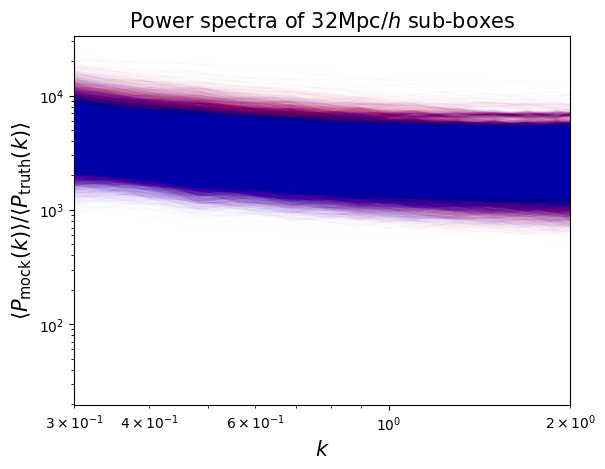

In [175]:
pl.figure()
for jp in range(len(Pk_all_concat)):
    pl.plot(Pk_truth.k3D, (Pk_all_concat[jp]), color='r', ls='-', alpha=0.01, lw=1.0)
for jp in range(len(Pk_all_concat)):    
    pl.plot(Pk_truth.k3D, (Pk_all_truth_concat[jp]), color='b', ls='-', alpha=0.01, lw=1.0)
# pl.axhline(1.0, ls='--', lw=2.0)
pl.xscale('log')
pl.yscale('log')
# pl.ylim(0.6, 1.4)
pl.xlim(0.3, 2)
# pl.scale('log')
pl.xlabel(r'$k$', size=15)
pl.ylabel(r'$\langle P_{\rm mock}(k) \rangle/\langle P_{\rm truth}(k) \rangle$', size=15)
pl.title(r'Power spectra of 32Mpc/$h$ sub-boxes', size=15)




In [176]:
# pl.figure()
# resid_all = []
# # for jp in range(len(Pk_all)):
# # for jp in indhigh:    
# for jp in indlow:        
#     if (len(Pk_all[jp]) > 0) and (len(Pk_all_truth[jp]) > 0):
#         # pl.plot(Pk_truth.k3D, (Pk_all[jp] - Pk_all_truth[jp])/Pk_all_truth[jp], color='k', ls='-', alpha=0.0003)
#         pl.plot(Pk_truth.k3D, (Pk_all[jp])/(Pk_all_truth[jp]), color='k', ls='-', alpha=0.03)
#         resid_all.append((Pk_all[jp])/Pk_all_truth[jp])

# resid_all = np.vstack(resid_all)
# pl.plot(Pk_truth.k3D, np.mean(resid_all, axis=0), color='k', ls='-', alpha=1.0, lw=2.0)
# pl.axhline(1.0, ls='--', lw=2.0)
# pl.xscale('log')
# pl.ylim(0.6, 1.4)
# pl.xlim(0.3, 2)
# # pl.scale('log')
# pl.xlabel(r'$k$', size=15)
# pl.ylabel(r'$P_{\rm mock}(k)/P_{\rm truth}(k)$', size=15)




In [ ]:
# np.amin(np.array(Nhalo_all_truth_concat))
np.amin(np.array(Nhalo_all_truth_concat)), np.amin(np.array(Nhalo_all_concat))


(0, 0)

In [ ]:
np.histogram(np.array(Nhalo_all_truth_concat), bins=53, range=(-1, 52))

(array([   0, 8770, 7379, 5345, 3843, 2568, 1767, 1080,  770,  458,  285,
         188,  119,   84,   57,   23,    7,    9,    2,    3,    2,    9,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0]),
 array([-1.,  0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.,
        12., 13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24.,
        25., 26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37.,
        38., 39., 40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50.,
        51., 52.]))

(0.0, 20.0)

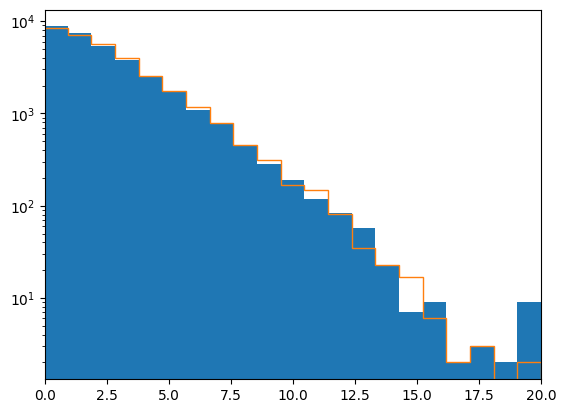

In [ ]:
# np.array(Nhalo_all_truth_concat).shape
pl.figure()
_ = pl.hist(np.array(Nhalo_all_truth_concat), range=(-1,20), bins=22)
_ = pl.hist(np.array(Nhalo_all_concat), range=(-1,20), bins=22, histtype='step')
pl.yscale('log')
pl.xlim(0,20)



In [ ]:
# len(Mhalo_all)
# len(np.array(Mhalo_all_truth_concat)), len(np.array(Mhalo_all_concat))
np.amin(np.array(Mhalo_all_truth_concat)), np.amax(np.array(Mhalo_all_concat))
                                           


(13.529777777777777, 15.404666666666666)

(13.5, 15.5)

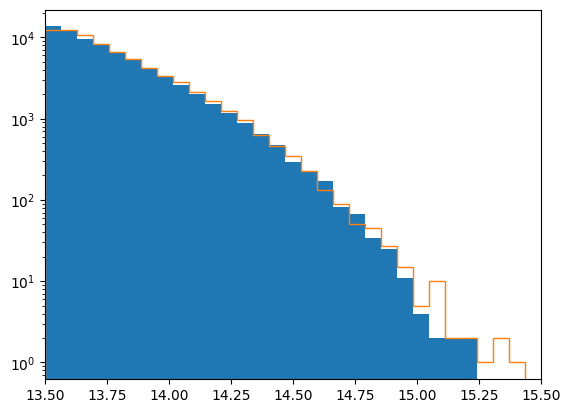

In [ ]:
# np.array(Nhalo_all_truth_concat).shape
pl.figure()
_ = pl.hist(np.array(Mhalo_all_truth_concat), range=(13.5,15.5), bins=31)
# _ = pl.hist(np.array(lgMass_truth_orig), range=(13,15.5), bins=21, histtype='step')
_ = pl.hist(np.array(Mhalo_all_concat), range=(13.5,15.5), bins=31, histtype='step')
pl.yscale('log')
pl.xlim(13.5, 15.5)
# lgMass_truth_orig


In [ ]:
# np.nonzero(Nhalo_all_truth_concat)[0].shape, np.nonzero(Nhalo_all_concat)[0].shape, pos_all_concat.shape, pos_all_truth_concat.shape

# np.nonzero(Nhalo_all_truth_concat)[0].shape, np.nonzero(Nhalo_all_concat)[0].shape


In [46]:
# import copy
# pos_all_concat_try1 = copy.deepcopy(pos_all_concat)
np.unique(np.array(Mhalo_all_truth_concat))


array([13.52977778, 13.56155556, 13.59333333, 13.62511111, 13.65688889,
       13.68866667, 13.72044444, 13.75222222, 13.784     , 13.81577778,
       13.84755556, 13.87933333, 13.91111111, 13.94288889, 13.97466667,
       14.00644444, 14.03822222, 14.07      , 14.10177778, 14.13355556,
       14.16533333, 14.19711111, 14.22888889, 14.26066667, 14.29244444,
       14.32422222, 14.356     , 14.38777778, 14.41955556, 14.45133333,
       14.48311111, 14.51488889, 14.54666667, 14.57844444, 14.61022222,
       14.642     , 14.67377778, 14.70555556, 14.73733333, 14.76911111,
       14.80088889, 14.83266667, 14.86444444, 14.89622222, 14.928     ,
       14.95977778, 14.99155556, 15.02333333, 15.05511111, 15.08688889])

In [110]:
# import copy
# pos_all_concat_try2 = copy.deepcopy(pos_all_concat)



In [111]:
# pos_all_concat_try1.shape

In [112]:
# pos_all_concat_try2


In [113]:
# # grid_Pk = 512
# grid_Pk_full = 512
# threads = 10
# MAS = 'CIC'
# mesh_mock = np.zeros((grid_Pk_full, grid_Pk_full, grid_Pk_full), dtype=np.float32)
# # indsel_M = np.where((np.array(Mhalo_all_concat) > Mmin_Pk) & (np.array(Mhalo_all_concat) < Mmax_Pk))[0]
# # print(f'Number of halos in tokenized mock cat {len(indsel_M)}')
# MASL.MA(pos_all_concat_try1.astype(np.float32), mesh_mock, 1000., MAS)
# mesh_mock1 = mesh_mock/np.mean(mesh_mock, dtype=np.float64);  mesh_mock1 -= 1.0
# Pk_mock1_full = PKL.Pk(mesh_mock1, 1000., axis=0, MAS=MAS, threads=threads, verbose=False)

# # grid_Pk = 512
# threads = 10
# MAS = 'CIC'
# mesh_mock = np.zeros((grid_Pk_full, grid_Pk_full, grid_Pk_full), dtype=np.float32)
# # indsel_M = np.where((np.array(Mhalo_all_concat) > Mmin_Pk) & (np.array(Mhalo_all_concat) < Mmax_Pk))[0]
# # print(f'Number of halos in tokenized mock cat {len(indsel_M)}')
# MASL.MA(pos_all_concat_try2.astype(np.float32), mesh_mock, 1000., MAS)
# mesh_mock2 = mesh_mock/np.mean(mesh_mock, dtype=np.float64);  mesh_mock2 -= 1.0
# Pk_mock2_full = PKL.Pk(mesh_mock2, 1000., axis=0, MAS=MAS, threads=threads, verbose=False)




# # Pk_truth_mock_full = PKL.XPk([mesh_mock, mesh_truth], 1000., axis=0, MAS=[MAS, MAS], threads=threads)




In [114]:
# pl.figure()
# pl.plot(Pk_mock1_full.k3D, Pk_mock1_full.Pk[:,0], color='r', ls='-', alpha=1.0, lw=1.0)
# pl.plot(Pk_mock2_full.k3D, Pk_mock2_full.Pk[:,0], color='b', ls='-', alpha=1.0, lw=1.0)
# pl.plot(Pk_truth_full_orig.k3D, Pk_truth_full_orig.Pk[:,0], color='k', ls='-', alpha=1.0, lw=1.0)
# pl.xscale('log')
# pl.yscale('log')


In [97]:
# np.amin(pos_all_truth_concat[:,2]), np.amax(pos_all_truth_concat[:,2])
np.amin(pos_all_concat[:,2]), np.amax(pos_all_concat[:,2])
# pos_all_truth_concat.shape



(0.4652777777777777, 1000.0)

In [98]:
# pl.figure(figsize=(6,6))
# pl.scatter(pos_all_concat[:,0], pos_all_concat[:,1], s=0.001)
# pl.title('Halos Mock (tokenized)', size=16)


In [99]:
# isim_fid = 1
snapnum = 3
mass_type = 'rockstar_200c'
snap_dir_base = '/mnt/home/fvillaescusa/ceph/Quijote/Halos/Rockstar/fiducial_HR'
snapdir = snap_dir_base + '/' + str(isim_fid)  #folder hosting the catalogue
rockstar = np.loadtxt(snapdir + '/out_' + str(snapnum) + '_pid.list')
with open(snapdir + '/out_' + str(snapnum) + '_pid.list', 'r') as f:
    lines = f.readlines()
header = lines[0].split()
# get the properties of the halos
pos_h_truth = rockstar[:,header.index('X'):header.index('Z')+1]
if mass_type == 'rockstar_vir':
    index_M = header.index('Mvir')                    
    mass_truth = rockstar[:,index_M]  #Halo masses in Msun/h
if mass_type == 'rockstar_200c':
    index_M = header.index('M200c')                    
    mass_truth = rockstar[:,index_M]  #Halo masses in Msun/h

Mmin_cut = 10**13.5
lgMass_truth = np.log10(mass_truth)
indsel = np.where(mass_truth > Mmin_cut)[0]
# print(grid, len(indsel), len(mass_truth), np.amin(lgMass_truth), np.log10(Mmin_cut))
pos_h_truth_orig = pos_h_truth[indsel]
lgMass_truth_orig = lgMass_truth[indsel]



/tmp/ipykernel_708657/4139340561.py:20: RuntimeWarning: divide by zero encountered in log10
  lgMass_truth = np.log10(mass_truth)


Text(0.5, 1.0, 'Halos Mock (tokenized)')

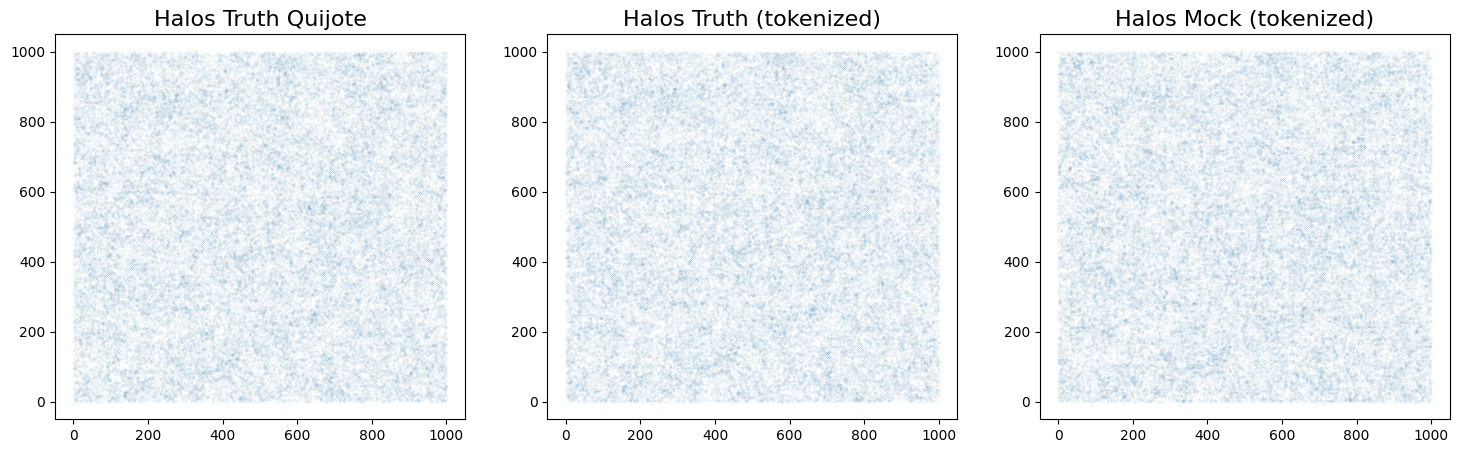

In [100]:
fig, (ax1, ax2, ax3) = pl.subplots(1, 3, figsize=(18, 5))
# fig.suptitle('Horizontally stacked subplots')
# ax1.plot(x, y)
# ax2.plot(x, -y)

ax1.scatter(pos_h_truth_orig[:,0], pos_h_truth_orig[:,1], s=0.001)
ax1.set_title('Halos Truth Quijote', size=16)


ax2.scatter(pos_all_truth_concat[:,0], pos_all_truth_concat[:,1], s=0.001)
ax2.set_title('Halos Truth (tokenized)', size=16)


# ax1.set_xlim(400,600)
# ax1.set_ylim(400,600)
# fig.add_subplot(121)
ax3.scatter(pos_all_concat[:,0], pos_all_concat[:,1], s=0.001)
ax3.set_title('Halos Mock (tokenized)', size=16)
# ax2.set_xlim(400,600)
# ax2.set_ylim(400,600)




In [101]:
# Mmin_Pk, Mmax_Pk = 13.5, np.inf
# Mmin_Pk, Mmax_Pk = 13.478, np.inf
Mmin_Pk, Mmax_Pk = 13.5, np.inf
# Mmin_Pk, Mmax_Pk = 13.5, 14.0
# Mmin_Pk, Mmax_Pk = -np.inf, np.inf
M1 = 14.0
# alpha = 0.66
alpha = 0.6




In [102]:
grid_Pk_full = 512
threads = 10
MAS = 'CIC'
mesh_truth = np.zeros((grid_Pk_full, grid_Pk_full, grid_Pk_full), dtype=np.float32)
indsel_M = np.where((lgMass_truth_orig > Mmin_Pk) & (lgMass_truth_orig < Mmax_Pk))[0]
print(f'Number of halos in original true cat {len(indsel_M)}')
W = (10**lgMass_truth_orig[indsel_M]/10**M1)**(alpha)
MASL.MA(pos_h_truth_orig[indsel_M].astype(np.float32), mesh_truth, 1000., MAS, W=W.astype(np.float32))
mesh_truth /= np.mean(mesh_truth, dtype=np.float64);  mesh_truth -= 1.0
Pk_truth_full_orig = PKL.Pk(mesh_truth, 1000., axis=0, MAS=MAS, threads=threads, verbose=False)



Number of halos in original true cat 72627


In [103]:
# grid_Pk_full = 512
threads = 10
MAS = 'CIC'
mesh_truth = np.zeros((grid_Pk_full, grid_Pk_full, grid_Pk_full), dtype=np.float32)
indsel_M = np.where((np.array(Mhalo_all_truth_concat) > Mmin_Pk) & (np.array(Mhalo_all_truth_concat) < Mmax_Pk))[0]
print(f'Number of halos in tokenized true cat {len(indsel_M)}')
W = (10**np.array(Mhalo_all_truth_concat)[indsel_M]/10**M1)**(alpha)
MASL.MA(pos_all_truth_concat[indsel_M].astype(np.float32), mesh_truth, 1000., MAS, W=W.astype(np.float32))
mesh_truth /= np.mean(mesh_truth, dtype=np.float64);  mesh_truth -= 1.0
Pk_truth_full = PKL.Pk(mesh_truth, 1000., axis=0, MAS=MAS, threads=threads, verbose=False)




Number of halos in tokenized true cat 72619


In [104]:
# grid_Pk = 512
threads = 10
MAS = 'CIC'
mesh_mock = np.zeros((grid_Pk_full, grid_Pk_full, grid_Pk_full), dtype=np.float32)
indsel_M = np.where((np.array(Mhalo_all_concat) > Mmin_Pk) & (np.array(Mhalo_all_concat) < Mmax_Pk))[0]
print(f'Number of halos in tokenized mock cat {len(indsel_M)}')
W = (10**np.array(Mhalo_all_concat)[indsel_M]/10**M1)**(alpha)
MASL.MA(pos_all_concat[indsel_M].astype(np.float32), mesh_mock, 1000., MAS, W=W.astype(np.float32))
mesh_mock /= np.mean(mesh_mock, dtype=np.float64);  mesh_mock -= 1.0
Pk_mock_full = PKL.Pk(mesh_mock, 1000., axis=0, MAS=MAS, threads=threads, verbose=False)




Number of halos in tokenized mock cat 73967


In [105]:
np.amax(np.array(Mhalo_all_concat))


15.404666666666666

In [106]:
# isim_fid


Text(0.5, 1.0, 'Sim index = 5, 13.5$ < \\log({M}) <$inf')

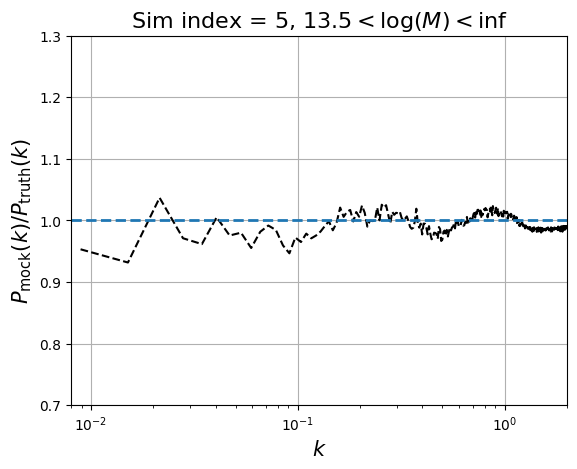

In [107]:
pl.figure()
# pl.plot(Pk_truth_full.k3D, Pk_mock_full.Pk[:,0]/Pk_truth_full.Pk[:,0], color='k', ls='-', alpha=1.0)
pl.plot(Pk_truth_full_orig.k3D, Pk_mock_full.Pk[:,0]/Pk_truth_full_orig.Pk[:,0], color='k', ls='--', alpha=1.0)
# pl.plot(Pk_truth_full_orig.k3D, Pk_truth_full.Pk[:,0]/Pk_truth_full_orig.Pk[:,0], color='k', ls=':', alpha=1.0)
# pl.plot(Pk_truth_full.k3D, Pk_mock_full.Pk[:,0]/Pk_truth_full_orig.Pk[:,0], color='k', ls='-', alpha=1.0)
# pl.plot(Pk_truth_full.k3D, Pk_truth_full.Pk[:,0]/Pk_truth_full_orig.Pk[:,0], color='k', ls='-', alpha=1.0)
# pl.plot(Pk_mock.k3D, Pk_mock.Pk[:,0], color='r', ls='--', alpha=1.0)

# resid_all = np.vstack(resid_all)
# pl.plot(Pk_truth.k3D, np.mean(resid_all, axis=0), color='k', ls='-', alpha=1.0, lw=2.0)
pl.axhline(1.0, ls='--', lw=2.0)
pl.xscale('log')
# pl.yscale('log')
pl.ylim(0.7, 1.3)
pl.xlim(0.008, 2)
# pl.scale('log')
pl.xlabel(r'$k$', size=15)
pl.grid()
# pl.ylabel(r'$\Delta P(k)/P(k)$', size=15)
pl.ylabel(r'$P_{\rm mock}(k)/P_{\rm truth}(k)$', size=15)
pl.title(f'Sim index = {isim_fid}, ' + str(Mmin_Pk) + r'$ < \log({M}) <$' + str(Mmax_Pk), size=16)




In [169]:
Pk_truth_mock_full = PKL.XPk([mesh_mock, mesh_truth], 1000., axis=0, MAS=[MAS, MAS], threads=threads)



Computing power spectra of the fields...
Time FFTS = 1.05
Time loop = 2.86
Time taken = 3.92 seconds


Text(0, 0.5, '$r(k) = P_{\\rm truth \\times mock}/\\sqrt{P_{\\rm truth} \\times P_{\\rm mock}}$')

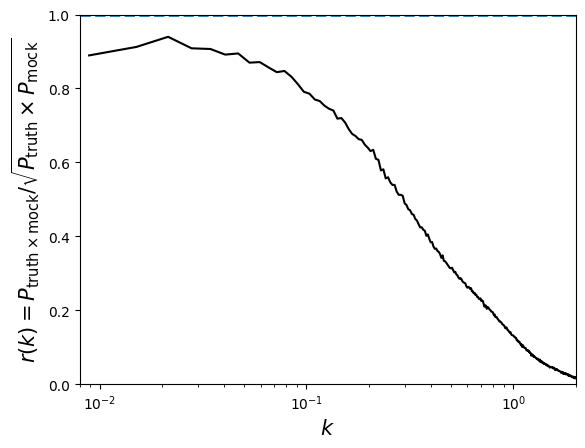

In [121]:
pl.figure()
pl.plot(Pk_truth_full.k3D, Pk_truth_mock_full.XPk[:,0,0]/np.sqrt(Pk_truth_full.Pk[:,0] * Pk_mock_full.Pk[:,0]), color='k', ls='-', alpha=1.0)
# pl.plot(Pk_mock.k3D, Pk_mock.Pk[:,0], color='r', ls='--', alpha=1.0)

# resid_all = np.vstack(resid_all)
# pl.plot(Pk_truth.k3D, np.mean(resid_all, axis=0), color='k', ls='-', alpha=1.0, lw=2.0)
pl.axhline(1.0, ls='--', lw=2.0)
pl.xscale('log')
# pl.yscale('log')
pl.ylim(0.0, 1.0)
pl.xlim(0.008, 2)
# pl.scale('log')
pl.xlabel(r'$k$', size=15)
pl.ylabel(r'$r(k) = P_{\rm truth \times mock}/\sqrt{P_{\rm truth} \times P_{\rm mock}}$', size=15)




Text(0.5, 1.0, '13.5$ < \\log({M}) <$14.0')

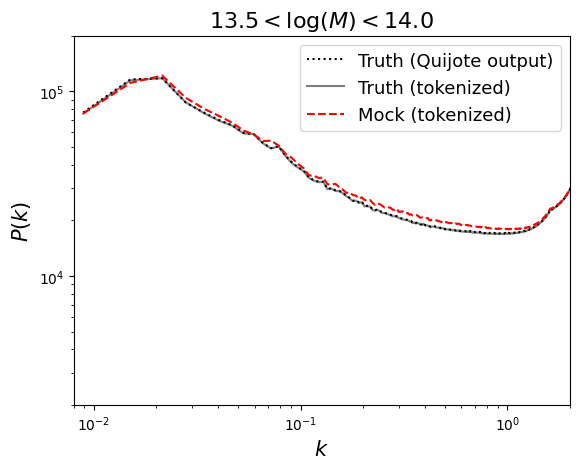

In [65]:
pl.figure()
pl.plot(Pk_truth_full.k3D, Pk_truth_full_orig.Pk[:,0], color='k', ls=':', alpha=1.0, label='Truth (Quijote output)')
pl.plot(Pk_truth_full.k3D, Pk_truth_full.Pk[:,0], color='k', ls='-', alpha=0.5, label='Truth (tokenized)')
pl.plot(Pk_mock_full.k3D, Pk_mock_full.Pk[:,0], color='r', ls='--', alpha=1.0, label='Mock (tokenized)')

# resid_all = np.vstack(resid_all)
# pl.plot(Pk_truth.k3D, np.mean(resid_all, axis=0), color='k', ls='-', alpha=1.0, lw=2.0)
# pl.axhline(0.0, ls='--', lw=2.0)
pl.xscale('log')
pl.yscale('log')
pl.legend(fontsize=13)
pl.ylim(2e3, 2e5)
pl.xlim(0.008, 2)

# pl.scale('log')
pl.xlabel(r'$k$', size=15)
pl.ylabel(r'$P(k)$', size=15)
pl.title(str(Mmin_Pk) + r'$ < \log({M}) <$' + str(Mmax_Pk), size=16)




Text(0.5, 1.0, '13.0$ < \\log({M}) <$13.5')

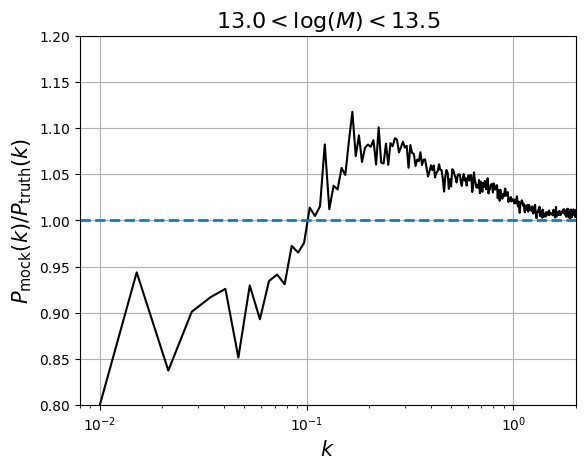

In [123]:
pl.figure()
pl.plot(Pk_truth_full.k3D, Pk_mock_full.Pk[:,0]/Pk_truth_full.Pk[:,0], color='k', ls='-', alpha=1.0)
# pl.plot(Pk_truth_full.k3D, Pk_mock_full.Pk[:,0]/Pk_truth_full_orig.Pk[:,0], color='k', ls='-', alpha=1.0)
# pl.plot(Pk_truth_full.k3D, Pk_truth_full.Pk[:,0]/Pk_truth_full_orig.Pk[:,0], color='k', ls='-', alpha=1.0)
# pl.plot(Pk_mock.k3D, Pk_mock.Pk[:,0], color='r', ls='--', alpha=1.0)

# resid_all = np.vstack(resid_all)
# pl.plot(Pk_truth.k3D, np.mean(resid_all, axis=0), color='k', ls='-', alpha=1.0, lw=2.0)
pl.axhline(1.0, ls='--', lw=2.0)
pl.xscale('log')
# pl.yscale('log')
pl.ylim(0.8, 1.2)
pl.xlim(0.008, 2)
# pl.scale('log')
pl.xlabel(r'$k$', size=15)
pl.grid()
# pl.ylabel(r'$\Delta P(k)/P(k)$', size=15)
pl.ylabel(r'$P_{\rm mock}(k)/P_{\rm truth}(k)$', size=15)
pl.title(str(Mmin_Pk) + r'$ < \log({M}) <$' + str(Mmax_Pk), size=16)



In [95]:
Nhalo_all_truth_concat = []
for jv in range(len(Nhalo_all_truth)):
    if type(Nhalo_all_truth[jv]) == int:
        Nhalo_all_truth_concat.append(Nhalo_all_truth[jv])

Nhalo_all_concat = []
for jv in range(len(Nhalo_all)):
    if type(Nhalo_all[jv]) == int:
        Nhalo_all_concat.append(Nhalo_all[jv])  

    

In [96]:
# 2+2
len(Nhalo_all_concat), len(Nhalo_all_truth_concat)
# Nhalo_all_concat[0:100]
# Nhalo_all[0]


(32682, 32043)

In [97]:
# Nhalo_all_hist
# Nhalo_all_concat[0:100]
# bins_all

In [98]:
bins_all = np.linspace(0,40, 40)
bins_cents = (bins_all[:-1] + bins_all[1:])/2
Nhalo_all_hist, _ = np.histogram(np.array(Nhalo_all_concat), bins= bins_all)
Nhalo_all_truth_hist, _ = np.histogram(np.array(Nhalo_all_truth_concat), bins= bins_all)


(0.0, 32.0)

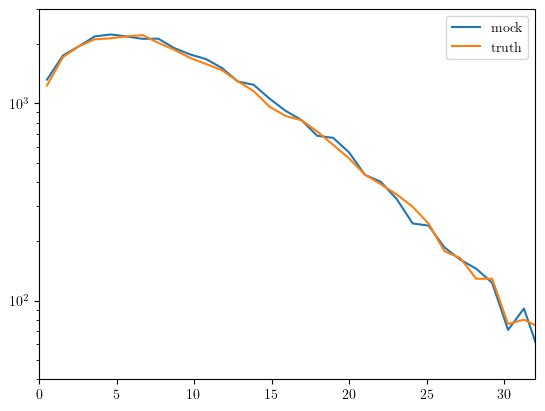

In [99]:
pl.figure()
pl.plot(bins_cents, Nhalo_all_hist, label='mock')
pl.plot(bins_cents, Nhalo_all_truth_hist, label='truth')
# _ = pl.hist(Nhalo_all_concat)
# _ = pl.hist(Nhalo_all_truth_concat)
pl.legend()
pl.yscale('log')
pl.ylim(40, 3000)
pl.xlim(0,32)




In [ ]:
pos_all_truth = []
Mhalo_all_truth = []
Nhalo_all_truth = []
# Pk_all_truth = []

BoxSize = 1000.
grid = 32
xmin = BoxSize/grid/2

MAS     = 'NGP'  #mass-assigment scheme
grid_Pk = 32
threads = 10

for jv in range(nvox_samp):
# for jv in indhigh[:nvox_samp]:    
    idx = X_val[jv]
    idx = idx.cpu().numpy().flatten()
    # idx = idx[1:]
    # idx = idx[:np.where(idx == end_token)[0][0]]
    # idx = idx.reshape(-1, 5)
    idxe = np.where(idx == space_token)[0] + 1
    idx0 = np.where(idx == start_token)[0] + 1
    # check with idx0 is a scalar or an array:
    # try:
        # temp = len(idx0)
        # print(temp)
    # except:
    if len(idx0) == 1:
        Nhalo = len(idxe) + len(idx0)
        Nhalo_all_truth.append(Nhalo)
    
        if Nhalo > 0:
            try:
                Mhalo = np.zeros(Nhalo)
                pos_halo = np.zeros((Nhalo, 3))
                for jh in range(Nhalo):
                    if jh == 0:
                        Mhalo[jh] = bins_digitize[idx[idx0]] * (lgMax - lgMin) + lgMin
                        for jx in range(3):
                            pos_halo[jh, jx] = bins_digitize[idx[idx0 + jx + 1]] * 2 * xmin            
                    else:
                        if Nhalo > 2:
                            Mhalo[jh] = bins_digitize[idx[idxe[jh-1]]] * (lgMax - lgMin) + lgMin
                            for jx in range(3):
                                pos_halo[jh, jx] = bins_digitize[idx[idxe[jh-1] + jx + 1]] * 2 * xmin            
                        else:
                            Mhalo[jh] = bins_digitize[idx[idxe]] * (lgMax - lgMin) + lgMin
                            for jx in range(3):
                                pos_halo[jh, jx] = bins_digitize[idx[idxe + jx + 1]] * 2 * xmin            

                Mhalo_all_truth.append(Mhalo)
                pos_all_truth.append(pos_halo)

                if Nhalo > 5:
                    mesh_truth = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
                    MASL.MA(pos_halo.astype(np.float32), mesh_truth, 2*xmin, MAS)
                    mesh_truth /= np.mean(mesh_truth, dtype=np.float64);  mesh_truth -= 1.0
                    Pk_truth = PKL.Pk(mesh_truth, 2*xmin, axis=0, MAS=None, threads=threads, verbose=False)
                    Pk_all_truth.append(Pk_truth.Pk[:,0])
                else:
                    Pk_all_truth.append([])

            except:
                Mhalo_all_truth.append(np.array([]))
                pos_all_truth.append(np.array([]))
                Pk_all_truth.append([])                
                pass
        else:
            Mhalo_all_truth.append(np.array([]))
            pos_all_truth.append(np.array([]))
            Pk_all_truth.append([])                
    else:
        Nhalo_all_truth.append(np.array([]))
        Mhalo_all_truth.append(np.array([]))
        pos_all_truth.append(np.array([]))
        Pk_all_truth.append([])                


In [24]:
pos_all_truth = []
Mhalo_all_truth = []
Nhalo_all_truth = []
Pk_all_truth = []

BoxSize = 1000.
grid = 32
xmin = BoxSize/grid/2

MAS     = 'NGP'  #mass-assigment scheme
grid_Pk = 32
threads = 10

# for jv in range(nvox_samp):
for jv in indhigh[:nvox_samp]:    
    idx = X_val[jv]
    idx = idx.cpu().numpy().flatten()
    # idx = idx[1:]
    # idx = idx[:np.where(idx == end_token)[0][0]]
    # idx = idx.reshape(-1, 5)
    idxe = np.where(idx == space_token)[0] + 1
    idx0 = np.where(idx == start_token)[0] + 1
    # check with idx0 is a scalar or an array:
    # try:
        # temp = len(idx0)
        # print(temp)
    # except:
    if len(idx0) == 1:
        Nhalo = len(idxe) + len(idx0)
        Nhalo_all_truth.append(Nhalo)
    
        if Nhalo > 0:
            try:
                Mhalo = np.zeros(Nhalo)
                pos_halo = np.zeros((Nhalo, 3))
                for jh in range(Nhalo):
                    if jh == 0:
                        Mhalo[jh] = bins_digitize[idx[idx0]] * (lgMax - lgMin) + lgMin
                        for jx in range(3):
                            pos_halo[jh, jx] = bins_digitize[idx[idx0 + jx + 1]] * 2 * xmin            
                    else:
                        if Nhalo > 2:
                            Mhalo[jh] = bins_digitize[idx[idxe[jh-1]]] * (lgMax - lgMin) + lgMin
                            for jx in range(3):
                                pos_halo[jh, jx] = bins_digitize[idx[idxe[jh-1] + jx + 1]] * 2 * xmin            
                        else:
                            Mhalo[jh] = bins_digitize[idx[idxe]] * (lgMax - lgMin) + lgMin
                            for jx in range(3):
                                pos_halo[jh, jx] = bins_digitize[idx[idxe + jx + 1]] * 2 * xmin            

                Mhalo_all_truth.append(Mhalo)
                pos_all_truth.append(pos_halo)

                if Nhalo > 5:
                    mesh_truth = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
                    MASL.MA(pos_halo.astype(np.float32), mesh_truth, 2*xmin, MAS)
                    mesh_truth /= np.mean(mesh_truth, dtype=np.float64);  mesh_truth -= 1.0
                    Pk_truth = PKL.Pk(mesh_truth, 2*xmin, axis=0, MAS=None, threads=threads, verbose=False)
                    Pk_all_truth.append(Pk_truth.Pk[:,0])
                else:
                    Pk_all_truth.append([])

            except:
                Mhalo_all_truth.append(np.array([]))
                pos_all_truth.append(np.array([]))
                Pk_all_truth.append([])                
                pass
        else:
            Mhalo_all_truth.append(np.array([]))
            pos_all_truth.append(np.array([]))
            Pk_all_truth.append([])                
    else:
        Nhalo_all_truth.append(np.array([]))
        Mhalo_all_truth.append(np.array([]))
        pos_all_truth.append(np.array([]))
        Pk_all_truth.append([])                


/tmp/ipykernel_2188932/359875854.py:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Mhalo[jh] = bins_digitize[idx[idx0]] * (lgMax - lgMin) + lgMin
/tmp/ipykernel_2188932/359875854.py:40: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pos_halo[jh, jx] = bins_digitize[idx[idx0 + jx + 1]] * 2 * xmin


In [25]:
# len(Pk_all_truth)
# Pk_truth.Pk.shape, Pk_truth.k3D.shape



In [26]:
# idx_all
Nhalo_all = []
Mhalo_all = []
Pk_all = []

for jv in range(nvox_samp):
    idx = idx_all[jv]
    idx = idx.cpu().numpy().flatten()
    # idx = idx[1:]
    # idx = idx[:np.where(idx == end_token)[0][0]]
    # idx = idx.reshape(-1, 5)
    idxe = np.where(idx == space_token)[0] + 1
    idx0 = np.where(idx == start_token)[0] + 1
    # check with idx0 is a scalar or an array:
    # try:
        # temp = len(idx0)
        # print(temp)
    # except:
    if len(idx0) == 1:
        Nhalo = len(idxe) + len(idx0)
        Nhalo_all.append(Nhalo)
    
        if Nhalo > 0:
            try:
                Mhalo = np.zeros(Nhalo)
                pos_halo = np.zeros((Nhalo, 3))                
                for jh in range(Nhalo):
                    if jh == 0:
                        Mhalo[jh] = bins_digitize[idx[idx0]] * (lgMax - lgMin) + lgMin
                        for jx in range(3):
                            pos_halo[jh, jx] = bins_digitize[idx[idx0 + jx + 1]] * 2 * xmin            

                    else:
                        if Nhalo > 2:
                            Mhalo[jh] = bins_digitize[idx[idxe[jh-1]]] * (lgMax - lgMin) + lgMin
                            for jx in range(3):
                                pos_halo[jh, jx] = bins_digitize[idx[idxe[jh-1] + jx + 1]] * 2 * xmin            

                        else:
                            Mhalo[jh] = bins_digitize[idx[idxe]] * (lgMax - lgMin) + lgMin
                            for jx in range(3):
                                pos_halo[jh, jx] = bins_digitize[idx[idxe + jx + 1]] * 2 * xmin            

                Mhalo_all.append(Mhalo)

                if Nhalo > 5:
                    mesh_truth = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
                    MASL.MA(pos_halo.astype(np.float32), mesh_truth, 2*xmin, MAS)
                    mesh_truth /= np.mean(mesh_truth, dtype=np.float64);  mesh_truth -= 1.0
                    Pk_truth = PKL.Pk(mesh_truth, 2*xmin, axis=0, MAS=None, threads=threads, verbose=False)
                    Pk_all.append(Pk_truth.Pk[:,0])
                else:
                    Pk_all.append([])


            except:
                Mhalo_all.append(np.array([]))
                Pk_all.append([])
                pass
        else:
            Mhalo_all.append(np.array([]))
            Pk_all.append([])

    else:
        Nhalo_all.append(np.array([]))
        Mhalo_all.append(np.array([]))
        Pk_all.append([])



/tmp/ipykernel_2188932/260296683.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Mhalo[jh] = bins_digitize[idx[idx0]] * (lgMax - lgMin) + lgMin
/tmp/ipykernel_2188932/260296683.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pos_halo[jh, jx] = bins_digitize[idx[idx0 + jx + 1]] * 2 * xmin


Text(0, 0.5, '$\\Delta P(k)/P(k)$')

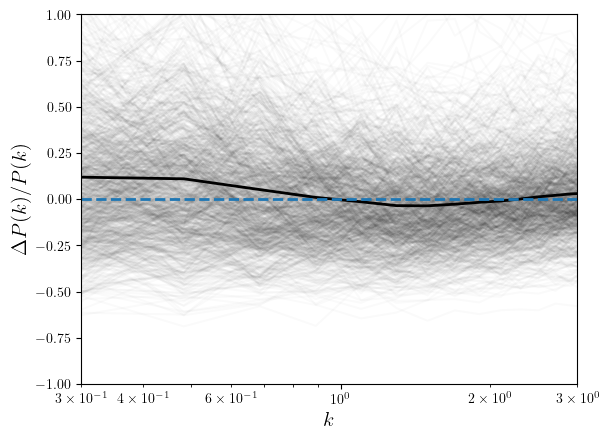

In [27]:
pl.figure()
resid_all = []
for jp in range(len(Pk_all)):
    if (len(Pk_all[jp]) > 0) and (len(Pk_all_truth[jp]) > 0):
        pl.plot(Pk_truth.k3D, (Pk_all[jp] - Pk_all_truth[jp])/Pk_all_truth[jp], color='k', ls='-', alpha=0.02)
        resid_all.append((Pk_all[jp] - Pk_all_truth[jp])/Pk_all_truth[jp])

resid_all = np.vstack(resid_all)
pl.plot(Pk_truth.k3D, np.mean(resid_all, axis=0), color='k', ls='-', alpha=1.0, lw=2.0)
pl.axhline(0.0, ls='--', lw=2.0)
pl.xscale('log')
pl.ylim(-1.0, 1.0)
pl.xlim(0.3, 3)
# pl.scale('log')
pl.xlabel(r'$k$', size=15)
pl.ylabel(r'$\Delta P(k)/P(k)$', size=15)




Text(0, 0.5, '$P(k)$')

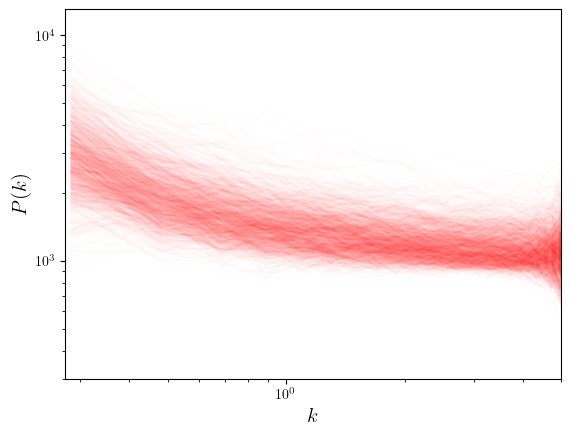

In [28]:
pl.figure()
Pktruth_mean_all = []
for jp in range(len(Pk_all)):
    if (len(Pk_all[jp]) > 0) and (len(Pk_all_truth[jp]) > 0):
        pl.plot(Pk_truth.k3D, Pk_all_truth[jp], color='r', ls='-', alpha=0.01)
        Pktruth_mean_all.append(Pk_all_truth[jp])
        # pl.plot(Pk_truth.k3D, Pk_all_truth[jp], color='b', ls='--', alpha=0.01)
        # resid_all.append((Pk_all[jp] - Pk_all_truth[jp])/Pk_all_truth[jp])
Pktruth_mean_all = np.vstack(Pktruth_mean_all)
# resid_all = np.vstack(resid_all)
# pl.plot(Pk_truth.k3D, np.mean(resid_all, axis=0), color='k', ls='-', alpha=1.0, lw=2.0)
pl.xscale('log')
pl.yscale('log')
# pl.ylim(-0.5, 0.5)
pl.xlim(0.275, 5)
pl.ylim(3e2, 1.3e4)
# pl.scale('log')
pl.xlabel(r'$k$', size=15)
pl.ylabel(r'$P(k)$', size=15)
# pl.title(r'Truth', size)



Text(0, 0.5, '$P(k)$')

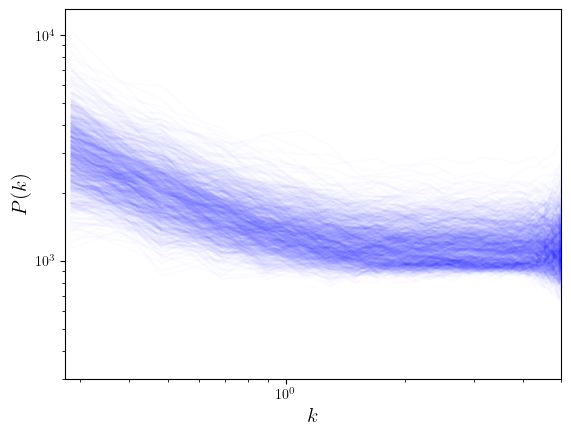

In [29]:
pl.figure()
Pk_mean_all = []
for jp in range(len(Pk_all)):
    if (len(Pk_all[jp]) > 0) and (len(Pk_all_truth[jp]) > 0):
        pl.plot(Pk_truth.k3D, Pk_all[jp], color='b', ls='-', alpha=0.01)
        Pk_mean_all.append(Pk_all[jp])
        # pl.plot(Pk_truth.k3D, Pk_all_truth[jp], color='b', ls='--', alpha=0.01)
        # resid_all.append((Pk_all[jp] - Pk_all_truth[jp])/Pk_all_truth[jp])
Pk_mean_all = np.vstack(Pk_mean_all)
# resid_all = np.vstack(resid_all)
# pl.plot(Pk_truth.k3D, np.mean(resid_all, axis=0), color='k', ls='-', alpha=1.0, lw=2.0)
pl.xscale('log')
pl.yscale('log')
# pl.ylim(-0.5, 0.5)
pl.xlim(0.275, 5)
pl.ylim(3e2, 1.3e4)
# pl.scale('log')
pl.xlabel(r'$k$', size=15)
pl.ylabel(r'$P(k)$', size=15)
# pl.title(r'Truth', size)



Text(0, 0.5, '$P(k)$')

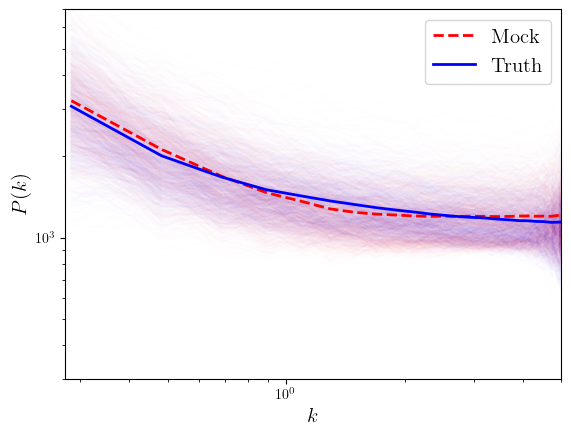

In [32]:
pl.figure()
for jp in range(len(Pk_all)):
    if (len(Pk_all[jp]) > 0) and (len(Pk_all_truth[jp]) > 0):
        pl.plot(Pk_truth.k3D, Pk_all[jp], color='r', ls='-', alpha=0.004)
        # Pk_mean_all.append(Pk_all[jp])

Pktruth_mean_all = []
for jp in range(len(Pk_all)):
    if (len(Pk_all[jp]) > 0) and (len(Pk_all_truth[jp]) > 0):
        pl.plot(Pk_truth.k3D, Pk_all_truth[jp], color='b', ls='-', alpha=0.004)
        Pktruth_mean_all.append(Pk_all_truth[jp])

# Pk_mean_all = []
# for jp in range(len(Pk_all)):
    # if (len(Pk_all[jp]) > 0) and (len(Pk_all_truth[jp]) > 0):
        # pl.plot(Pk_truth.k3D, Pk_all[jp], color='b', ls='-', alpha=0.01)
        # Pk_mean_all.append(Pk_all[jp])
        # pl.plot(Pk_truth.k3D, Pk_all_truth[jp], color='b', ls='--', alpha=0.01)
        # resid_all.append((Pk_all[jp] - Pk_all_truth[jp])/Pk_all_truth[jp])
# Pk_mean_all = np.vstack(Pk_mean_all)
# resid_all = np.vstack(resid_all)
pl.plot(Pk_truth.k3D, np.mean(Pk_mean_all, axis=0), color='r', ls='--', alpha=1.0, lw=2.0, label=r'Mock')
pl.plot(Pk_truth.k3D, np.mean(Pktruth_mean_all, axis=0), color='b', ls='-', alpha=1.0, lw=2.0, label=r'Truth')
pl.xscale('log')
pl.yscale('log')
# pl.ylim(-0.5, 0.5)
pl.xlim(0.275, 5)
pl.ylim(3e2, 7e3)
pl.legend(fontsize=15)
# pl.scale('log')
pl.xlabel(r'$k$', size=15)
pl.ylabel(r'$P(k)$', size=15)
# pl.title(r'Truth', size)



In [33]:
np.mean(Pk_mean_all, axis=0)/np.mean(Pktruth_mean_all, axis=0)


array([1.0486252 , 1.05577959, 1.00665098, 0.97575422, 0.9546787 ,
       0.93452781, 0.93591016, 0.94635405, 0.95848757, 0.96656779,
       0.97886587, 0.99196451, 1.00044523, 1.00899766, 1.0120348 ,
       1.01731845, 1.02384885, 1.03089531, 1.03986128, 1.04235678,
       1.04500534, 1.04772846, 1.05269957, 1.06006241, 1.05776604,
       1.04989725, 1.0576422 ])

In [39]:
Mhalo_all_truth_concat = []
for jv in range(len(Mhalo_all_truth)):
    Mhalo_all_truth_concat.extend(Mhalo_all_truth[jv])

Mhalo_all_concat = []
for jv in range(len(Mhalo_all)):
    Mhalo_all_concat.extend(Mhalo_all[jv])    


Text(0.5, 1.0, 'High density voxels, $\\bar{\\delta}_{{\\rm 32Mpc}/h} > 1.3$')

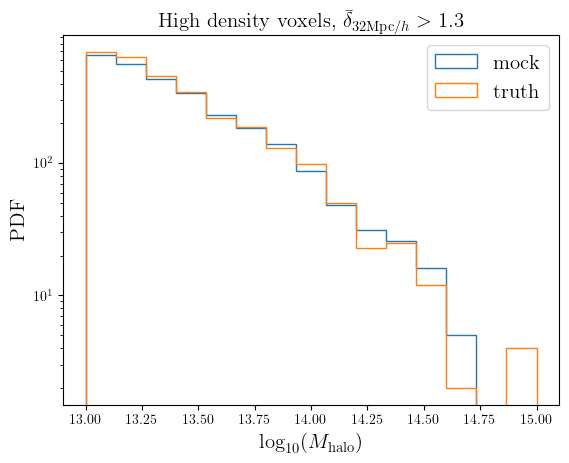

In [40]:
pl.figure()
_ = pl.hist(Mhalo_all_concat, bins=15, range=(lgMin, 15),  histtype='step', label='mock')
# _ = pl.hist(lgMsim_truth, bins=15, range=(lgMin, 15), density=True, histtype='step', label='truth')
_ = pl.hist(Mhalo_all_truth_concat, bins=15, range=(lgMin, 15), histtype='step', label='truth')
pl.yscale('log')
pl.legend(fontsize=15)
pl.xlabel(r'$\log_{10}(M_{\rm halo})$', size=15)
pl.ylabel(r'PDF', size=15)
pl.title(r'High density voxels, $\bar{\delta}_{{\rm 32Mpc}/h} > 1.3$', size=15)






In [57]:
Mhalo_all_concat_low = []
Mhalo_all_concat_mid = []
Mhalo_all_concat_high = []
for jv in indlow:
    Mhalo_all_concat_low.extend(Mhalo_all[jv])

for jv in indmid:
    Mhalo_all_concat_mid.extend(Mhalo_all[jv])

for jv in indhigh:
    Mhalo_all_concat_high.extend(Mhalo_all[jv])
    

In [58]:
# Mhalo_all_truth_concat = []
# for jv in range(len(Mhalo_all_truth)):
    # Mhalo_all_truth_concat.extend(Mhalo_all_truth[jv])

Mhalo_all_truth_concat_low = []
Mhalo_all_truth_concat_mid = []
Mhalo_all_truth_concat_high = []

for jv in indlow:
    Mhalo_all_truth_concat_low.extend(Mhalo_all_truth[jv])

for jv in indmid:
    Mhalo_all_truth_concat_mid.extend(Mhalo_all_truth[jv])

for jv in indhigh:
    Mhalo_all_truth_concat_high.extend(Mhalo_all_truth[jv])

    



Text(0.5, 1.0, 'High density voxels, $\\bar{\\delta}_{{\\rm 32Mpc}/h} > 1.3$')

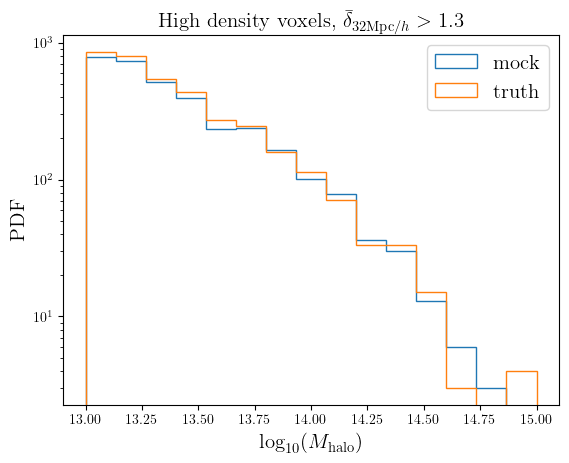

In [59]:
pl.figure()
_ = pl.hist(Mhalo_all_concat_high, bins=15, range=(lgMin, 15),  histtype='step', label='mock')
# _ = pl.hist(lgMsim_truth, bins=15, range=(lgMin, 15), density=True, histtype='step', label='truth')
_ = pl.hist(Mhalo_all_truth_concat_high, bins=15, range=(lgMin, 15), histtype='step', label='truth')
pl.yscale('log')
pl.legend(fontsize=15)
pl.xlabel(r'$\log_{10}(M_{\rm halo})$', size=15)
pl.ylabel(r'PDF', size=15)
pl.title(r'High density voxels, $\bar{\delta}_{{\rm 32Mpc}/h} > 1.3$', size=15)



Text(0.5, 1.0, 'Mid density voxels, $0.75 < \\bar{\\delta}_{{\\rm 32Mpc}/h} < 1.3$')

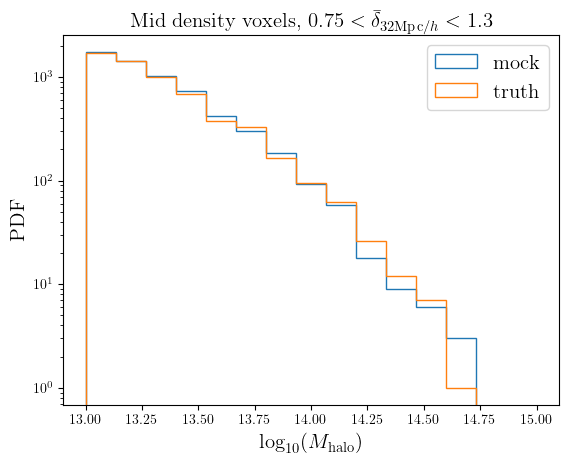

In [60]:
pl.figure()
_ = pl.hist(Mhalo_all_concat_mid, bins=15, range=(lgMin, 15), histtype='step', label='mock')
# _ = pl.hist(lgMsim_truth, bins=15, range=(lgMin, 15), density=True, histtype='step', label='truth')
_ = pl.hist(Mhalo_all_truth_concat_mid, bins=15, range=(lgMin, 15), histtype='step', label='truth')
pl.yscale('log')
pl.legend(fontsize=15)
pl.xlabel(r'$\log_{10}(M_{\rm halo})$', size=15)
pl.ylabel(r'PDF', size=15)
pl.title(r'Mid density voxels, $0.75 < \bar{\delta}_{{\rm 32Mpc}/h} < 1.3$', size=15)



Text(0.5, 1.0, 'Low density voxels, $\\bar{\\delta}_{{\\rm 32Mpc}/h} < 0.75$')

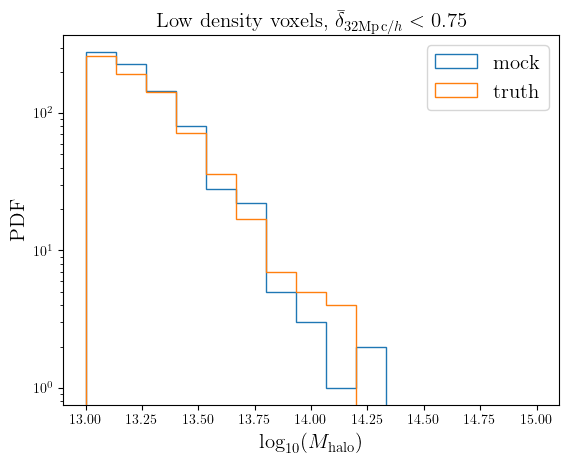

In [61]:
pl.figure()
_ = pl.hist(Mhalo_all_concat_low, bins=15, range=(lgMin, 15), histtype='step', label='mock')
# _ = pl.hist(lgMsim_truth, bins=15, range=(lgMin, 15), density=True, histtype='step', label='truth')
_ = pl.hist(Mhalo_all_truth_concat_low, bins=15, range=(lgMin, 15), histtype='step', label='truth')
pl.yscale('log')
pl.legend(fontsize=15)
pl.xlabel(r'$\log_{10}(M_{\rm halo})$', size=15)
pl.ylabel(r'PDF', size=15)
pl.title(r'Low density voxels, $\bar{\delta}_{{\rm 32Mpc}/h} < 0.75$', size=15)



In [64]:
from tqdm import tqdm
indhigh_to_plot = indhigh[::4]
idx_inp = torch.zeros((1, 1), dtype=torch.long, device=dev)
nvox_samp = len(indhigh_to_plot)
max_new_tokens = 160
end_token = 129
idx_all = []
for jv in tqdm(range(nvox_samp)):
    ind_jv = indhigh_to_plot[jv]
    DM_val_jv = DM_val[ind_jv,...]
    idx = idx_inp
    for _ in range(max_new_tokens):
        # crop idx to the last block_size tokens
        idx_cond = idx[:, -block_size:]
        # get the predictions
        logits, loss = model(idx_cond, DM_val_jv.unsqueeze(0))
        # focus only on the last time step
        logits = logits[:, -1, :] # becomes (B, C)
        # apply softmax to get probabilities
        probs = F.softmax(logits, dim=-1) # (B, C)
        # sample from the distribution
        idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
        # append sampled index to the running sequence
        if idx_next == end_token:
            break
        idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
    idx_all.append(idx)
    



(tensor([  0,  54,  53, 121, 106, 130,  41,  11,  99,  19, 130,  20,  68, 123,
         122, 130,  19,  69, 104, 119, 130,  17, 119, 121, 117, 130,   8,  77,
         100, 110, 130,   7,  70, 125,  37, 130,   6,  54, 113,  95, 130,   5,
          83, 126,   4, 130,   2,  71, 102, 119, 129,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1], device='cuda:0'),
 tensor([[  0,  60,  59, 119, 104, 130,  44,  59, 118, 109, 130,  35,  35